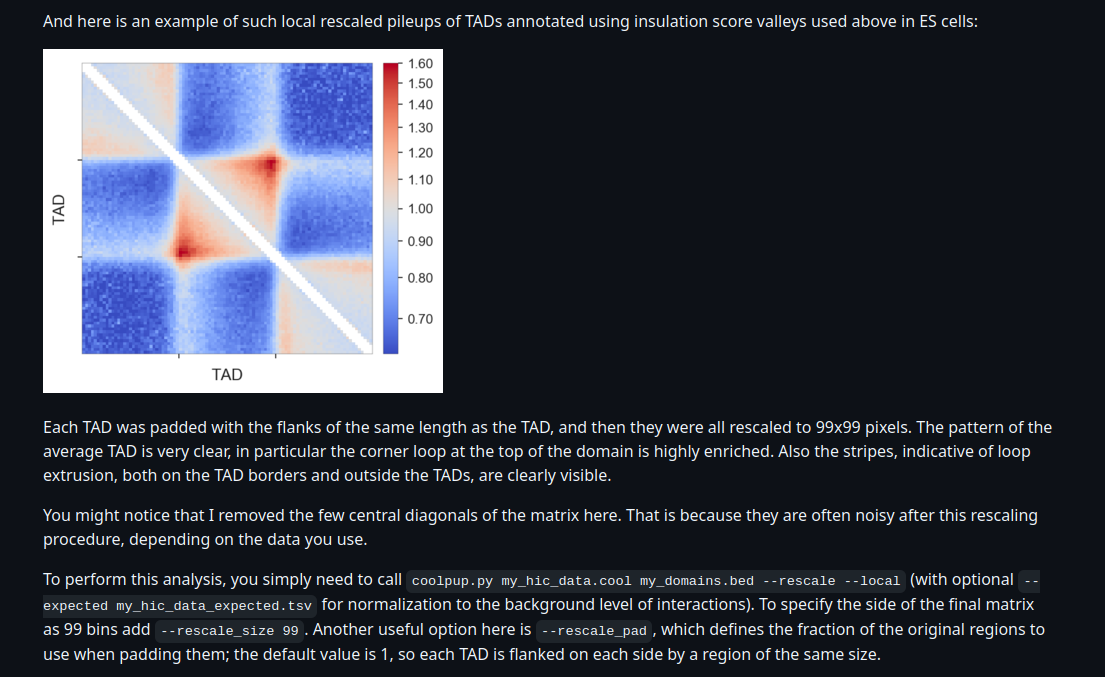

In [130]:
import pandas as pd
import cooler
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from functools import partial

def adjust_locus(locus_position, chromsize, is_circ_chrom = False):
        """Adjust the coordinates of a locus to fit between 0 and the chromosome size. Accounts for circularity."""
        if locus_position < 0:
            locus_position = chromsize + locus_position if is_circ_chrom else 0

        if locus_position >= chromsize:
            locus_position = locus_position - chromsize if is_circ_chrom else chromsize
        return locus_position

dickeya_regions = """Chromosome	Start	End	Id
NC_014500.1	4822882	100000	Ori
NC_014500.1	100001	2329999	Arm1
NC_014500.1	2330000	2580000	Ter
NC_014500.1	2580001	4822881	Arm2"""

dickeya_regions = """Chromosome	Start	End	Id
NC_014500.1	3215000	3235000	Region1
NC_014500.1	3365000	3385000	Region2
NC_014500.1	4025000	4045000	Region3
NC_014500.1	4285000	4305000	Region4
NC_014500.1	2620000	2640000	Region5"""

dickeya_regions_df = pd.DataFrame([line.split("\t") for line in dickeya_regions.split("\n")])
dickeya_regions_df.rename(columns=dickeya_regions_df.iloc[0], inplace = True)
dickeya_regions_df.drop(dickeya_regions_df.index[0], inplace = True)
dickeya_regions_df["Start"] = dickeya_regions_df["Start"].astype('int64')
dickeya_regions_df["End"] = dickeya_regions_df["End"].astype('int64')

# Hi-C dataset
banks = ["Control", "PGA", "Acid", "Endive1_2025", "Endive2_2025", "Endive3_2025", "Endive4_2025", "Endive5_2025"]
binning = 1000
chromsize = 4922802
hics = [
    #f"C:/Users/maely/Desktop/D. dadantii Hi-C/cool_files/{bank}.mcool::resolutions/{binning}" for bank in banks
    f"/data/Maelys/datas/cool_files/{bank}/{bank}.mcool::resolutions/{binning}" for bank in banks
]
dickeya_regions_df

,Chromosome,Start,End,Id
1,NC_014500.1,3215000,3235000,Region1
2,NC_014500.1,3365000,3385000,Region2
3,NC_014500.1,4025000,4045000,Region3
4,NC_014500.1,4285000,4305000,Region4
5,NC_014500.1,2620000,2640000,Region5


In [131]:
import math
def apply_padding(region, chromsize, padding_size = 0.5):
    """Adds padding to region in new columns, "Padded_start" and "Padded_end"."""
    # applying padding
    region_size = region["End"] - region["Start"] if region["Start"] <= region["End"] else (chromsize - region["Start"]) + region["End"]
    padding = math.floor(region_size * padding_size)
    
    region["Padded_start"] = (region["Start"] - padding) % chromsize    
    region["Padded_end"] = (region["End"] + padding) % chromsize
    region["Padded_size"] = region_size + 2 * padding
    region["Padding"] = padding
    region["Size"] = region_size
    
    return region

dickeya_padded_regions = []
for i in range(len(dickeya_regions_df)):
    dickeya_padded_regions.append(apply_padding(dickeya_regions_df.iloc[i], chromsize))
    
dickeya_padded_regions = pd.DataFrame(dickeya_padded_regions)
dickeya_padded_regions

,Chromosome,Start,End,Id,Padded_start,Padded_end,Padded_size,Padding,Size
1,NC_014500.1,3215000,3235000,Region1,3205000,3245000,40000,10000,20000
2,NC_014500.1,3365000,3385000,Region2,3355000,3395000,40000,10000,20000
3,NC_014500.1,4025000,4045000,Region3,4015000,4055000,40000,10000,20000
4,NC_014500.1,4285000,4305000,Region4,4275000,4315000,40000,10000,20000
5,NC_014500.1,2620000,2640000,Region5,2610000,2650000,40000,10000,20000


In [134]:
# extracting individual windows from the list of regions
def extract_window_region(cool, region1, region2, is_loc_circ1 = False, is_loc_circ2 = False, raw = False):
    """Extracts a submatrix of regions interaction zone from cool matrix.
    If required, adds paddings. Takes into account chromosome circularity."""
    matrix = cool.matrix(balance=(not raw))
    binning = cool.binsize

    if region1["Chromosome"] not in cool.chromsizes or region2["Chromosome"] not in cool.chromsizes:
        return None
    chrom_size1 = cool.chromsizes[region1["Chromosome"]]
    chrom_size2 = cool.chromsizes[region2["Chromosome"]]
    
    start1 = adjust_locus(region1["Padded_start"], chrom_size1, is_circ_chrom = is_loc_circ1)
    end1 = adjust_locus(region1["Padded_end"], chrom_size1, is_circ_chrom = is_loc_circ1)
    start2 = adjust_locus(region2["Padded_start"], chrom_size2, is_circ_chrom = is_loc_circ2)
    end2 = adjust_locus(region2["Padded_end"], chrom_size2, is_circ_chrom = is_loc_circ2)
    
    # 1. checking overflows
    region1_overflow = start1 >= end1
    region2_overflow = start2 >= end2

    # 2. computing intervales: assures the original submatrix includes the region center
    lower_overflow1 = chrom_size1 - start1 < end1
    lower_overflow2 = chrom_size2 - start2 < end2
    
    lower_interval1 = f"{region1['Chromosome']}:{start1 if not region1_overflow else 0}-{end1}" 
    higher_interval1 = f"{region1['Chromosome']}:{start1}-{end1 if not region1_overflow else chrom_size1}" 
    pos1 = lower_interval1 if lower_overflow1 else higher_interval1
    
    lower_interval2 = f"{region2['Chromosome']}:{start2 if not region2_overflow else 0}-{end2}" 
    higher_interval2 = f"{region2['Chromosome']}:{start2}-{end2 if not region2_overflow else chrom_size2}" 
    pos2 = lower_interval2 if lower_overflow2 else higher_interval2

    # 3. fetching main submatrix
    submatrix = matrix.fetch(pos1, pos2)[:]
    
    if (not region1_overflow and not region2_overflow): # no overflow
        return submatrix
    
    # 4. managing overflows:
    bins1_to_fill = (chrom_size1 // binning - start1 // binning) + 1 if lower_overflow1 else end1 // binning + 1
    bins2_to_fill = (chrom_size2 // binning - start2 // binning) + 1 if lower_overflow2 else end2 // binning + 1

    if bins1_to_fill == 0 and bins2_to_fill == 0:
        return submatrix
        
    if bins1_to_fill > 0:
        fill1 = np.array([chrom_size1 - (bins1_to_fill * binning), chrom_size1]) if lower_overflow1 else np.array([0, end1])
        fill1_pos = f"{region1['Chromosome']}:{fill1[0]}-{fill1[1]}"
    
    if bins2_to_fill > 0:
        fill2 = np.array([chrom_size2 - (bins2_to_fill * binning), chrom_size2]) if lower_overflow2 else np.array([0, end2])
        fill2_pos = f"{region2['Chromosome']}:{fill2[0]}-{fill2[1]}"
        
    mat1, mat2 = None, None
    if bins2_to_fill > 0:
        mat1 = matrix.fetch(pos1, fill2_pos) if is_loc_circ2 else np.full((submatrix.shape[0], bins2_to_fill), np.nan)
            
    if bins1_to_fill > 0:
        mat2 = matrix.fetch(fill1_pos, pos2) if is_loc_circ1 else np.full((bins1_to_fill, submatrix.shape[1]), np.nan)
        
    # two dimensions to fill
    if region1_overflow and region2_overflow:

        mat3 = matrix.fetch(fill1_pos, fill2_pos) if is_loc_circ1 and is_loc_circ2 else np.full((bins1_to_fill, bins2_to_fill), np.nan)

        concat1 = np.concatenate([mat1, submatrix], axis = 1) if lower_overflow2 else np.concatenate([submatrix, mat1], axis = 1)
        concat2 = np.concatenate([mat3, mat2], axis = 1) if lower_overflow2 else np.concatenate([mat2, mat3], axis = 1)
        submatrix = np.concatenate([concat2, concat1], axis = 0) if lower_overflow1 else np.concatenate([concat1, concat2], axis = 0)
        
    # dim1 to fill
    elif region1_overflow:        
        submatrix = np.concatenate([mat2, submatrix], axis = 0) if lower_overflow1 else np.concatenate([submatrix, mat2], axis = 0)
        
    # dim2 to fill
    elif region2_overflow:
        submatrix = np.concatenate([mat1, submatrix], axis = 1) if lower_overflow2 else np.concatenate([submatrix, mat1], axis = 1)
 
    return submatrix

def zoom_array(
    in_array,
    final_shape,
    same_sum=False,
    zoom_function=partial(zoom, order=1),
    **zoom_kwargs
):
    """Rescale an array or image.

    Normally, one can use scipy.ndimage.zoom to do array/image rescaling.
    However, scipy.ndimage.zoom does not coarsegrain images well. It basically
    takes nearest neighbor, rather than averaging all the pixels, when
    coarsegraining arrays. This increases noise. Photoshop doesn't do that, and
    performs some smart interpolation-averaging instead.

    If you were to coarsegrain an array by an integer factor, e.g. 100x100 ->
    25x25, you just need to do block-averaging, that's easy, and it reduces
    noise. But what if you want to coarsegrain 100x100 -> 30x30?

    Then my friend you are in trouble. But this function will help you. This
    function will blow up your 100x100 array to a 120x120 array using
    scipy.ndimage zoom Then it will coarsegrain a 120x120 array by
    block-averaging in 4x4 chunks.

    It will do it independently for each dimension, so if you want a 100x100
    array to become a 60x120 array, it will blow up the first and the second
    dimension to 120, and then block-average only the first dimension.

    (Copied from mirnylib.numutils)

    Parameters
    ----------
    in_array : ndarray
        n-dimensional numpy array (1D also works)
    final_shape : shape tuple
        resulting shape of an array
    same_sum : bool, optional
        Preserve a sum of the array, rather than values. By default, values
        are preserved
    zoom_function : callable
        By default, scipy.ndimage.zoom with order=1. You can plug your own.
    **zoom_kwargs :
        Options to pass to zoomFunction.

    Returns
    -------
    rescaled : ndarray
        Rescaled version of in_array

    """
    in_array = np.asarray(in_array, dtype=np.double)
    in_shape = in_array.shape
    assert len(in_shape) == len(final_shape)
    mults = []  # multipliers for the final coarsegraining
    for i in range(len(in_shape)):
        if final_shape[i] < in_shape[i]:
            mults.append(int(np.ceil(in_shape[i] / final_shape[i])))
        else:
            mults.append(1)
    # shape to which to blow up
    temp_shape = tuple([i * j for i, j in zip(final_shape, mults)])

    # stupid zoom doesn't accept the final shape. Carefully crafting the
    # multipliers to make sure that it will work.
    zoom_multipliers = np.array(temp_shape) / np.array(in_shape) + 0.0000001
    assert zoom_multipliers.min() >= 1

    # applying scipy.ndimage.zoom
    rescaled = zoom_function(in_array, zoom_multipliers, **zoom_kwargs)

    for ind, mult in enumerate(mults):
        if mult != 1:
            sh = list(rescaled.shape)
            assert sh[ind] % mult == 0
            newshape = sh[:ind] + [sh[ind] // mult, mult] + sh[ind + 1 :]
            rescaled.shape = newshape
            rescaled = np.mean(rescaled, axis=ind + 1)
    assert rescaled.shape == final_shape

    if same_sum:
        extra_size = np.prod(final_shape) / np.prod(in_shape)
        rescaled /= extra_size
    return rescaled

def resize_window(submatrix, expected_size = 100):
    """Resizes a submatrix to match the shape expected_size x expected_size."""
    return zoom_array(submatrix, (expected_size, expected_size))

In [37]:
# usefull region functions
def compute_bin_coordinates(region, chromsize, binning, add_padding = True):
    """Computes all the coordinates of the bins in the submatrix."""    
    start = region["Padded_start"] if add_padding else region["Start"]
    end = region["Padded_end"] if add_padding else region["End"]
    
    if start <= end:
        return np.array(range(start//binning, end//binning))
    return np.concatenate([
        np.array(range(start//binning, (chromsize - 1)//binning)),
        np.array(range(end//binning))
    ])
    
def get_common_bins(bins1, bins2):
    """Yields the coordinates list of each bins list corresponding to a consecutive list of bins present in both."""
    nb_bins1 = len(bins1)
    nb_bins2 = len(bins2)
    
    if nb_bins1 == 0 or nb_bins2 == 0:
        pass
    
    # reorganising the list for circular coordinates
    zero1, zero2 = 0, 0
    if 0 in bins1:
        while bins1[zero1] != 0:
            zero1 += 1
        bins1 = np.concatenate([bins1[zero1:], bins1[:zero1]])
    if 0 in bins2:
        while bins2[zero2] != 0:
            zero2 += 1
        bins2 = np.concatenate([bins2[zero2:], bins2[:zero2]])
    
    current_list = [[], []]
    i, j = 0, 0
    while i < nb_bins1 and j < nb_bins2:
        if bins1[i] < bins2[j]:
            i += 1
        elif bins2[j] < bins1[i]:
            j += 1
        elif bins2[j] == bins1[i]:
            i_shifted = (i + zero1) % nb_bins1
            j_shifted = (j + zero2) % nb_bins2
            # checking that the indexes to add are consecutive to the previous. Otherwise, the current_list is yielded and re-initialized with the new indexes.
            if len(current_list[0]) == 0 or (current_list[0][-1] == i_shifted - 1 and current_list[1][-1] == j_shifted - 1):
                current_list[0].append(i_shifted)
                current_list[1].append(j_shifted)
            else:
                yield current_list
                current_list = [[i_shifted], [j_shifted]]
            i += 1
            j += 1
    if len(current_list[0]) > 0:
        yield current_list

def mask_diagonal_region(submatrix, region1, region2, binning, diagonal_mask, chromsize = 0, add_padding = True):
    """Computes the mask to apply to the diagonal from positions 1 and 2"""
    if region1["Chromosome"] != region2["Chromosome"]:
        return submatrix
    
    for subcoords in get_common_bins(
        compute_bin_coordinates(region1, chromsize, binning, add_padding = add_padding),
        compute_bin_coordinates(region2, chromsize, binning, add_padding = add_padding)
    ):
        start_dim0, end_dim0 = subcoords[0][0], subcoords[0][-1] + 1
        start_dim1, end_dim1 = subcoords[1][0], subcoords[1][-1] + 1
        
        for i in range(diagonal_mask//binning):
            # upper diagonal
            start = start_dim0 - i
            shift_dim1 = abs(start) if start <= 0 else 0
            start = 0 if start <= 0 else start
            end = end_dim1 + i if end_dim1 + i <= submatrix.shape[1] else submatrix.shape[1]
            np.fill_diagonal(submatrix[start: end_dim0, start_dim1 + shift_dim1: end], np.nan)
            
            # lower diagonal
            start = start_dim1 - i
            shift_dim0 = abs(start) if start < 0 else 0
            start = 0 if start <= 0 else start
            end = end_dim0 + i if end_dim0 + i <= submatrix.shape[0] else submatrix.shape[0]
            np.fill_diagonal(submatrix[start_dim0 + shift_dim0: end, start: end_dim1], np.nan)
    
    return submatrix

/data/Maelys/datas/cool_files/Control/Control.mcool::resolutions/1000
Region1 Region1
(40, 40)
Masked:
Resized:
Region1 Region2
(40, 40)
Masked:
Resized:
Region1 Region3
(40, 40)
Masked:
Resized:
Region1 Region4
(40, 40)
Masked:
Resized:
Region1 Region5


/tmp/ipykernel_4150704/3237019885.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_4150704/3237019885.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_4150704/3237019885.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


(40, 40)
Masked:
Resized:
Region2 Region1
(40, 40)
Masked:
Resized:
Region2 Region2
(40, 40)
Masked:
Resized:
Region2 Region3
(40, 40)
Masked:
Resized:
Region2 Region4
(40, 40)
Masked:
Resized:
Region2 Region5
(40, 40)
Masked:
Resized:
Region3 Region1
(40, 40)
Masked:
Resized:
Region3 Region2
(40, 40)
Masked:
Resized:
Region3 Region3
(40, 40)
Masked:
Resized:
Region3 Region4
(40, 40)
Masked:


/tmp/ipykernel_4150704/3237019885.py:18: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(20, 20))


Resized:
Region3 Region5
(40, 40)
Masked:
Resized:
Region4 Region1
(40, 40)
Masked:
Resized:
Region4 Region2
(40, 40)
Masked:
Resized:
Region4 Region3
(40, 40)
Masked:
Resized:
Region4 Region4
(40, 40)
Masked:
Resized:
Region4 Region5
(40, 40)
Masked:
Resized:
Region5 Region1
(40, 40)
Masked:
Resized:
Region5 Region2
(40, 40)
Masked:
Resized:
Region5 Region3
(40, 40)
Masked:
Resized:
Region5 Region4
(40, 40)
Masked:
Resized:
Region5 Region5
(40, 40)
Masked:
Resized:
Diagonal pileup:
Contact pileup:


/tmp/ipykernel_4150704/3237019885.py:40: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pileup_diag, axis=0))
/tmp/ipykernel_4150704/3237019885.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_4150704/3237019885.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


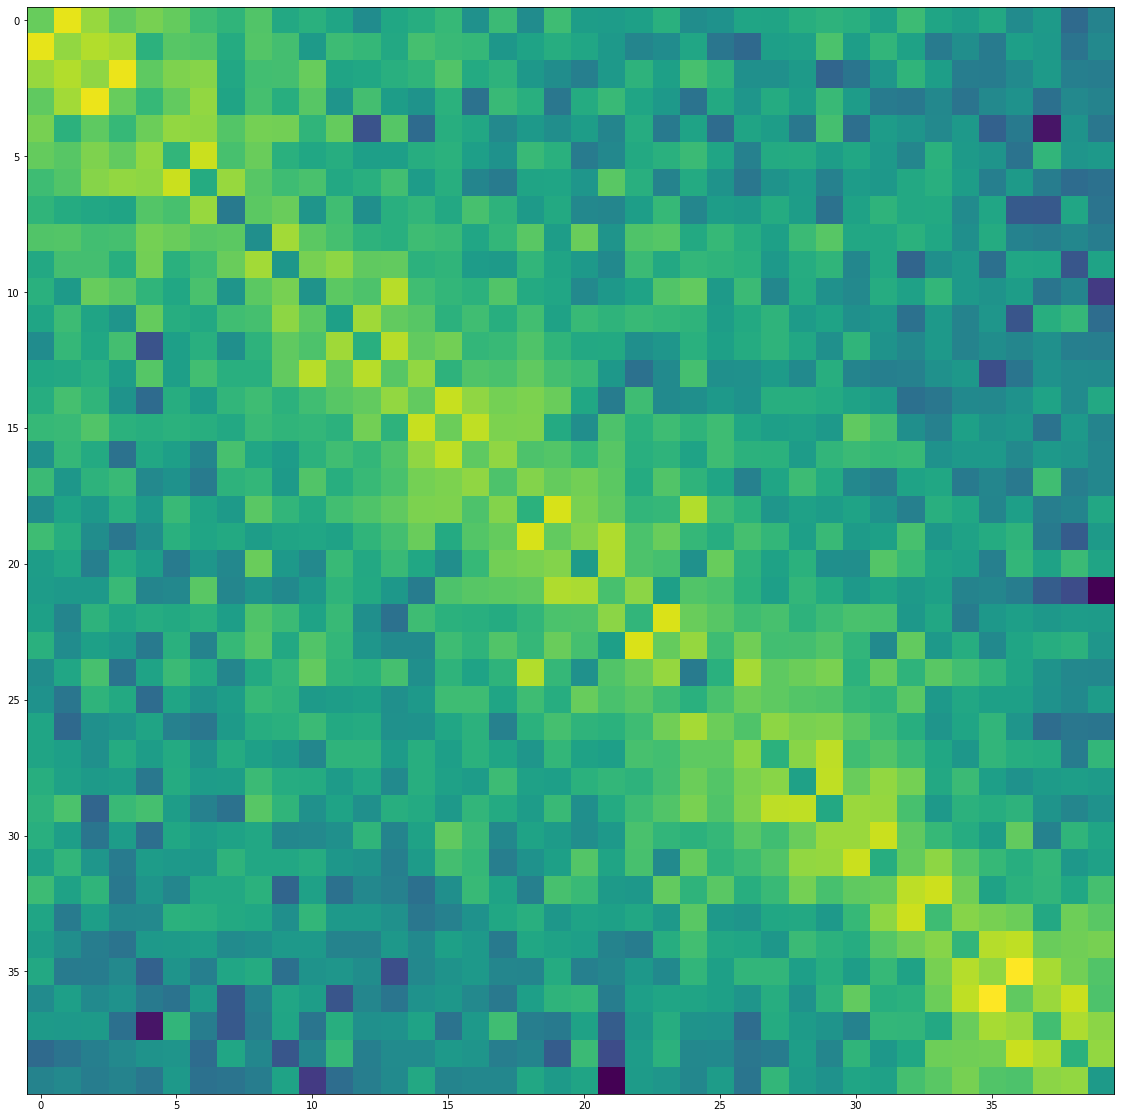

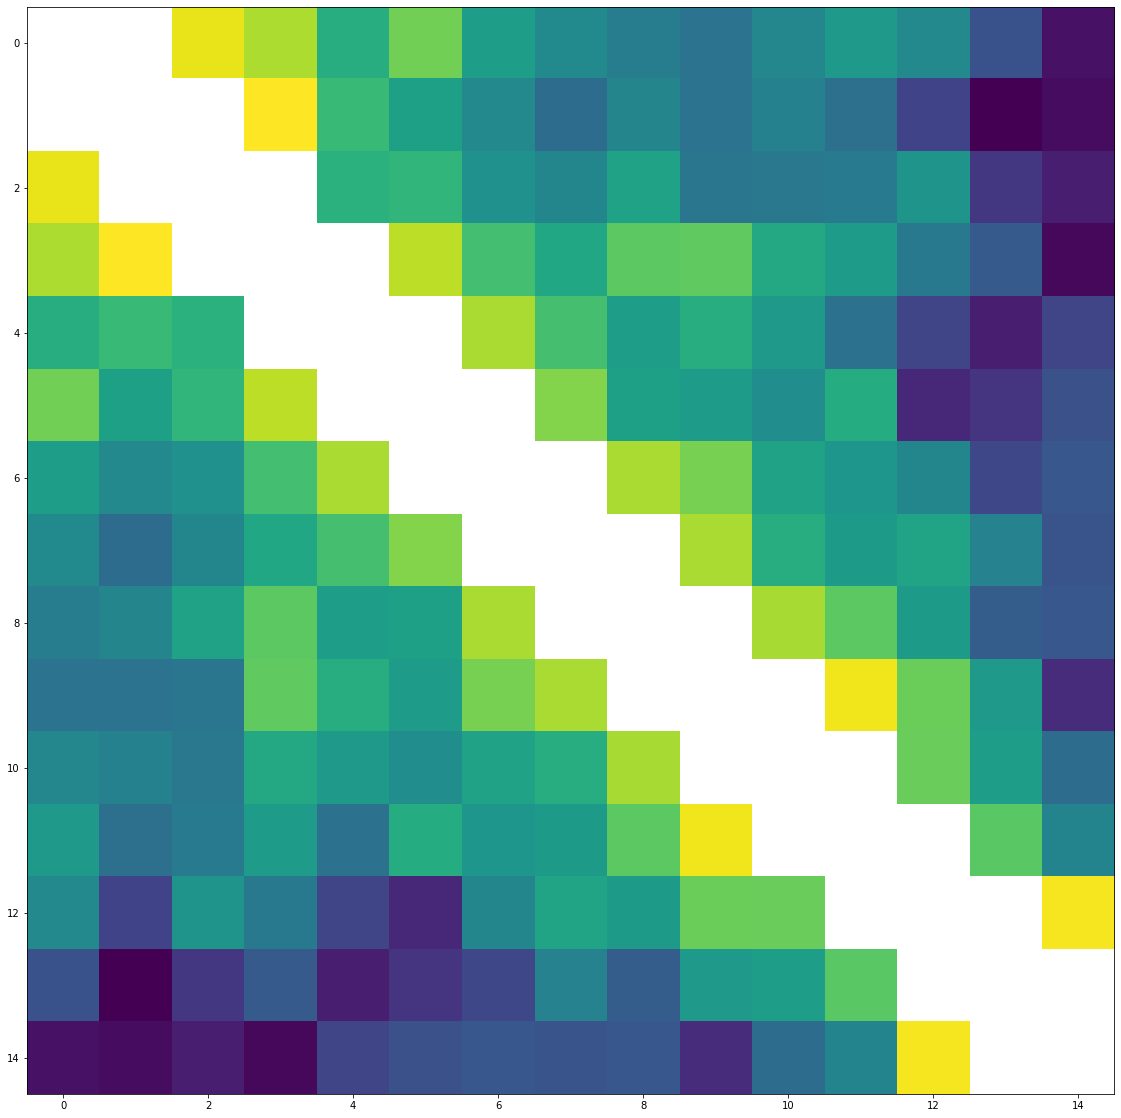

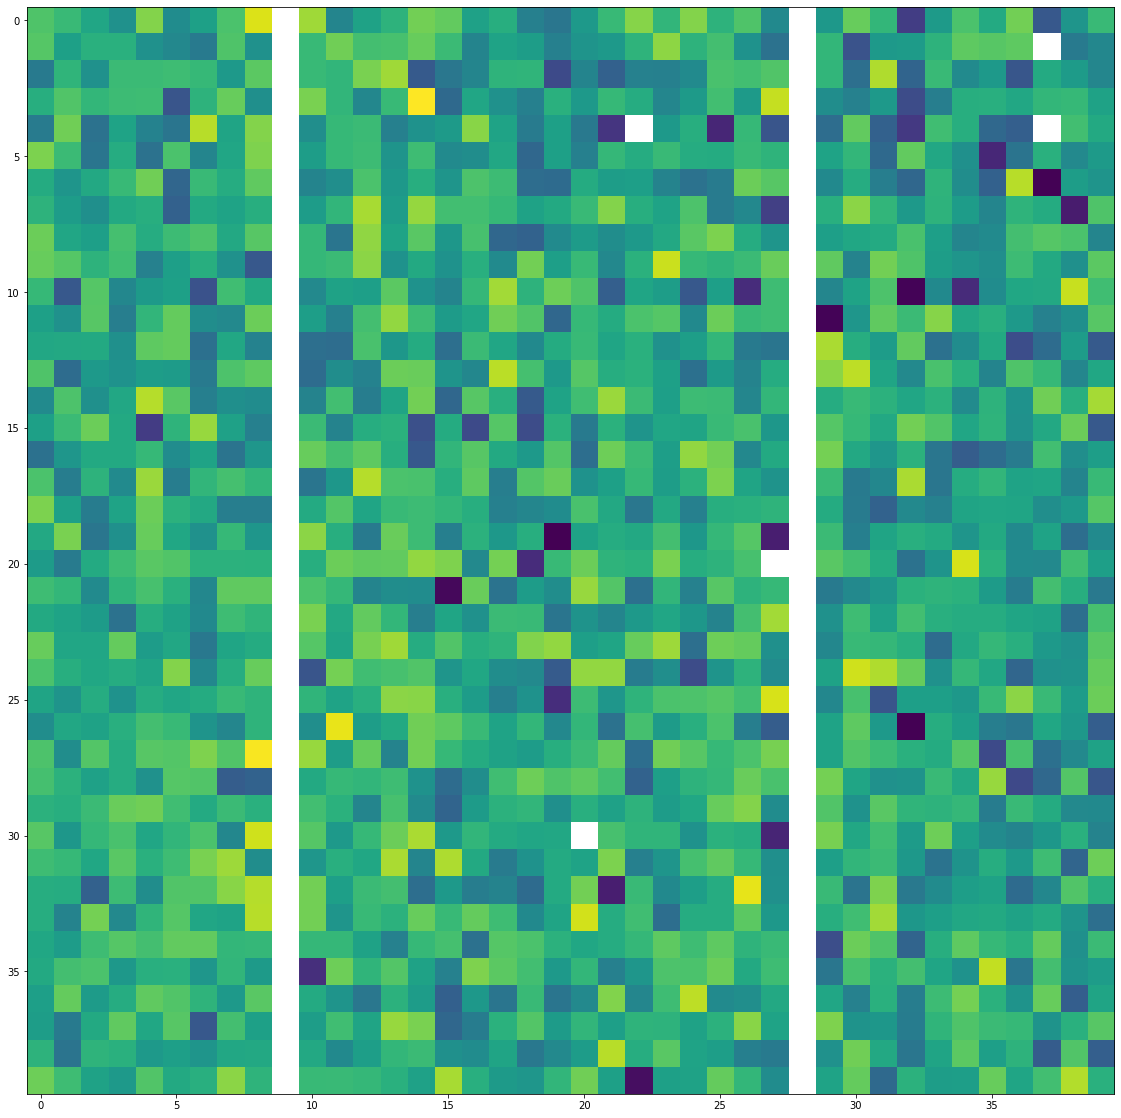

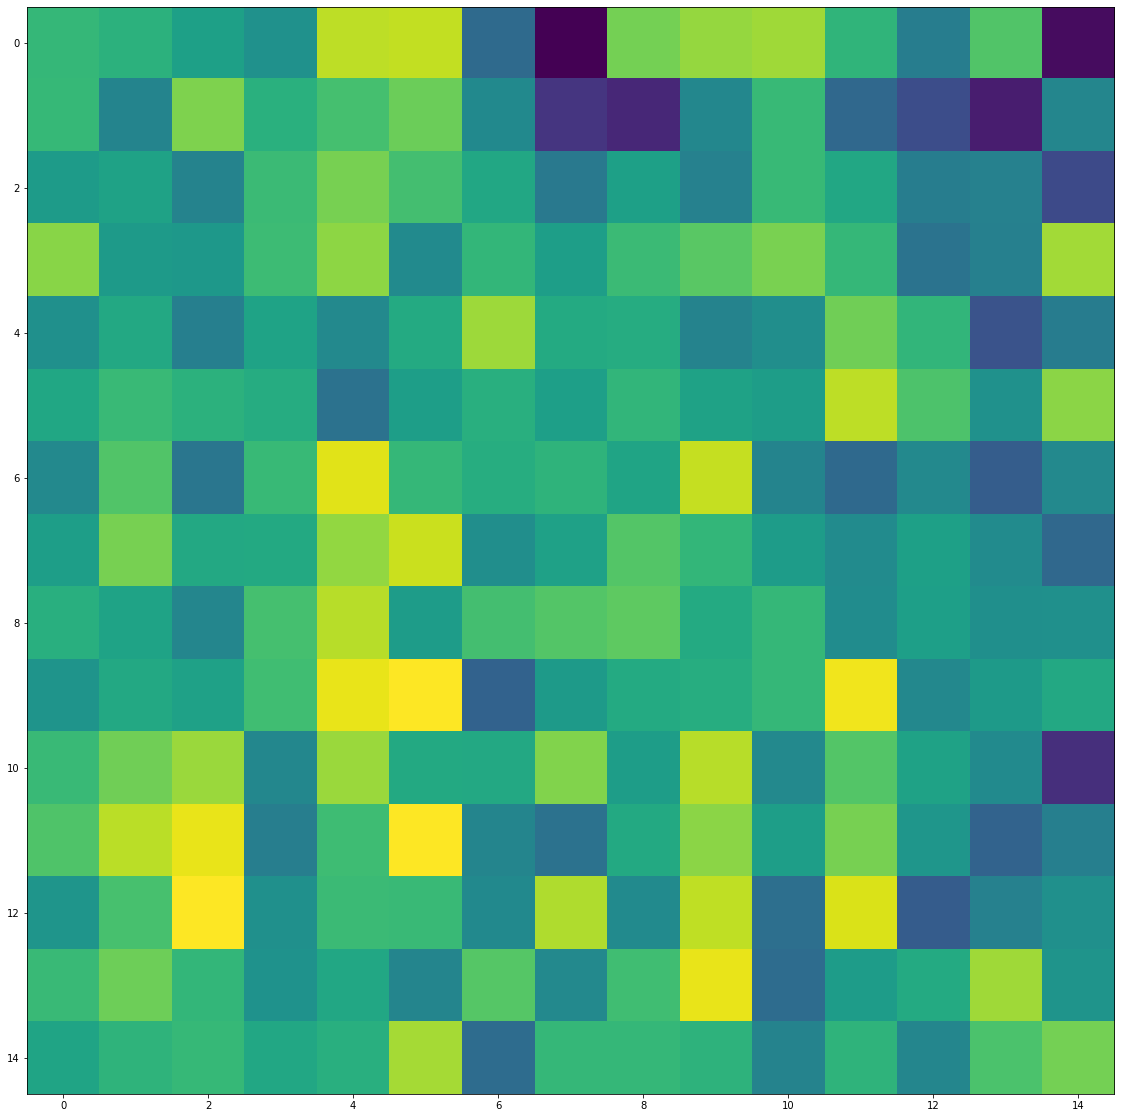

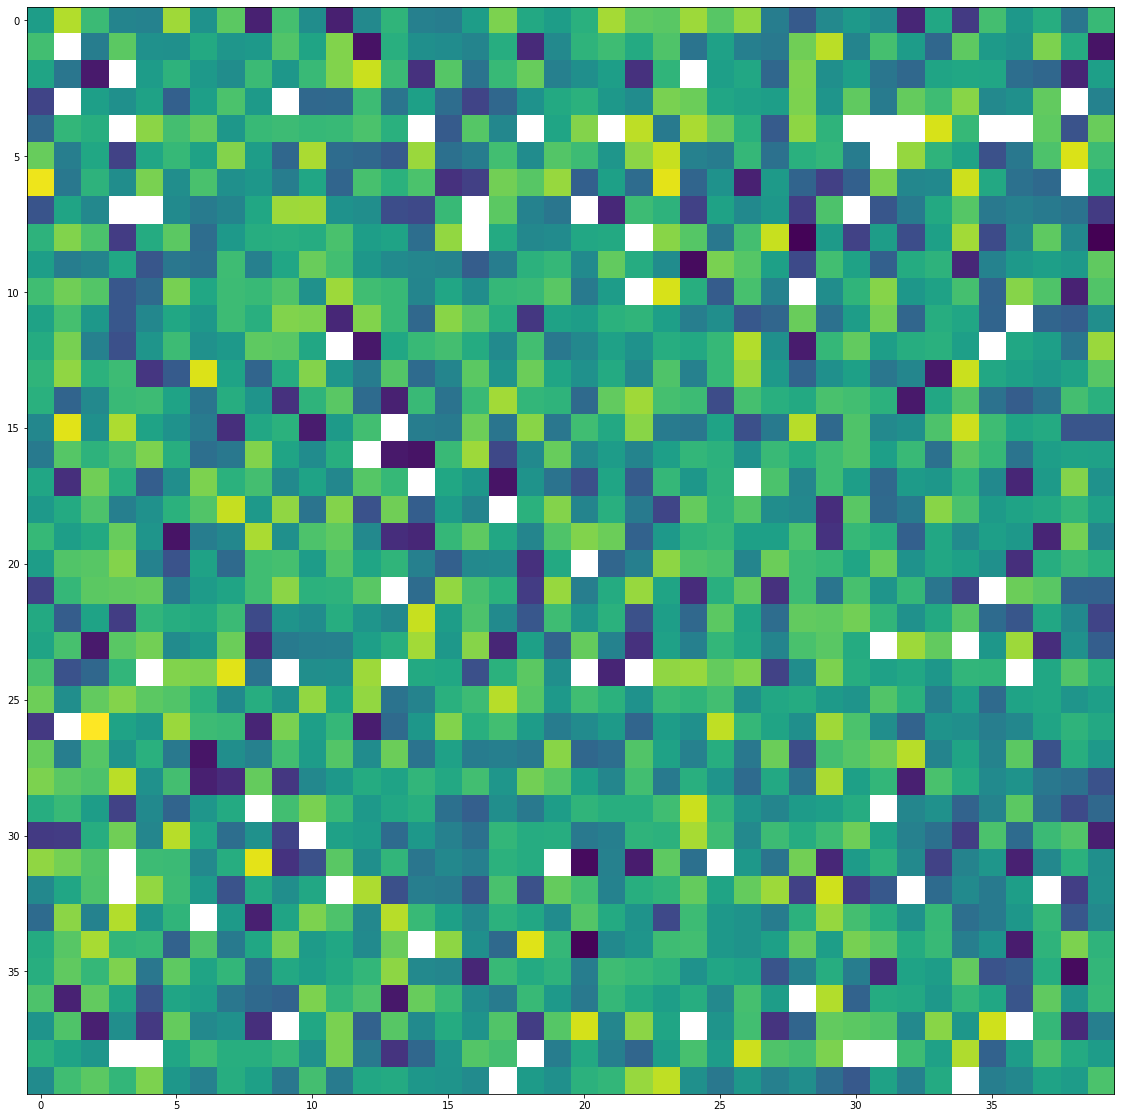

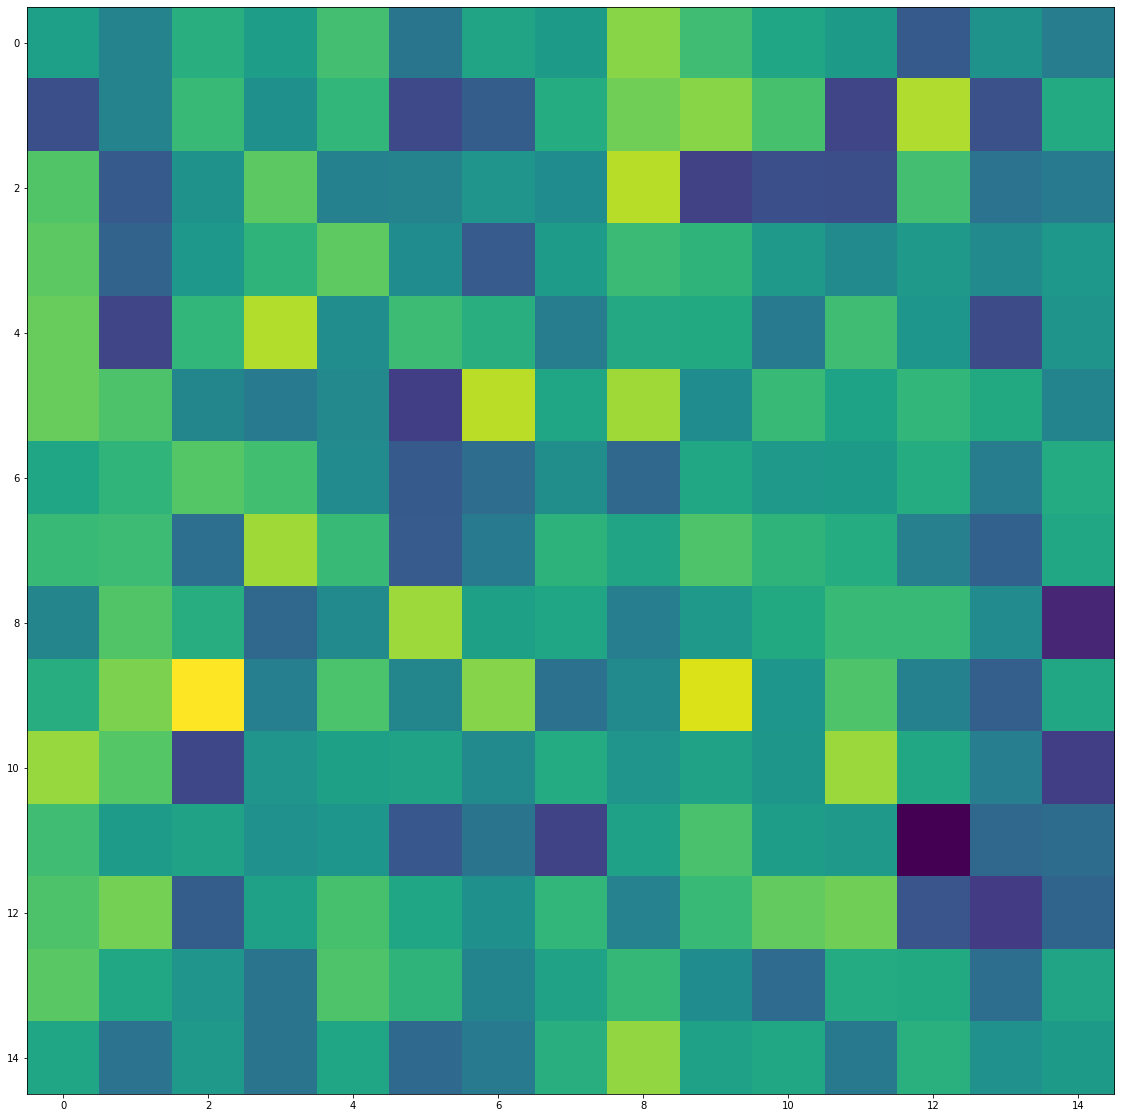

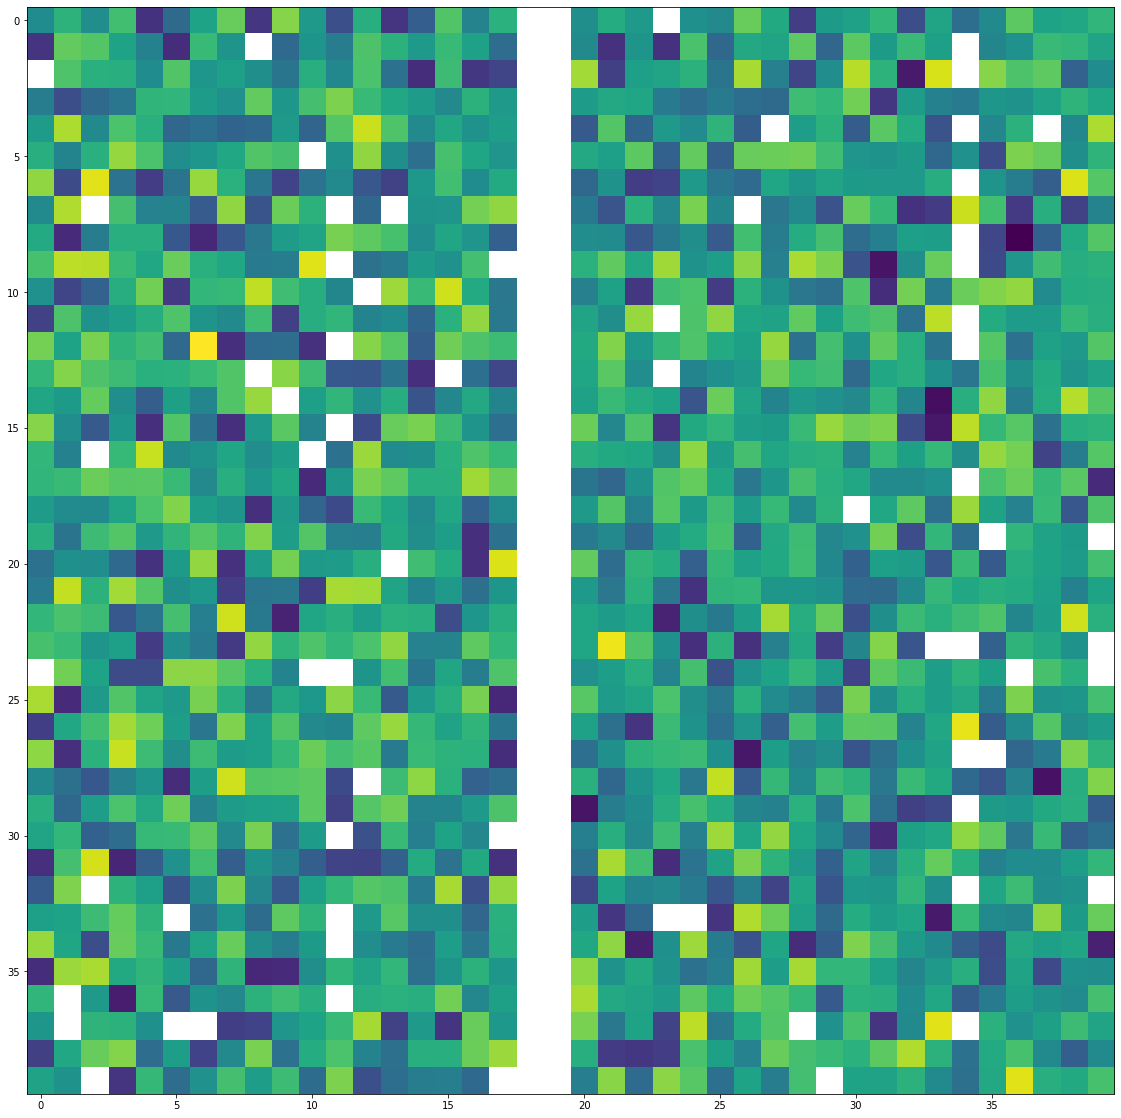

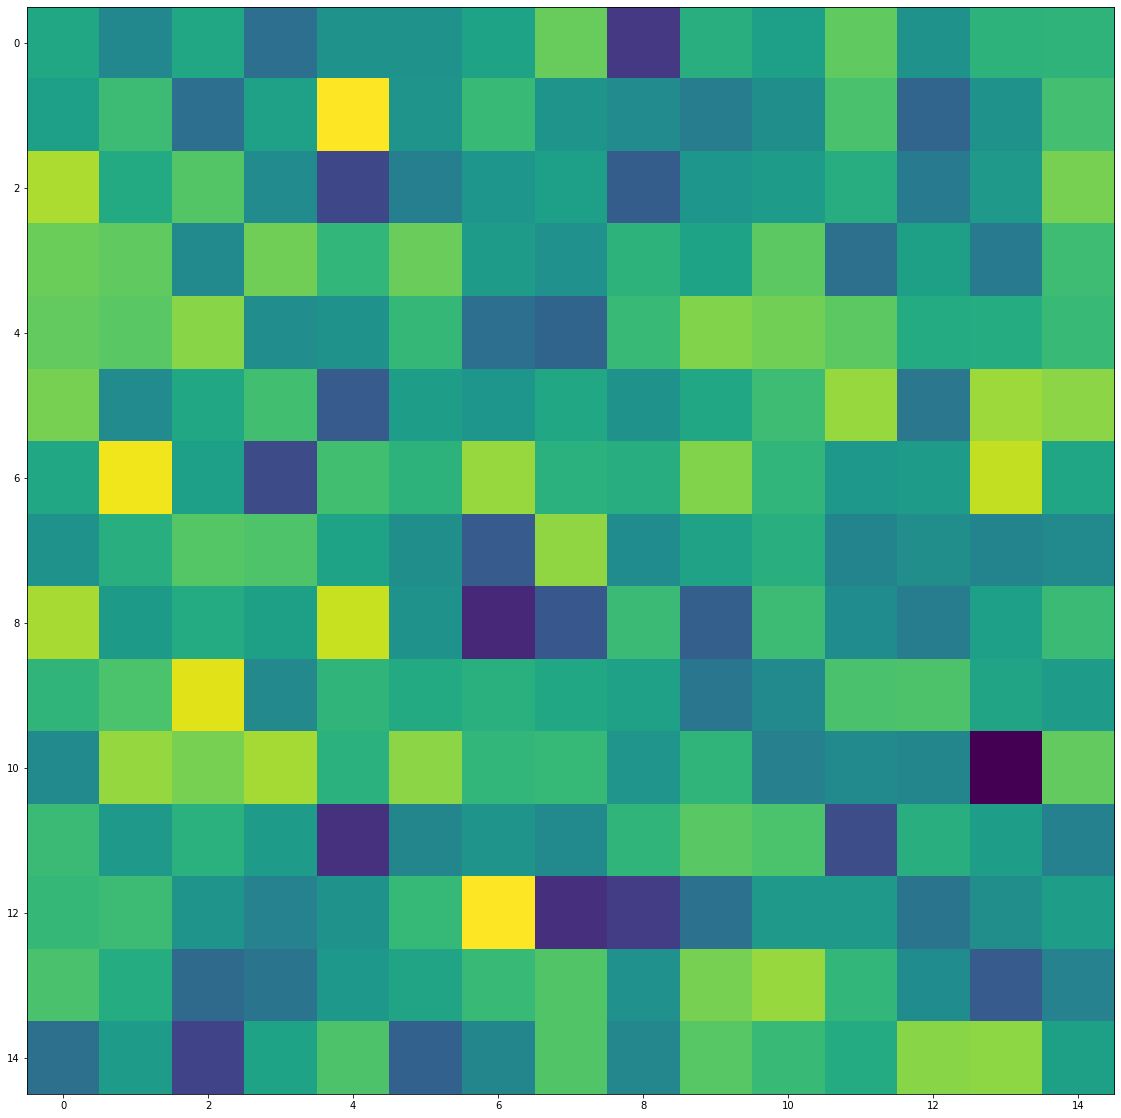

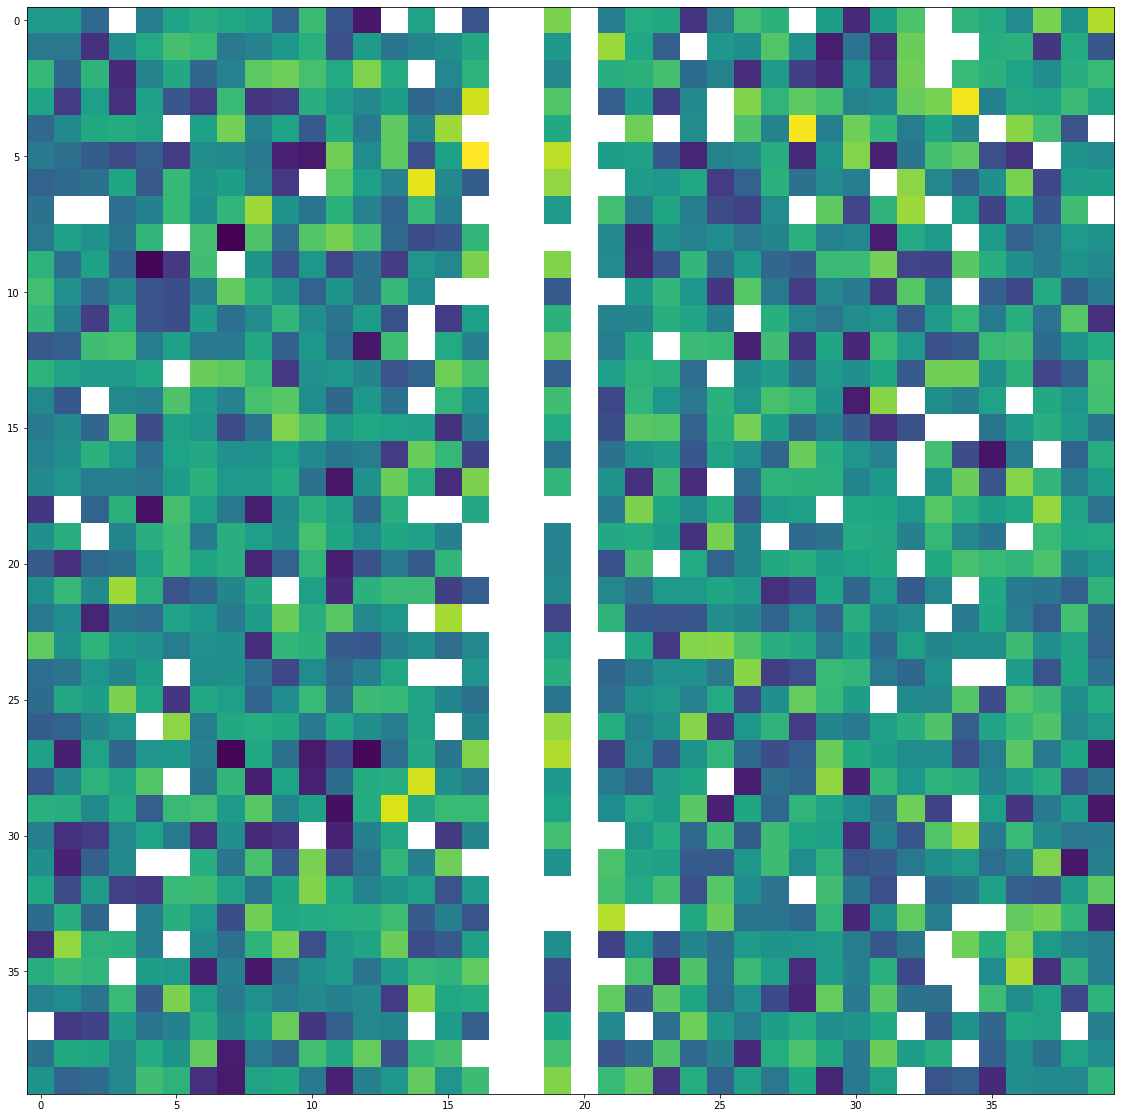

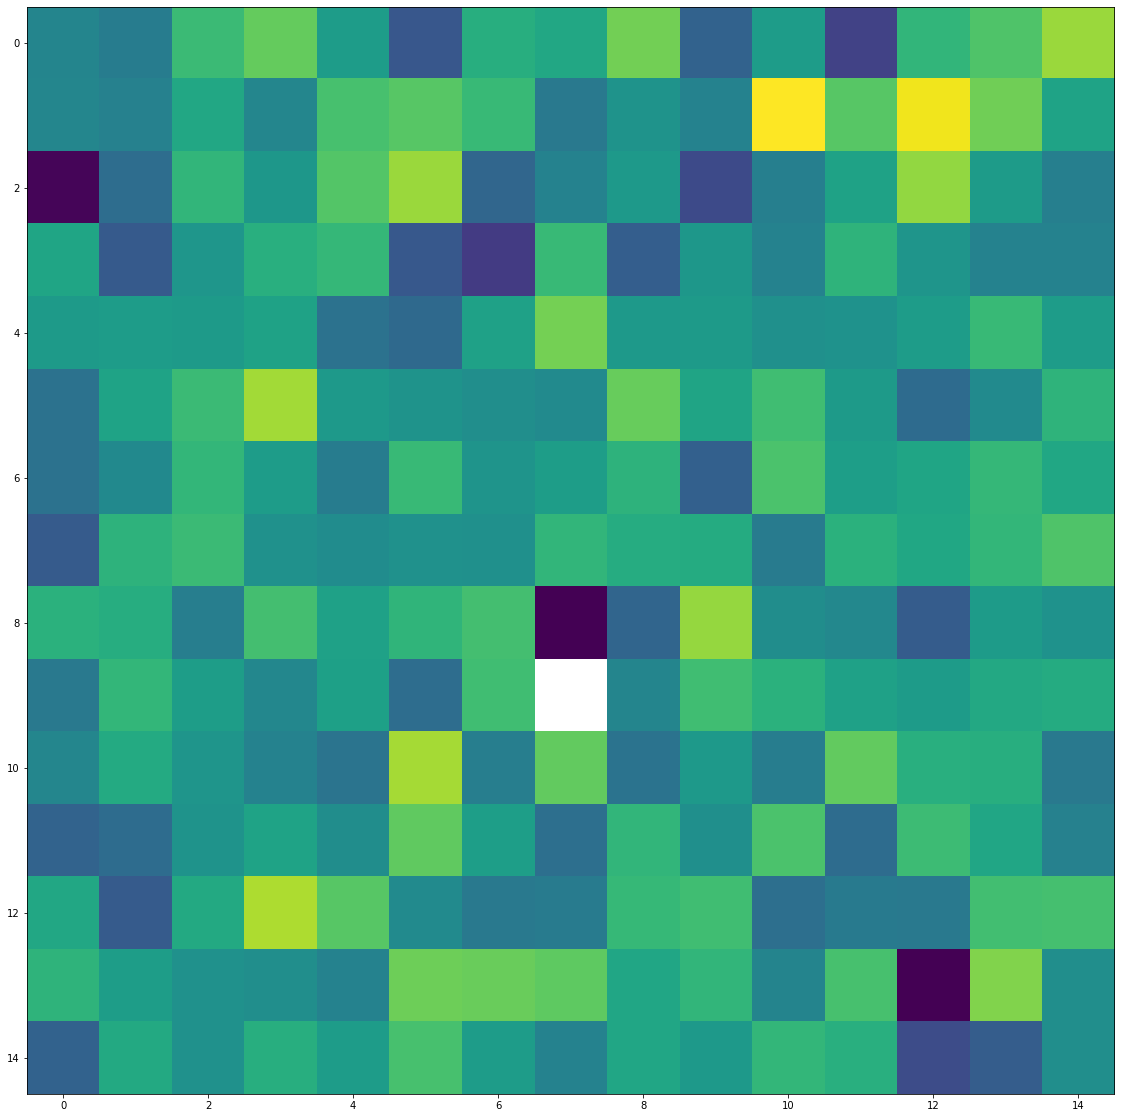

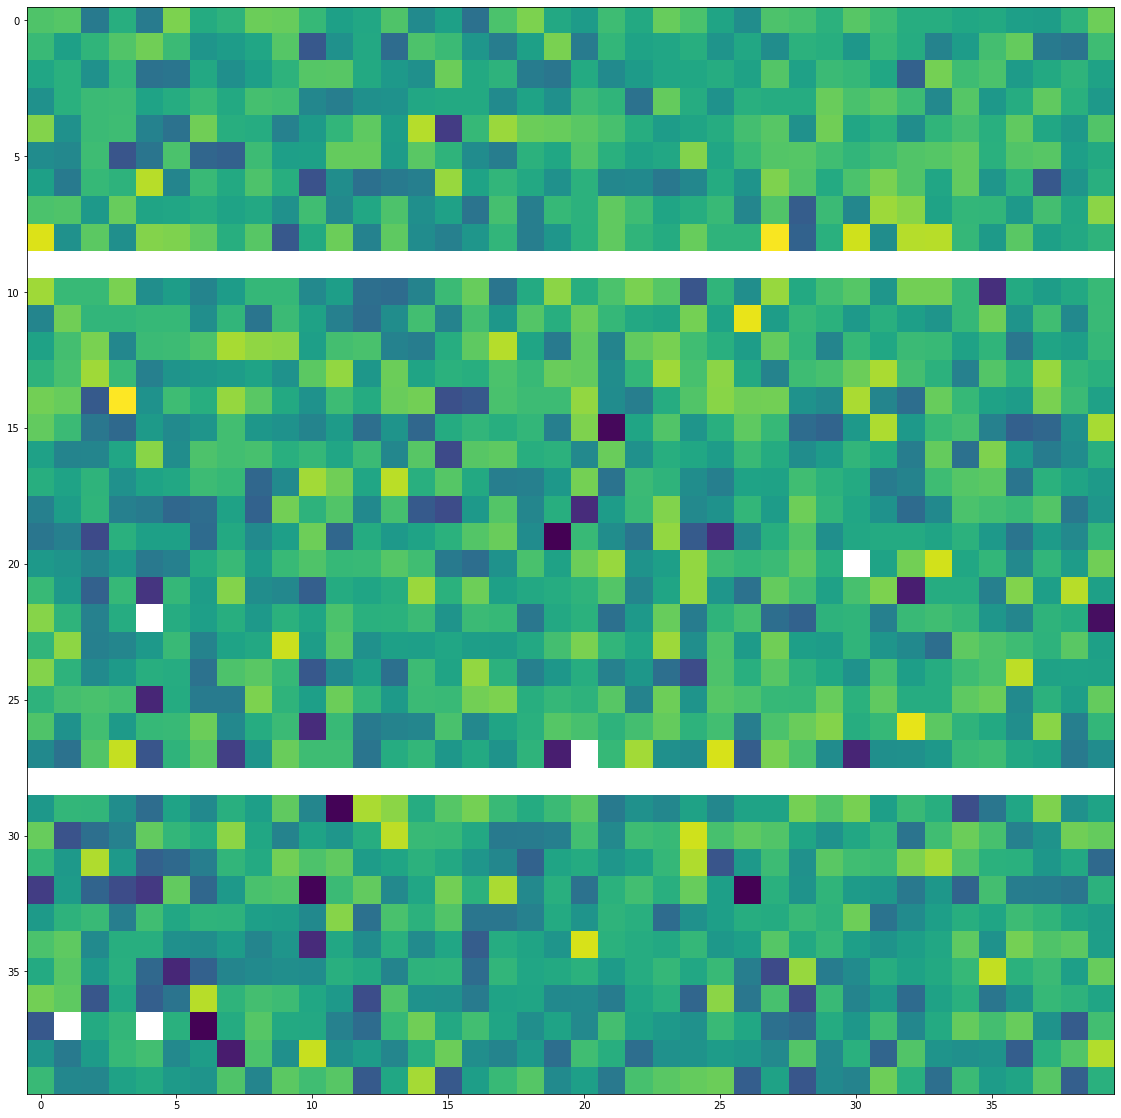

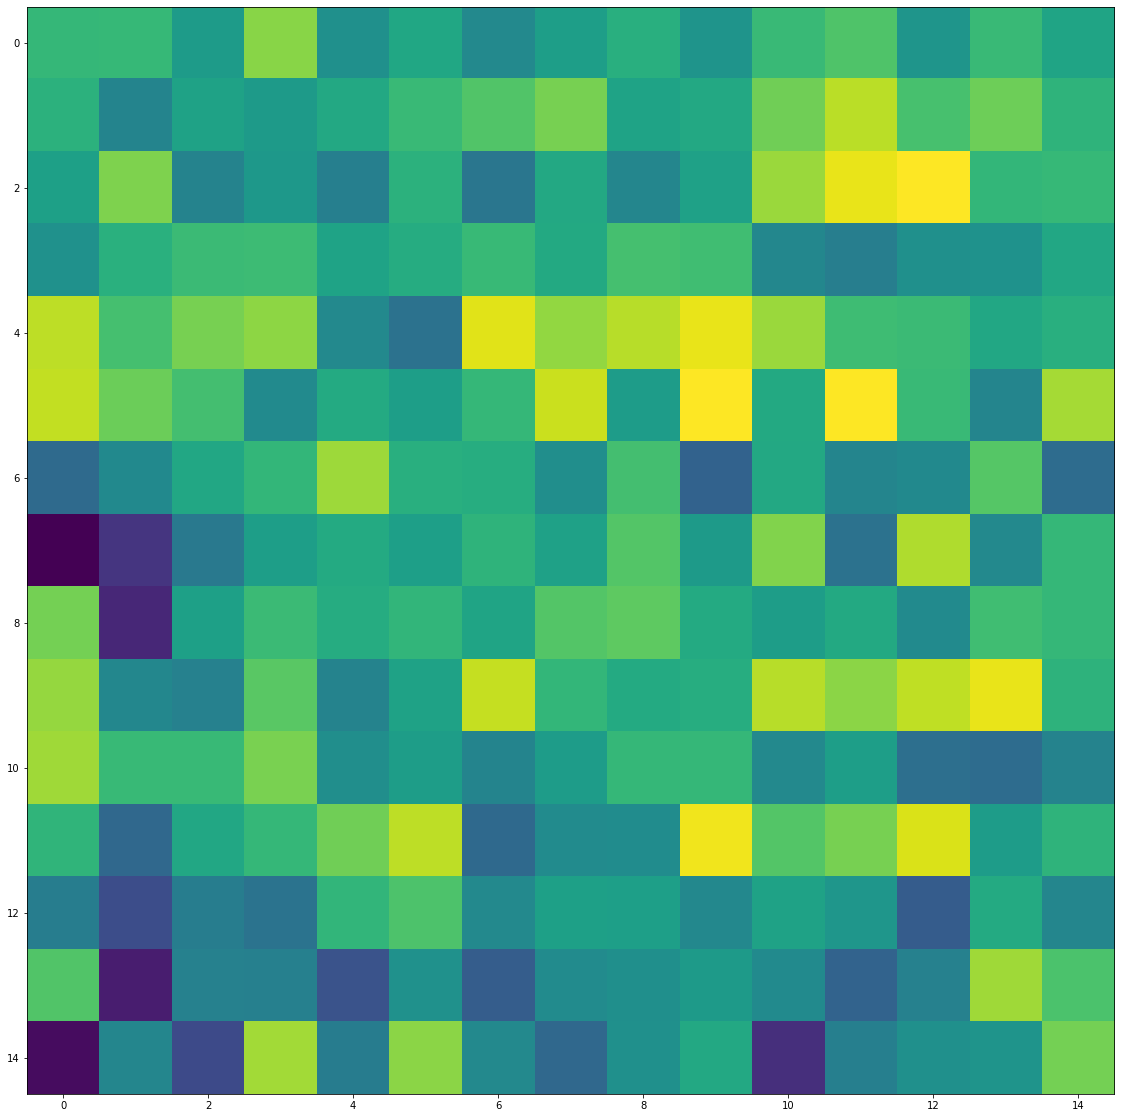

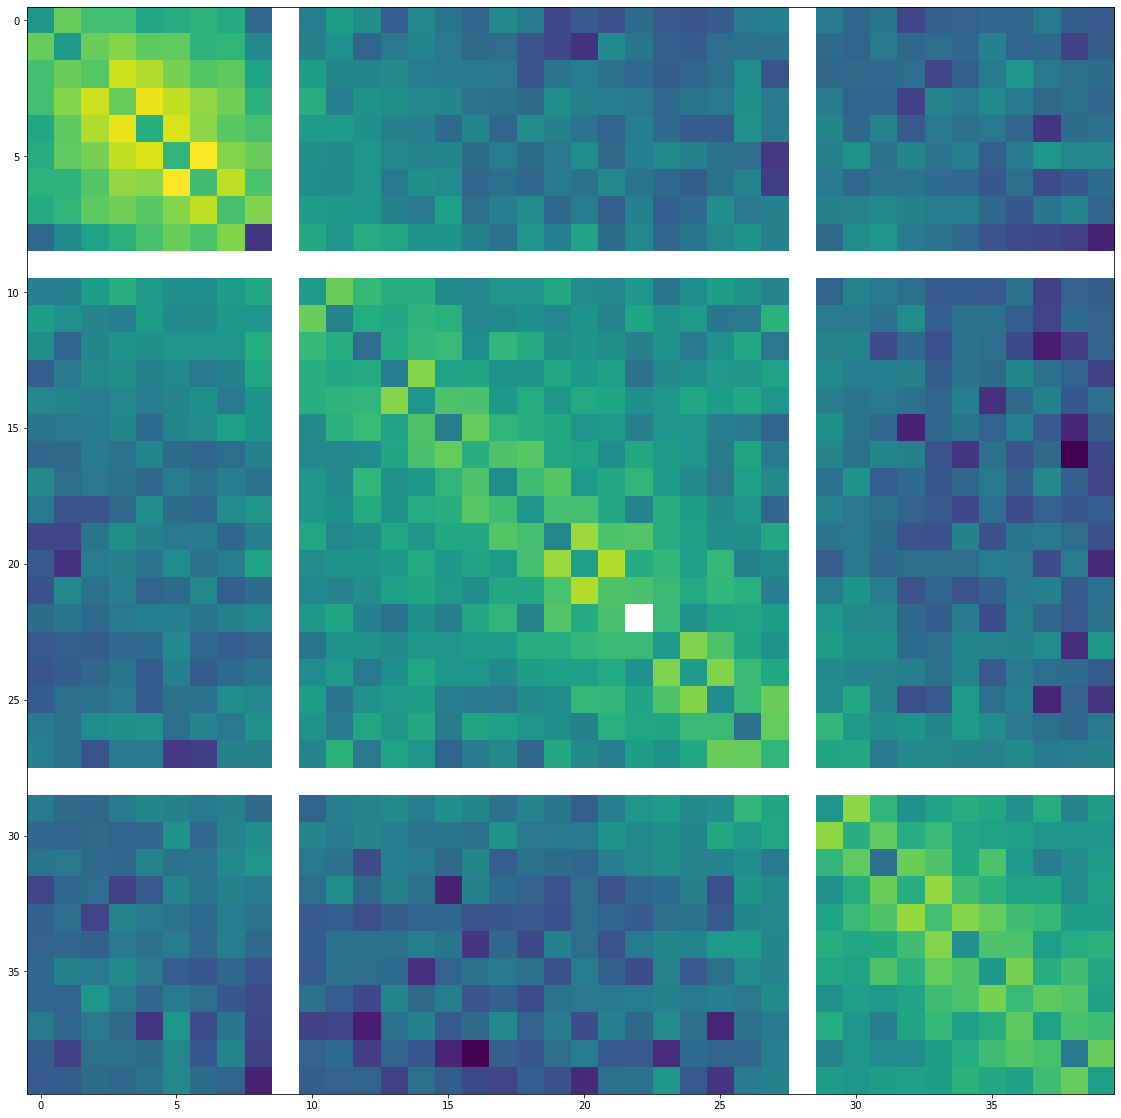

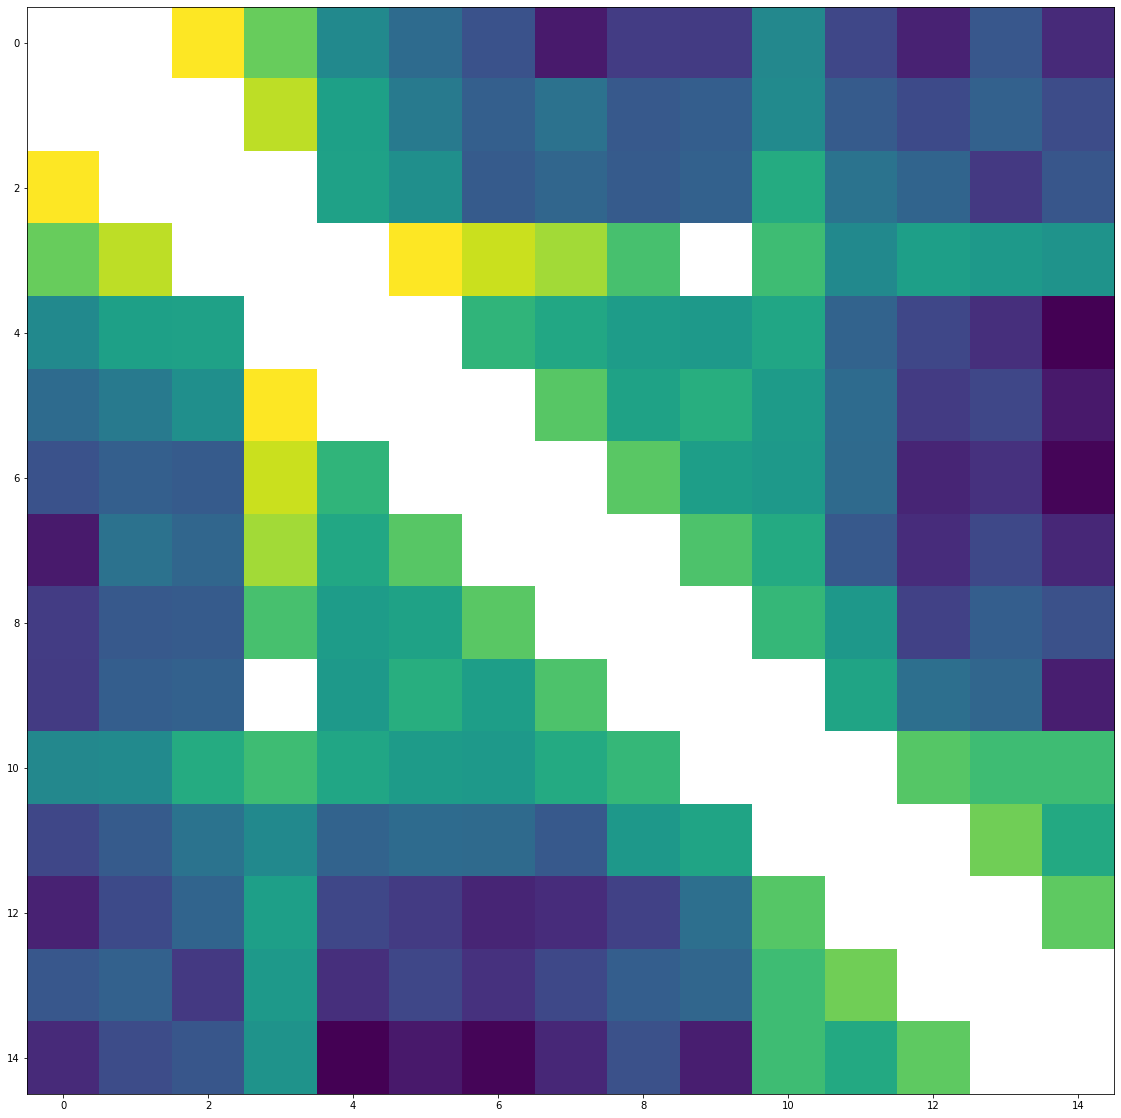

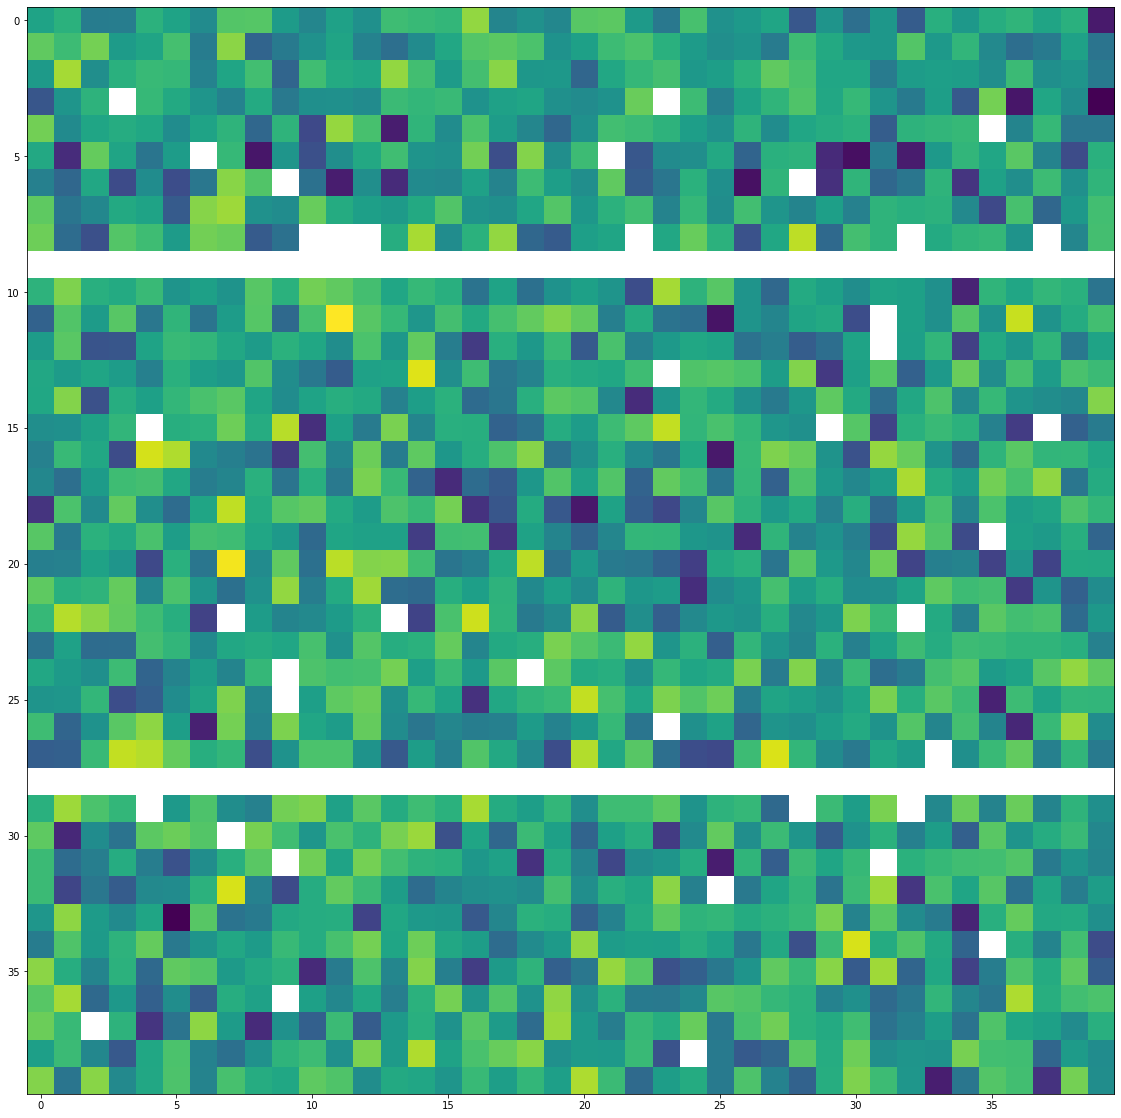

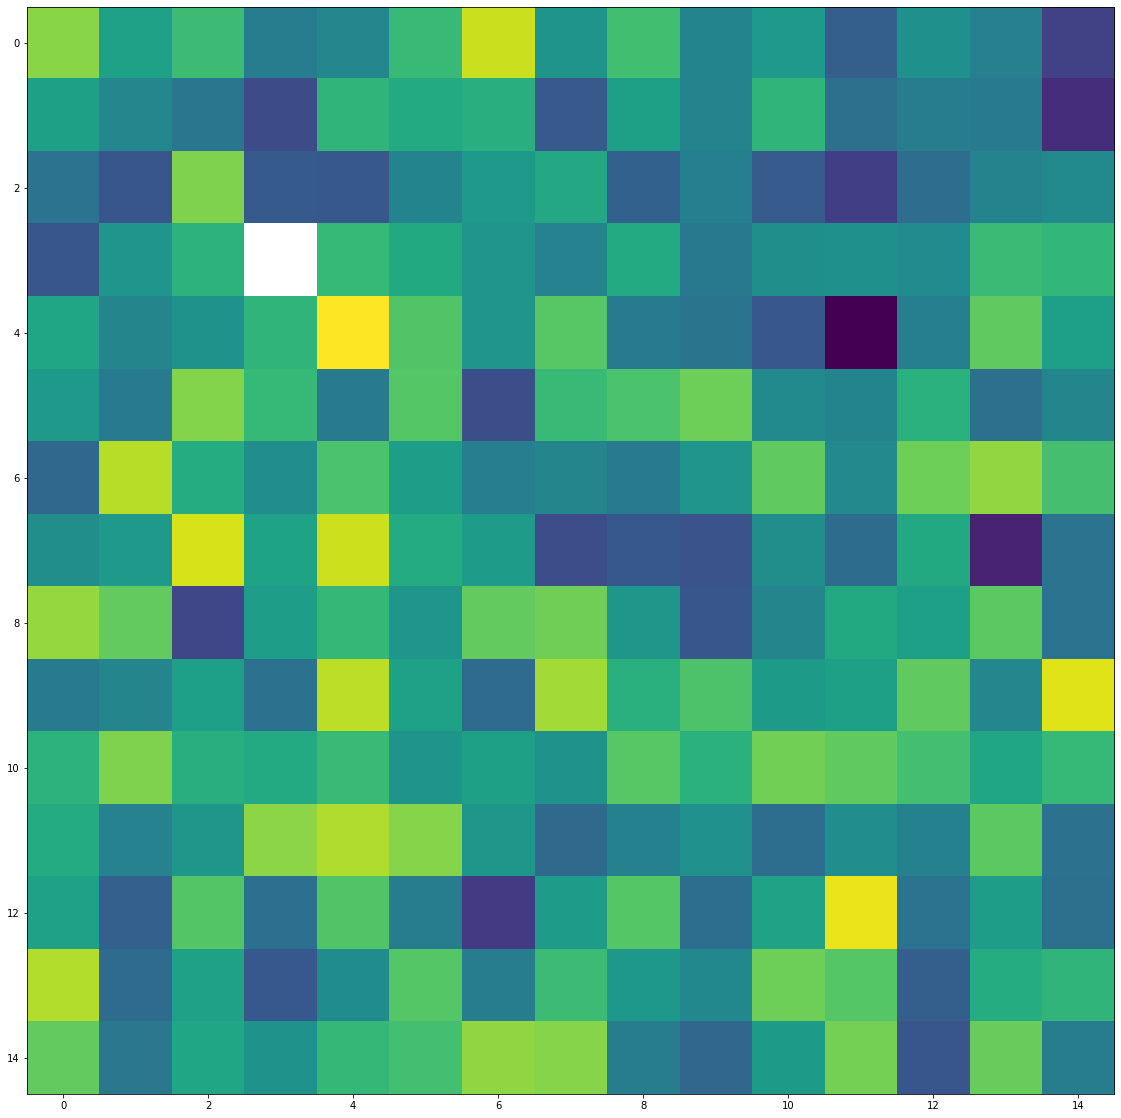

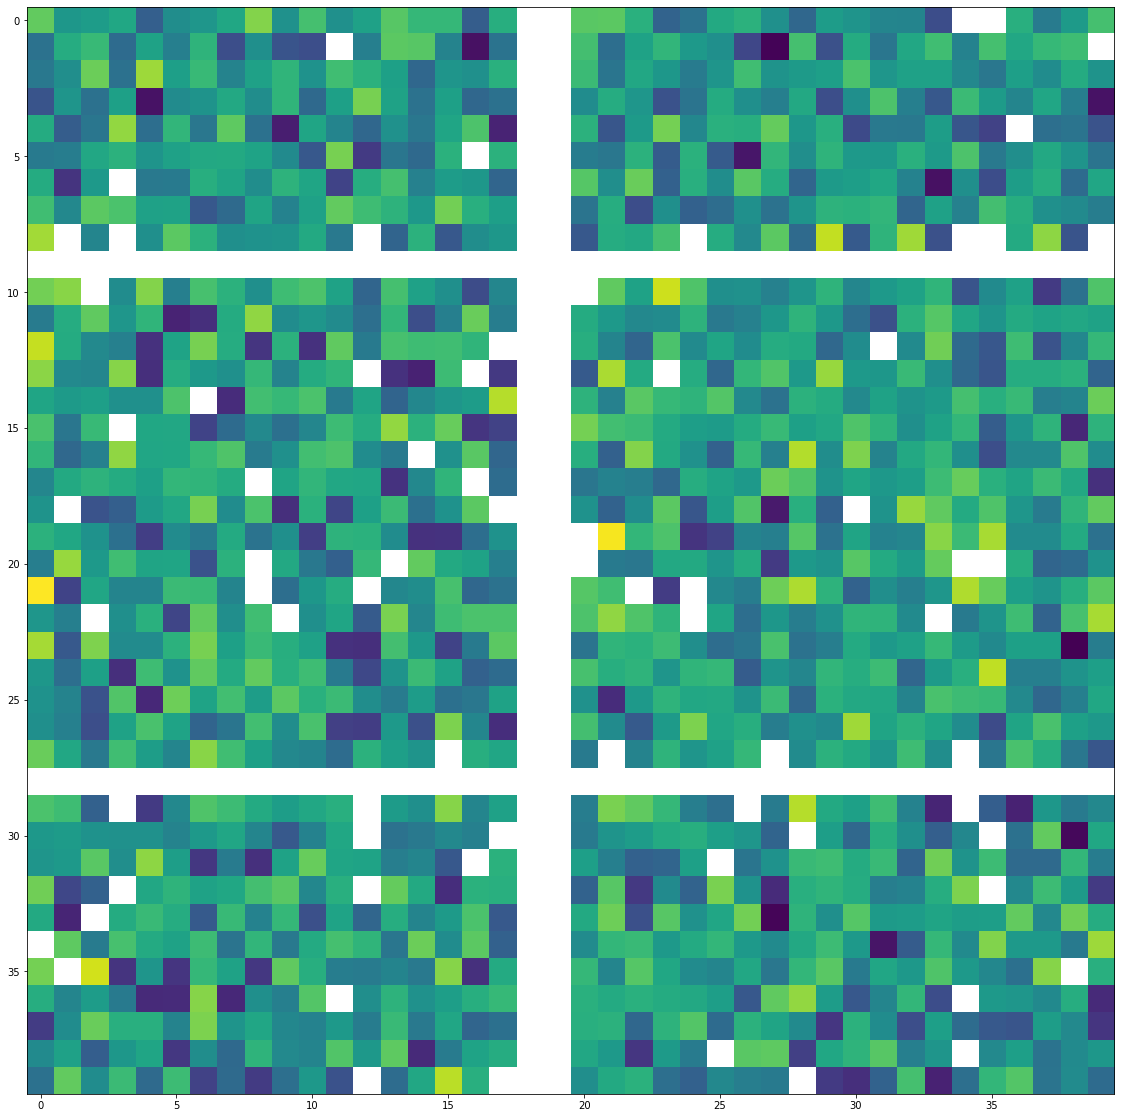

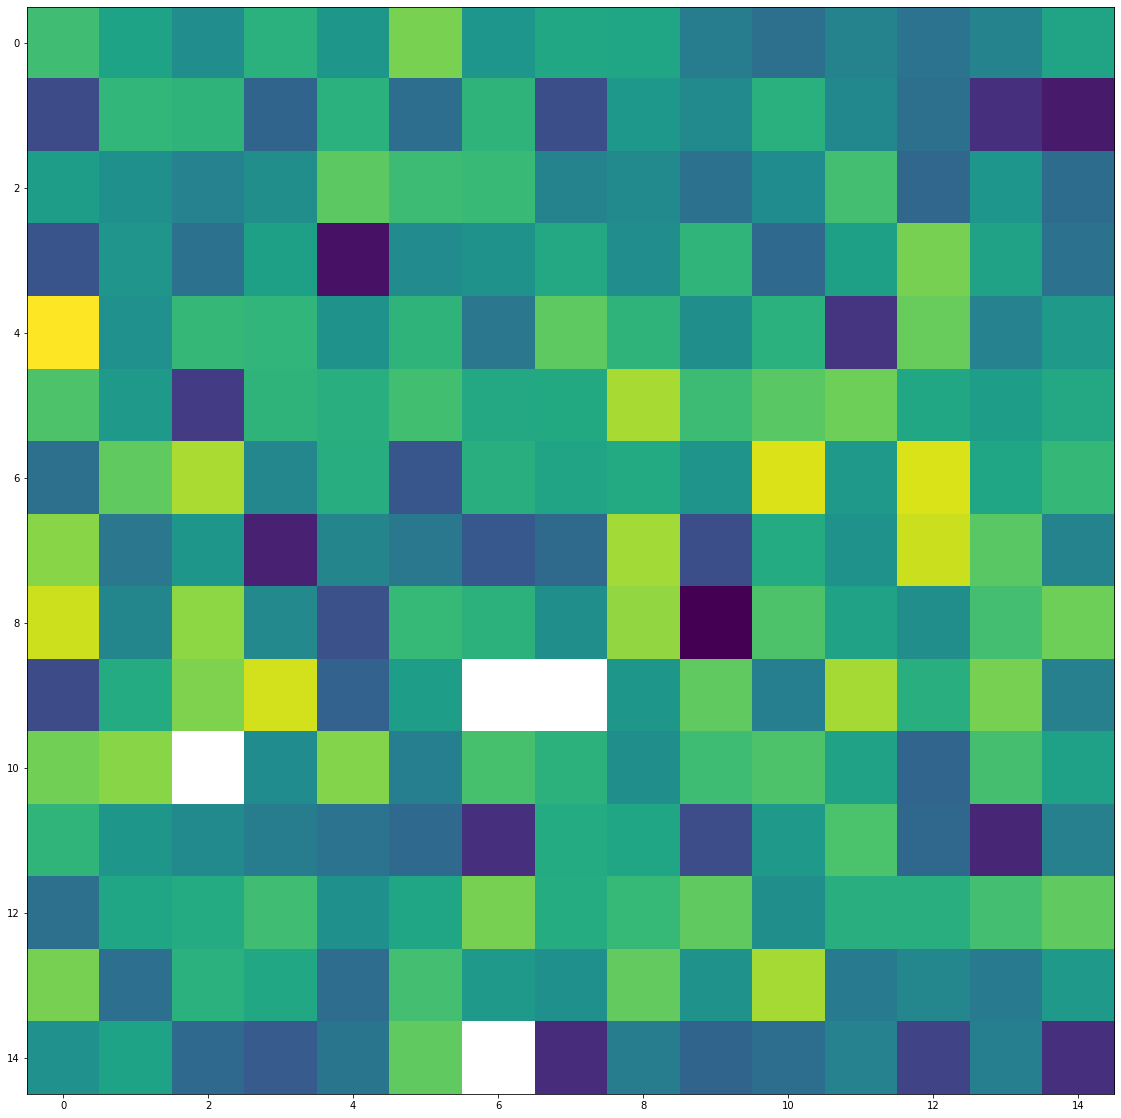

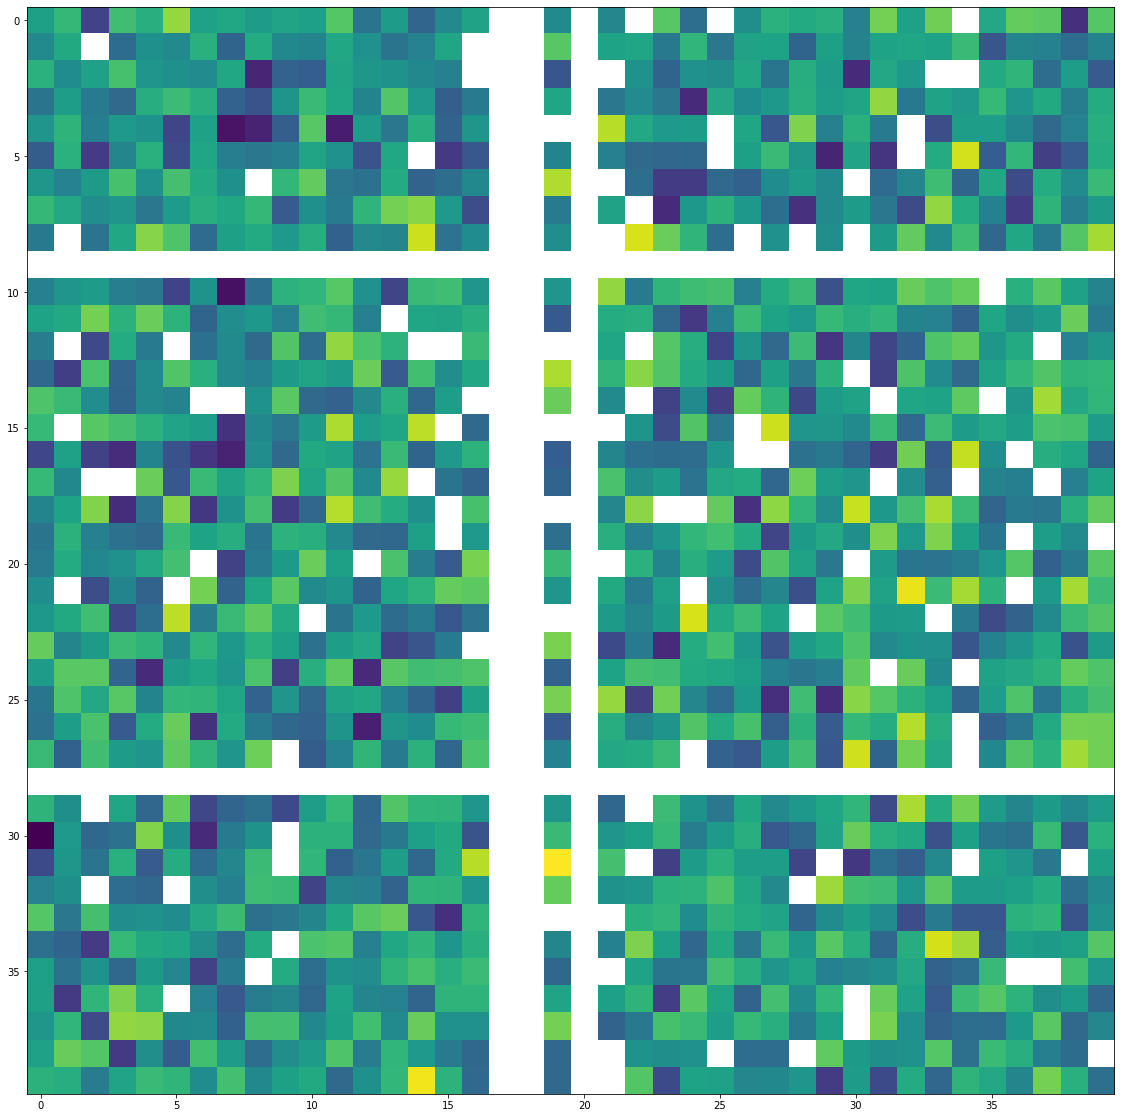

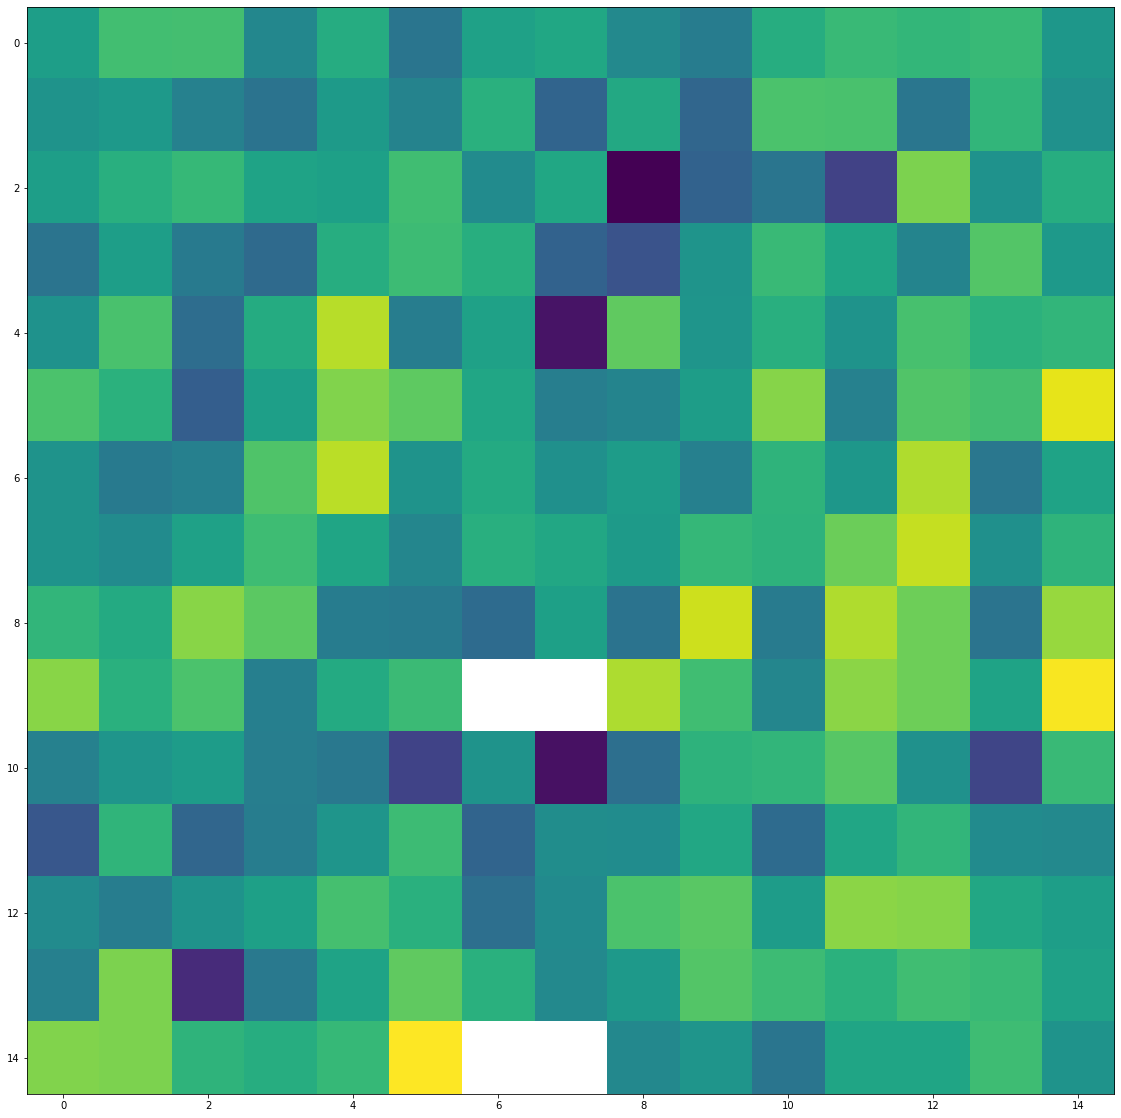

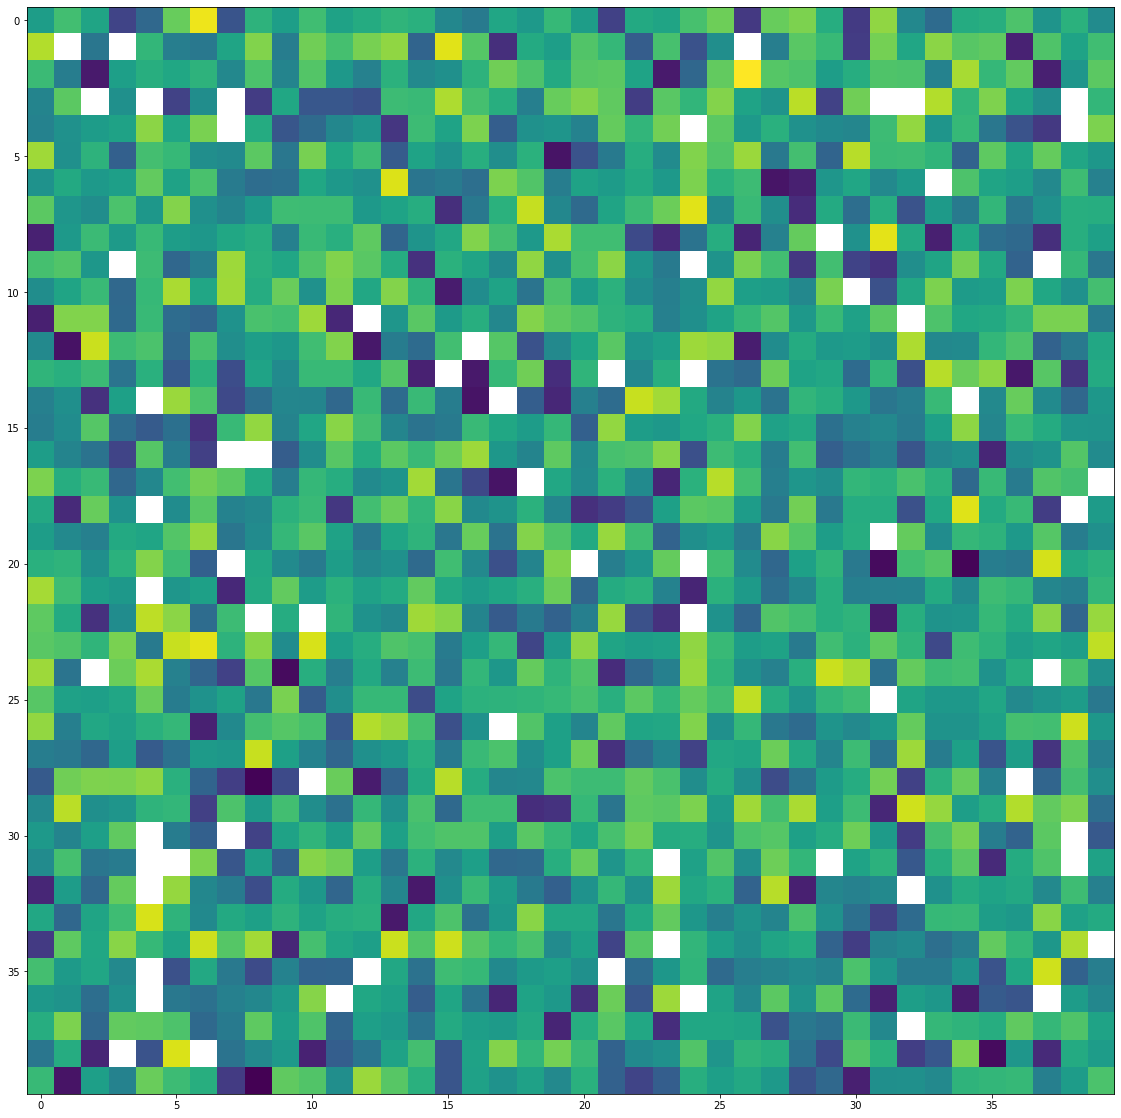

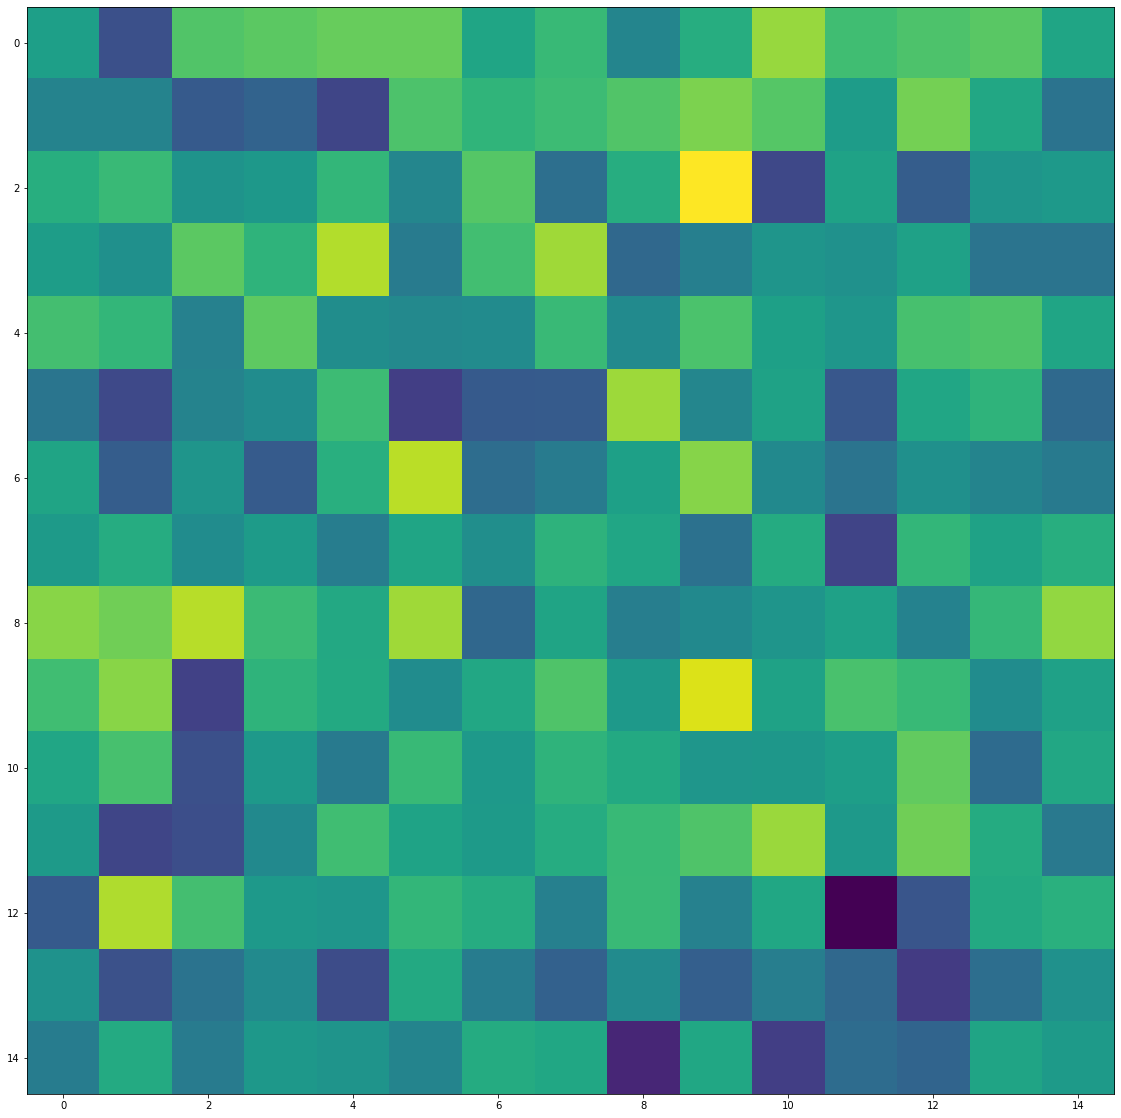

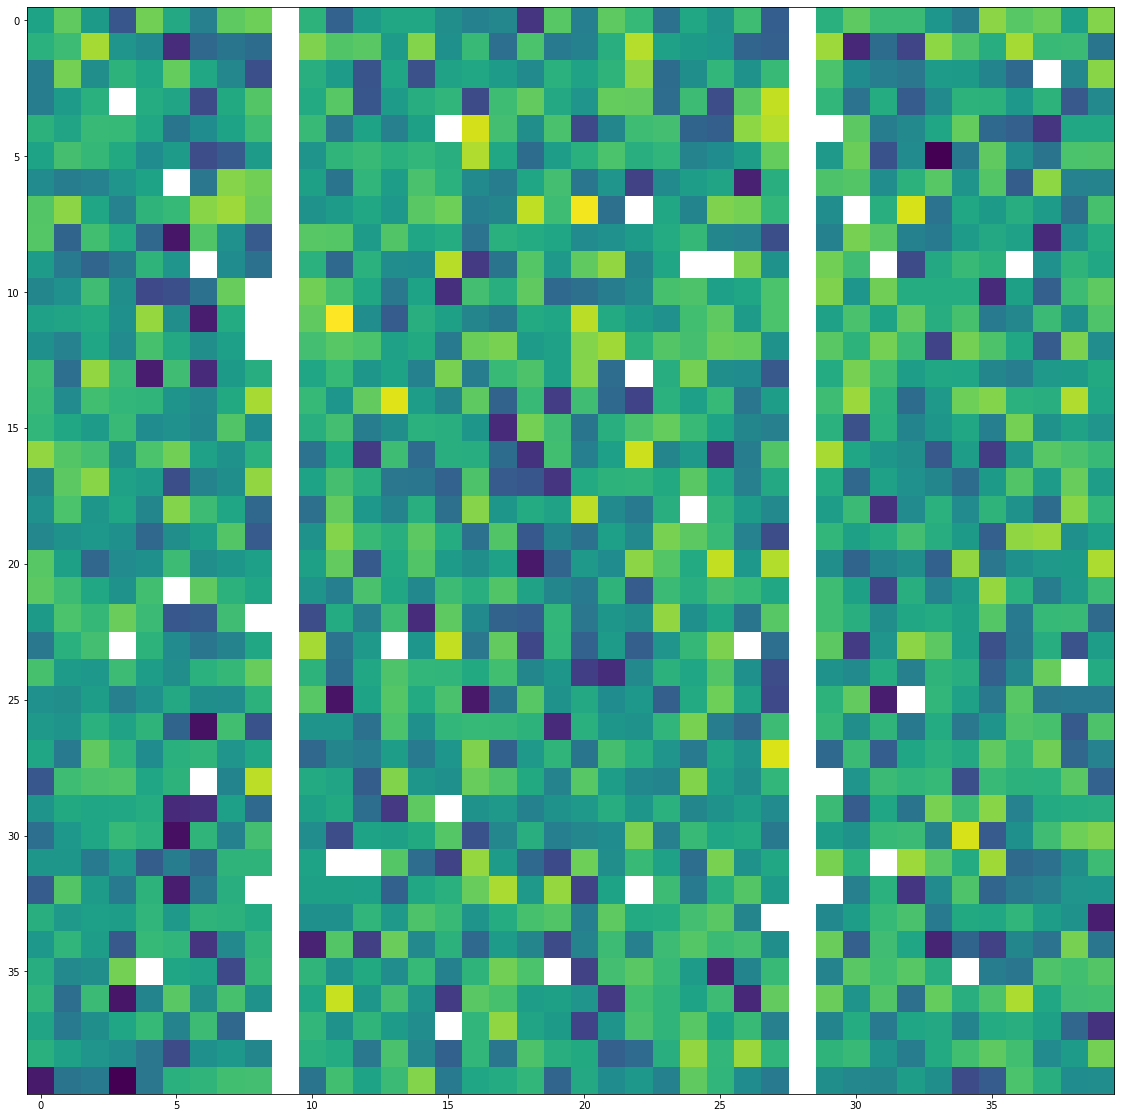

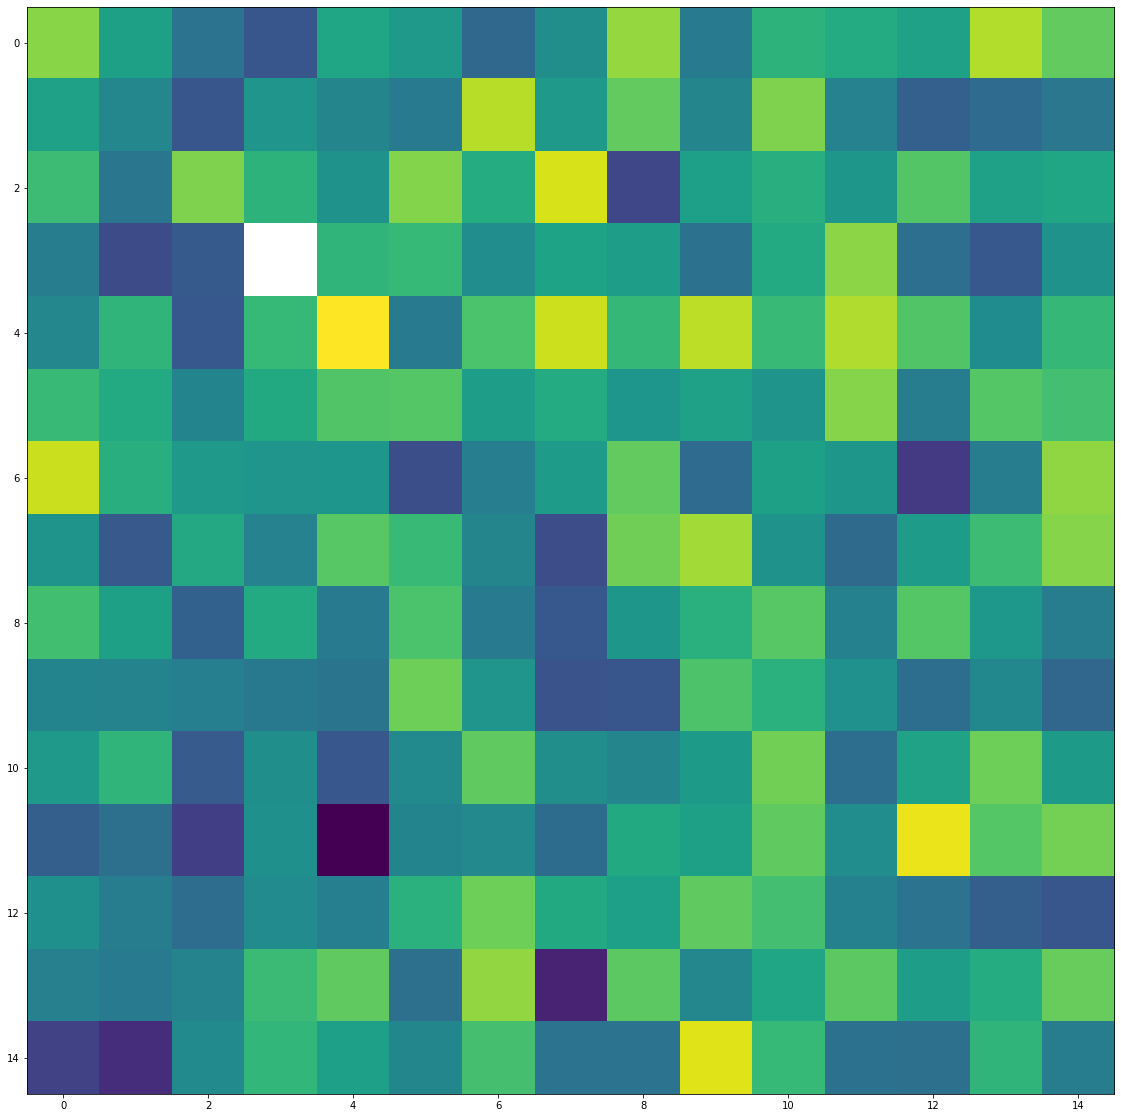

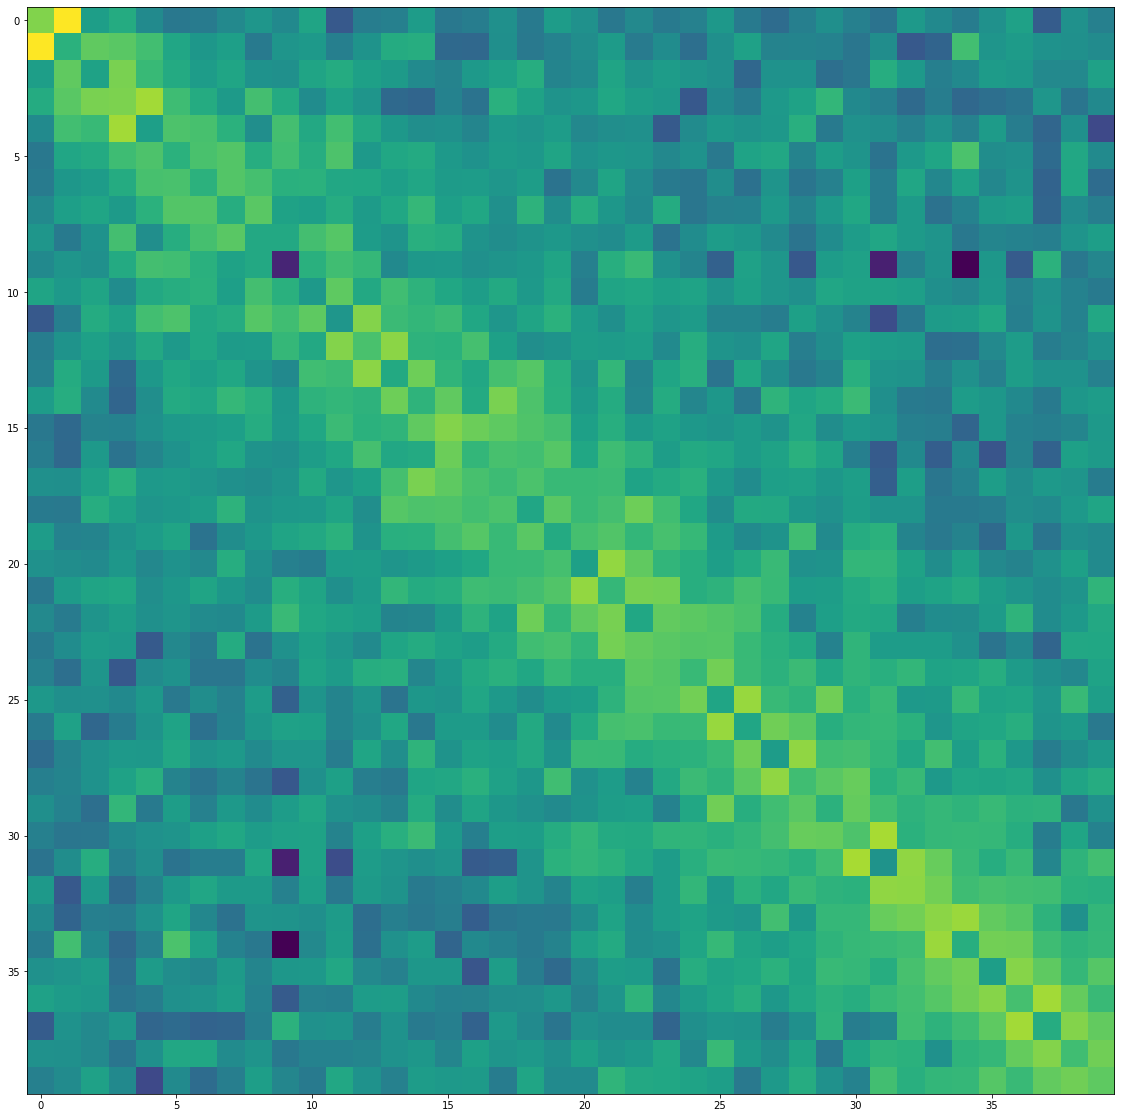

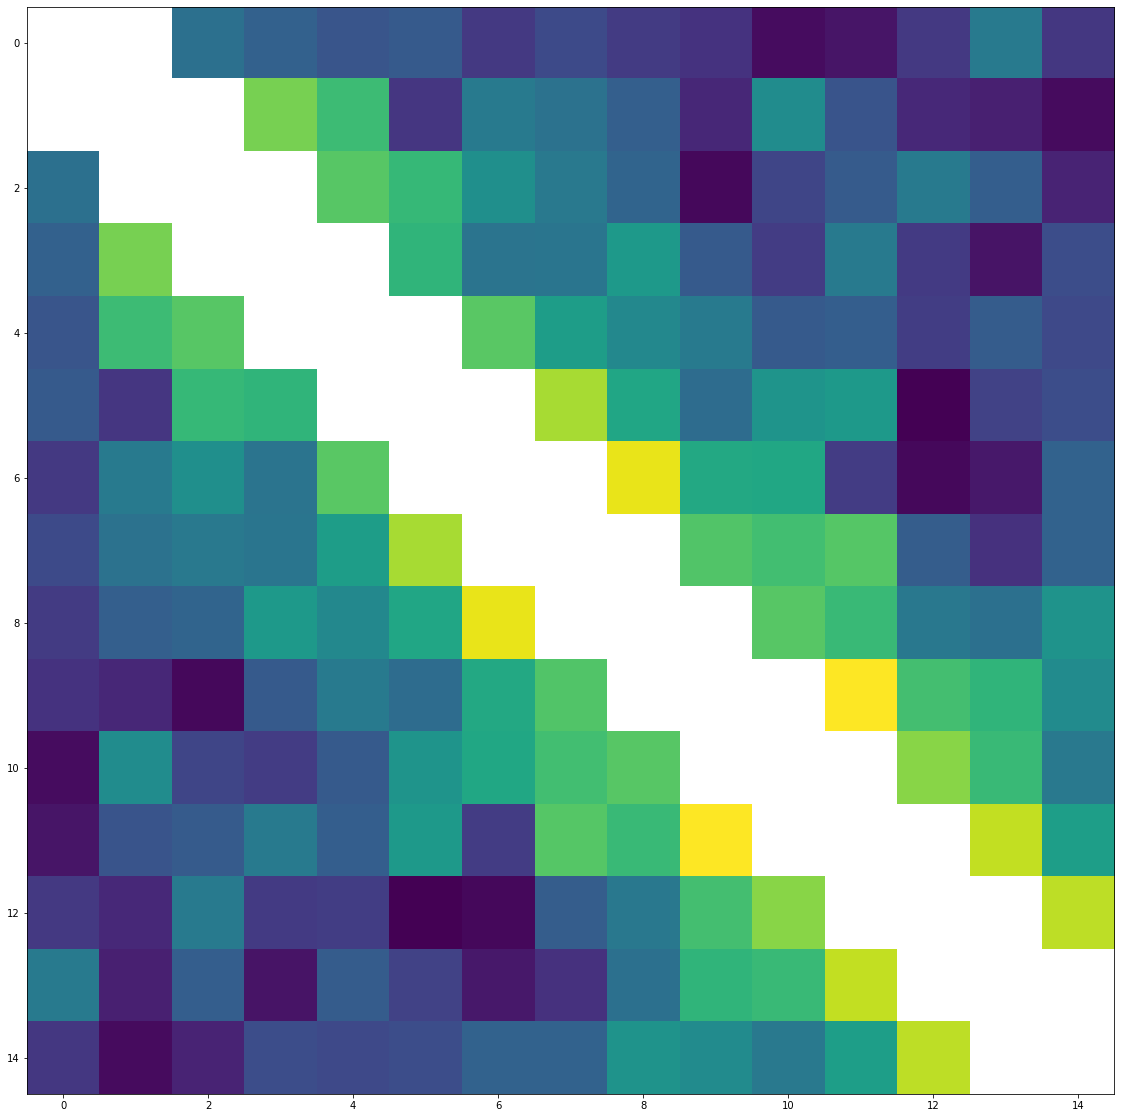

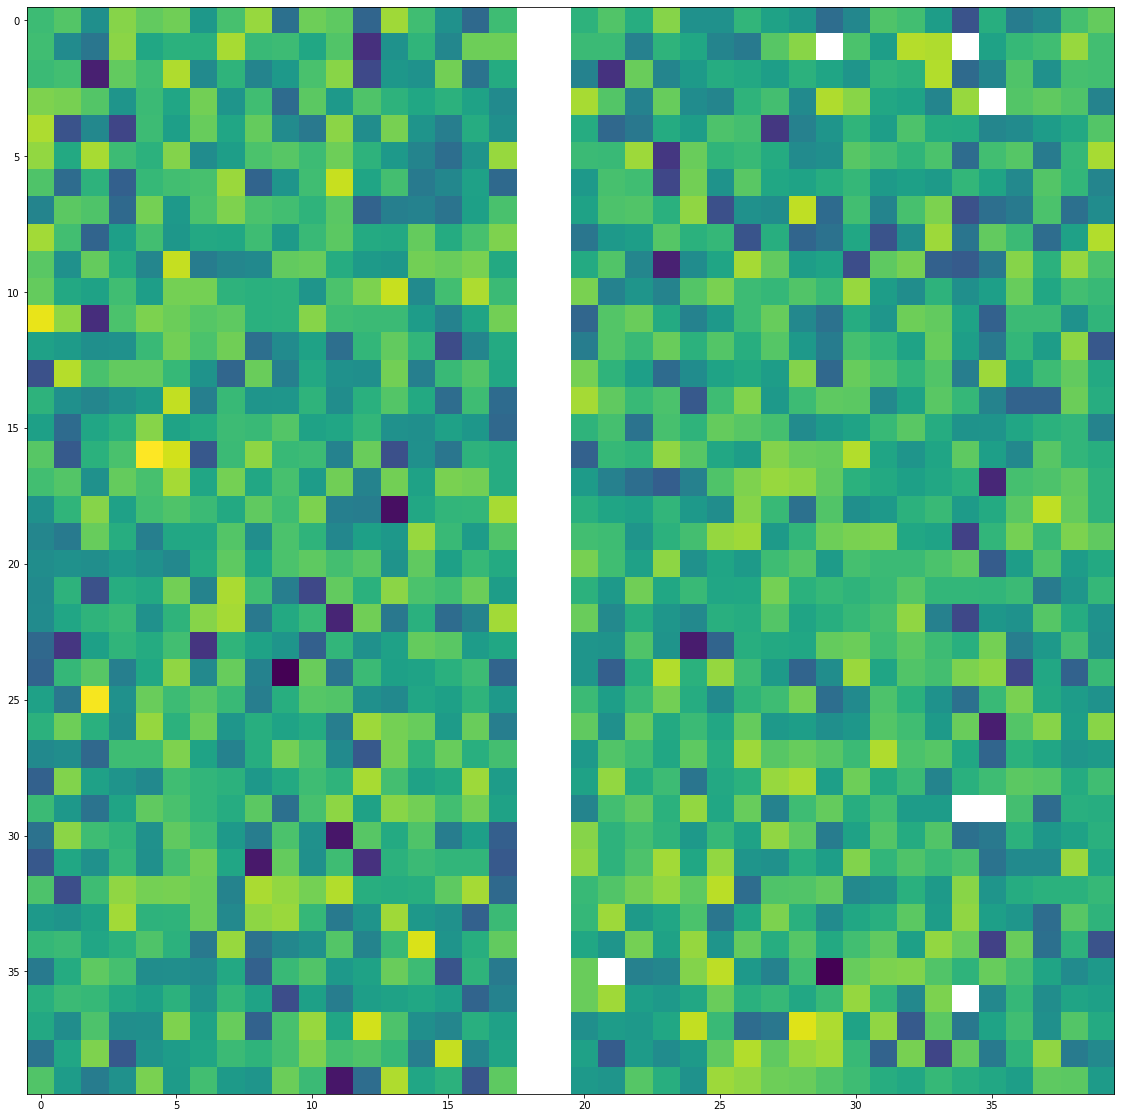

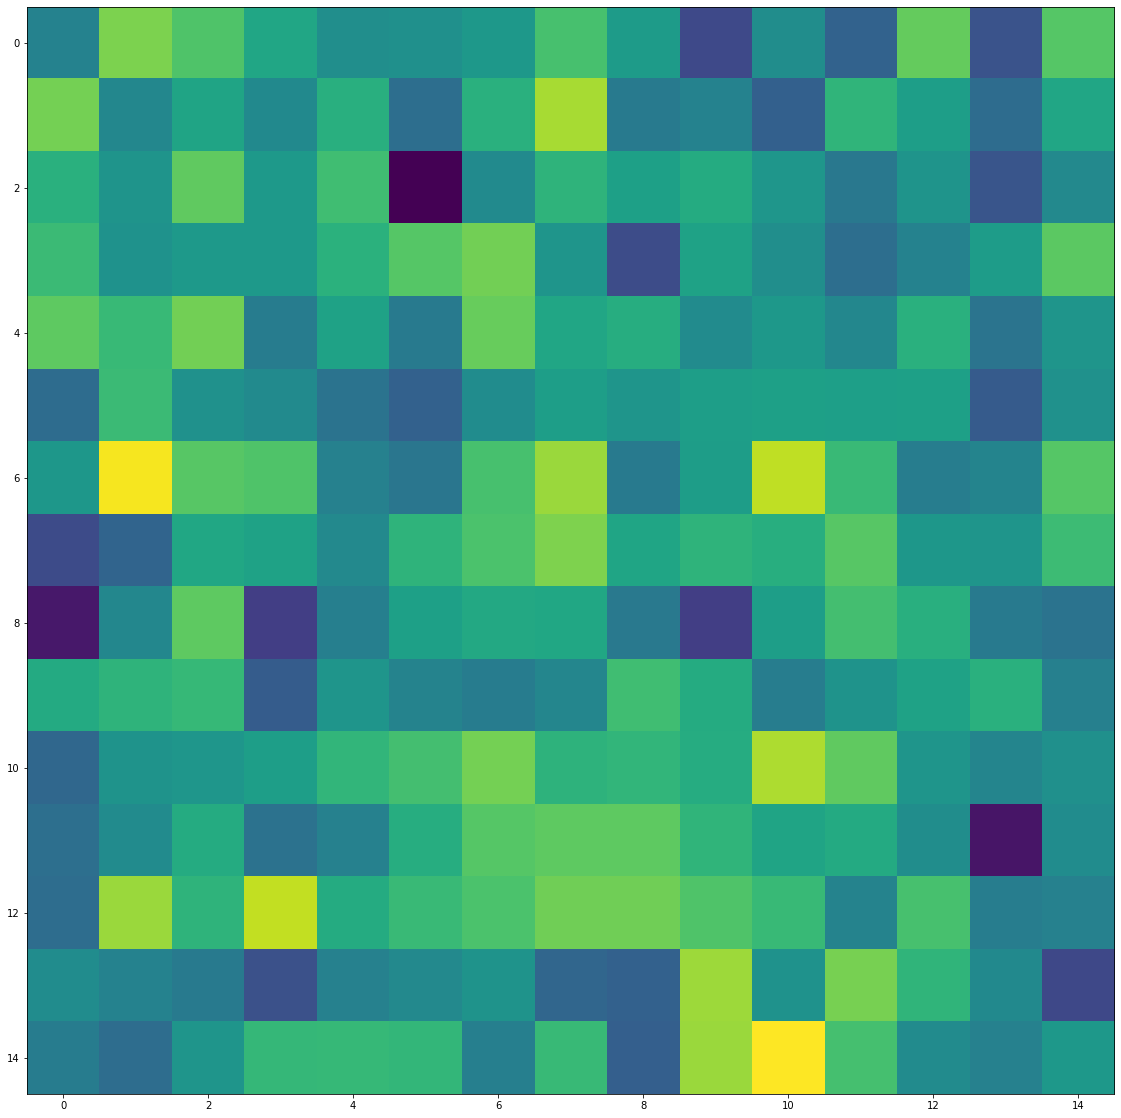

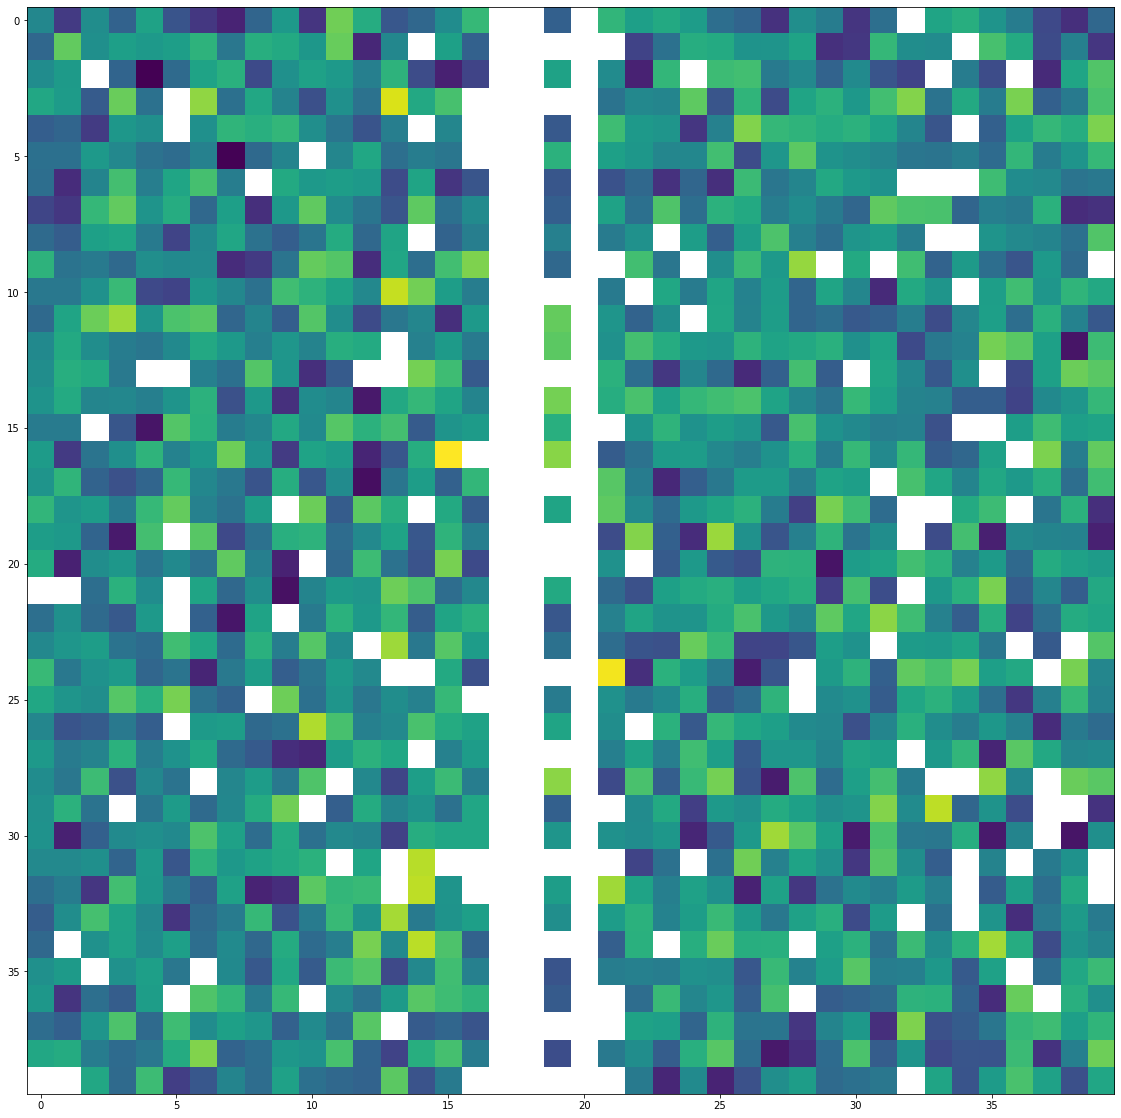

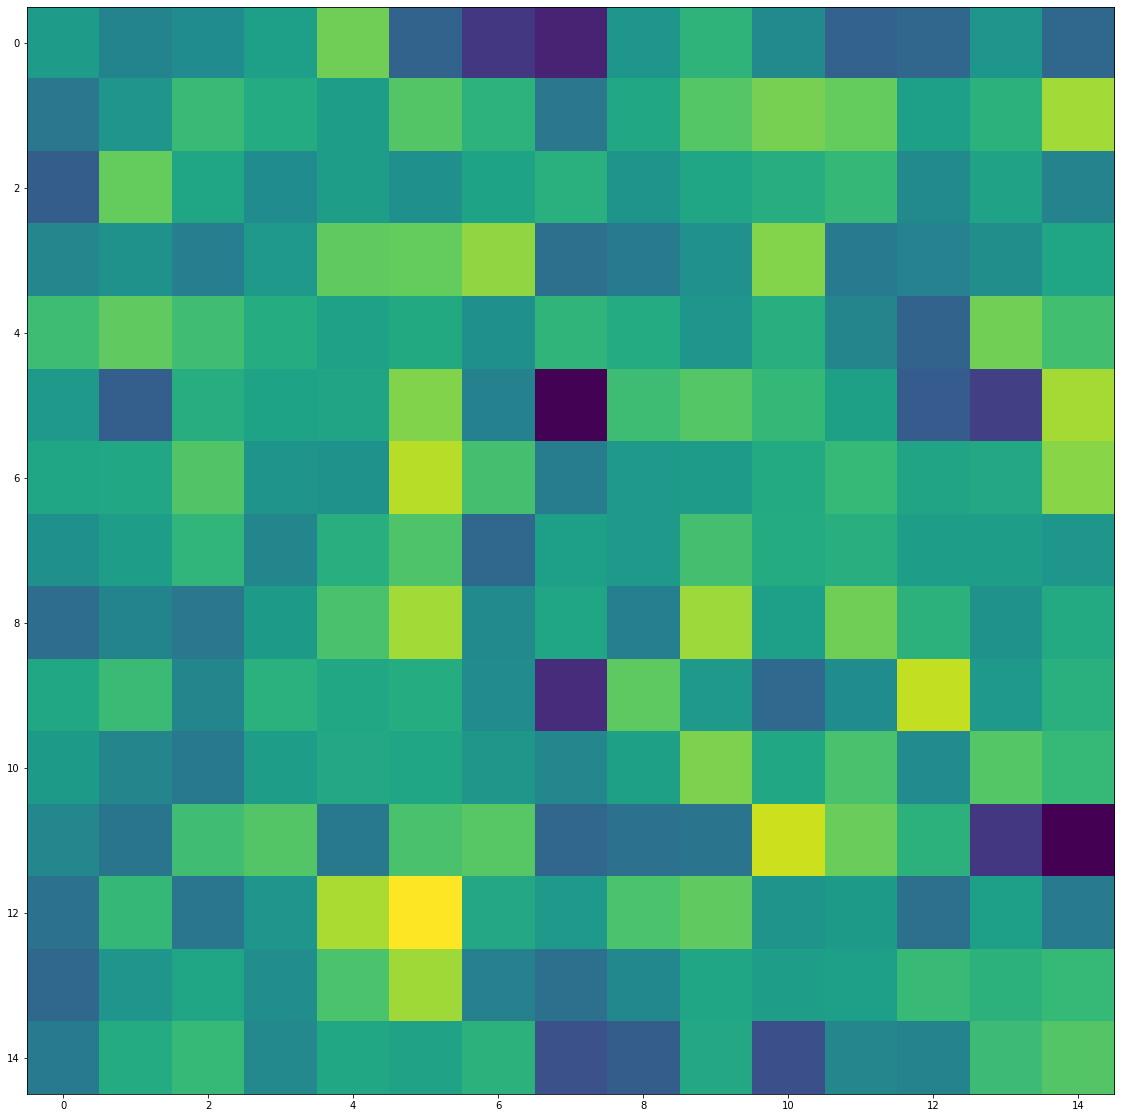

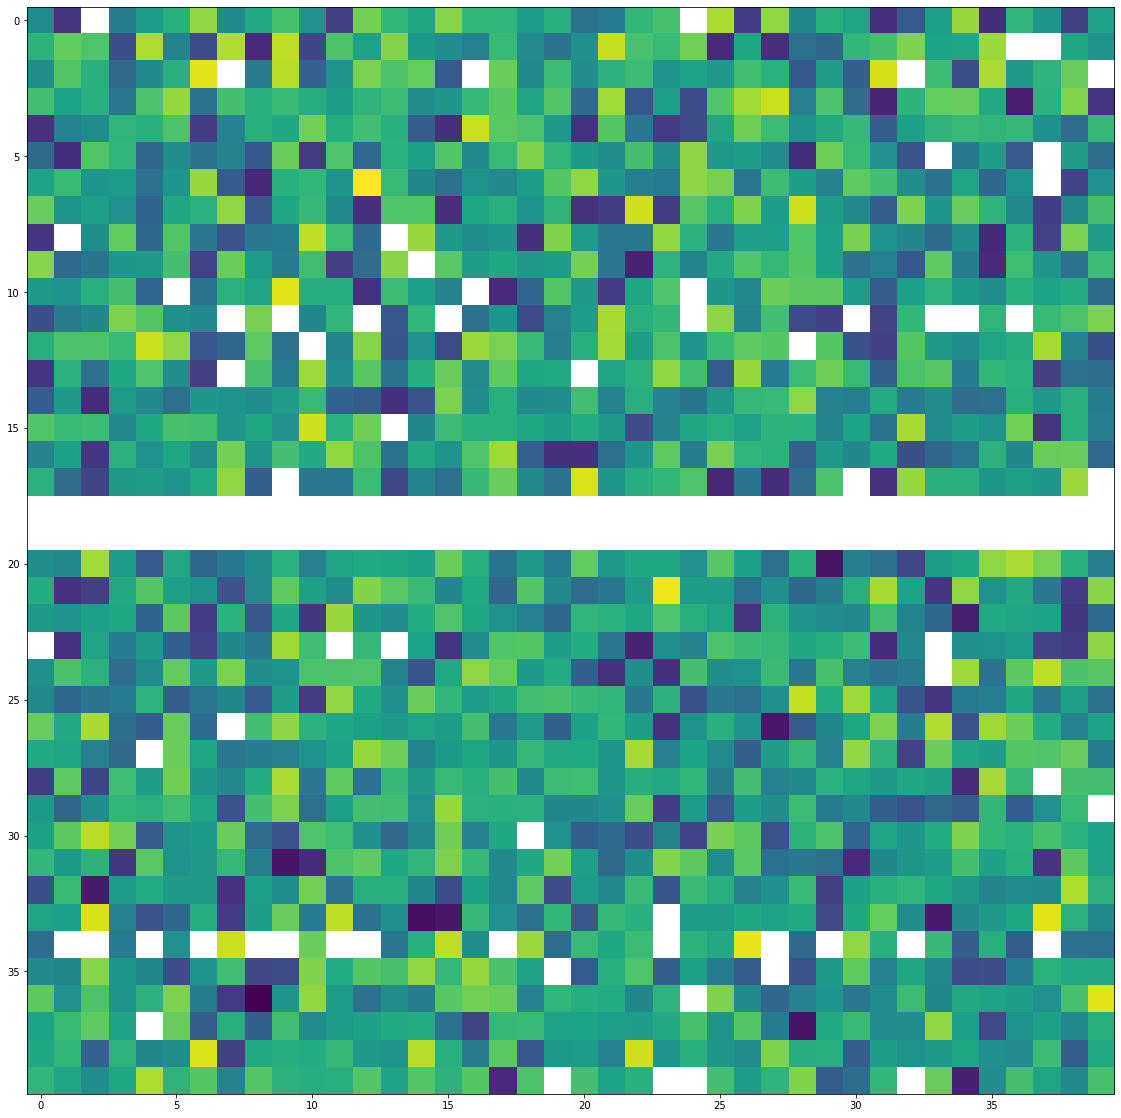

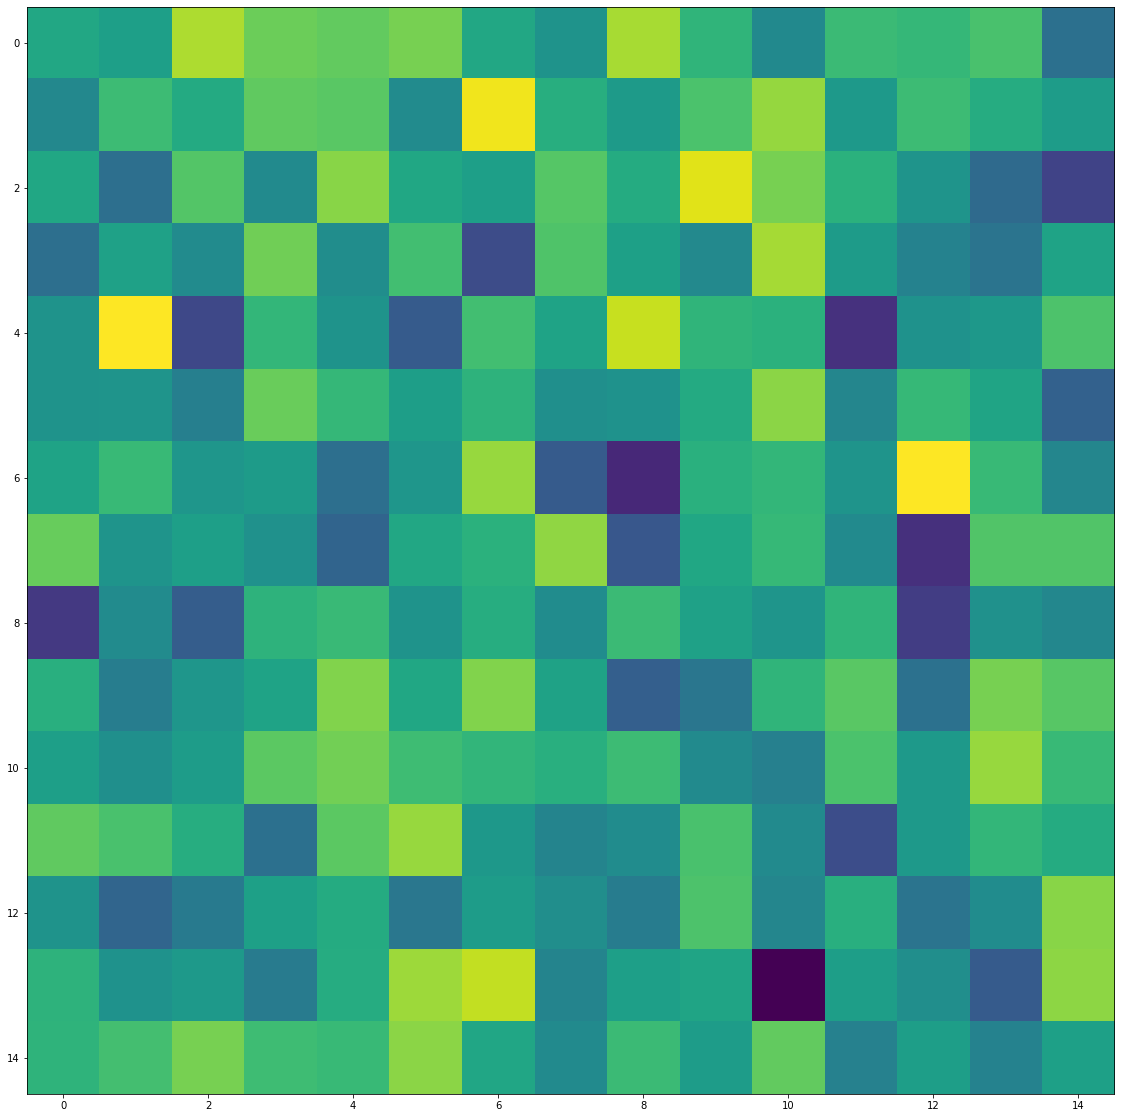

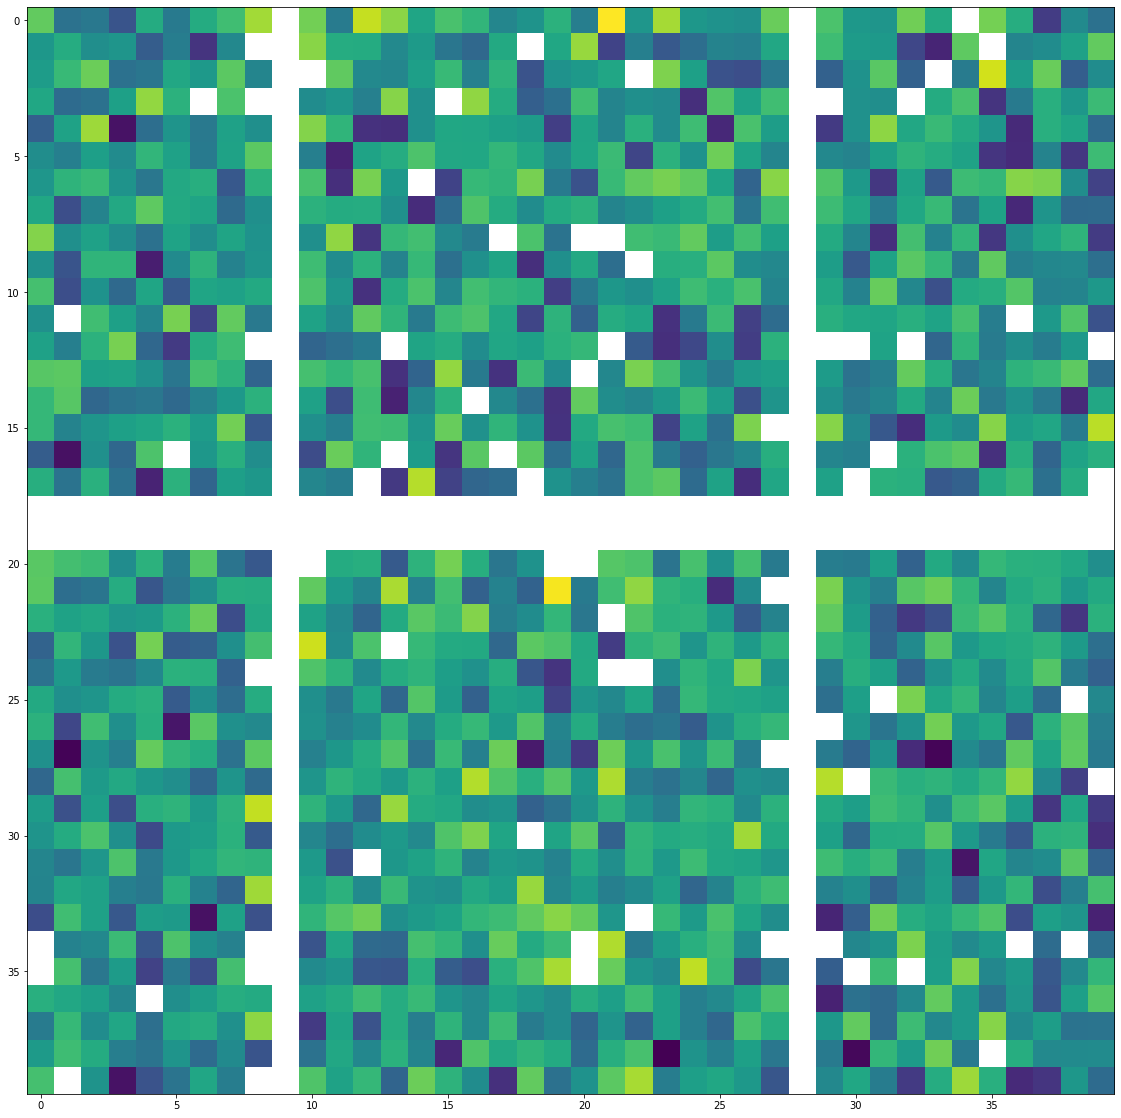

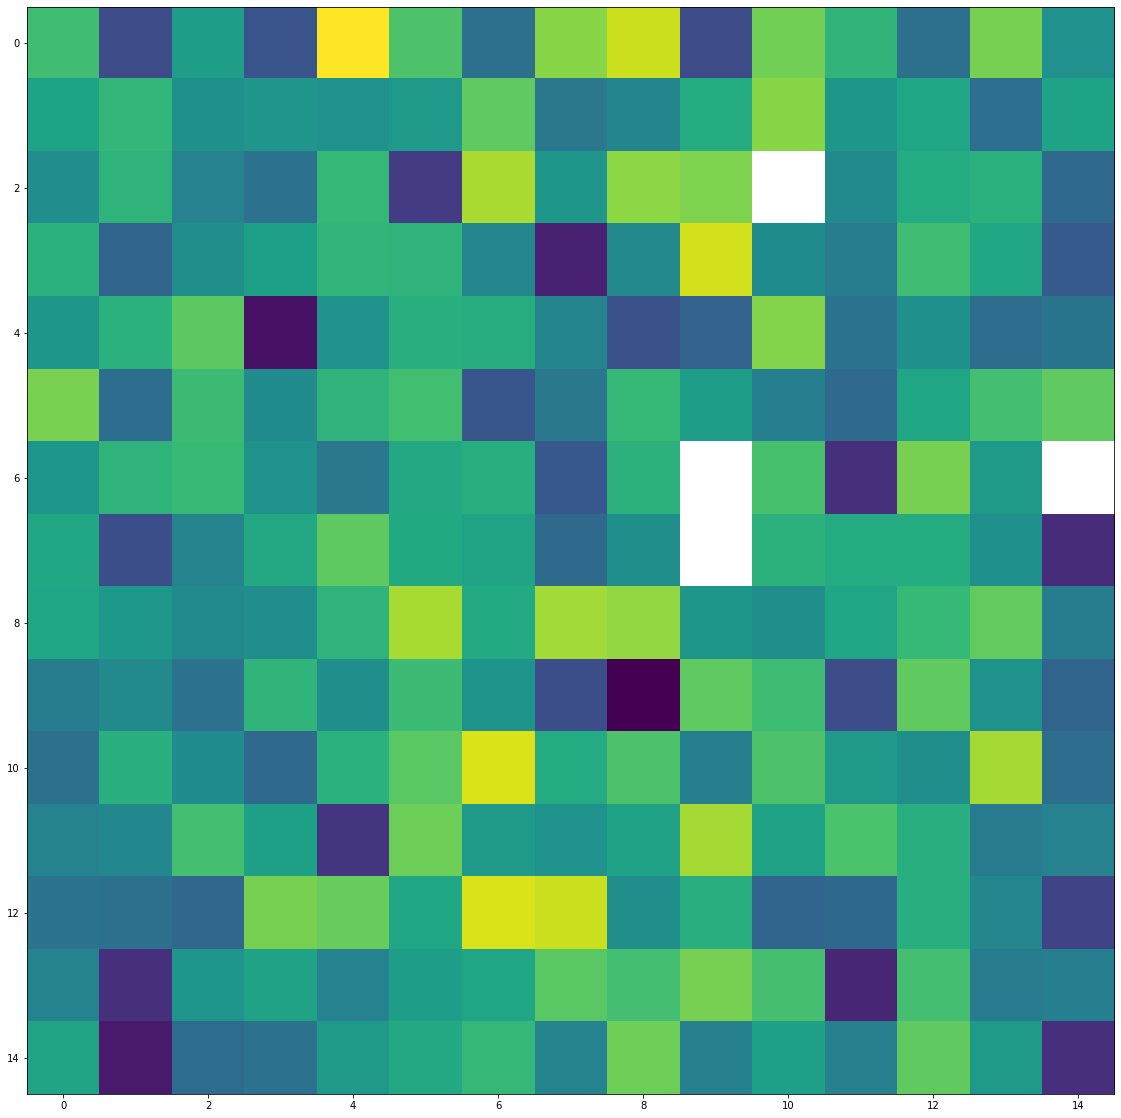

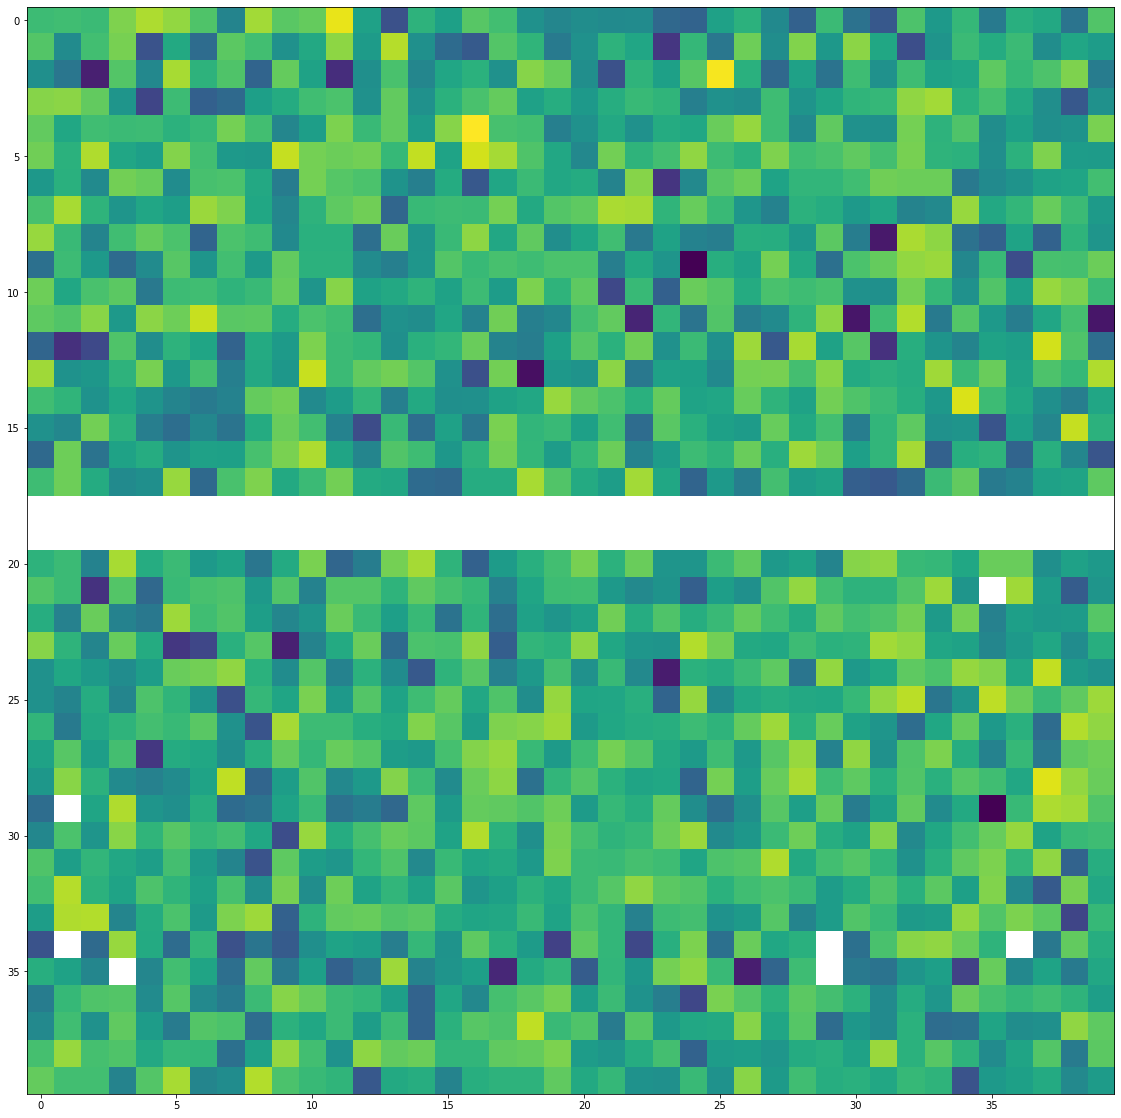

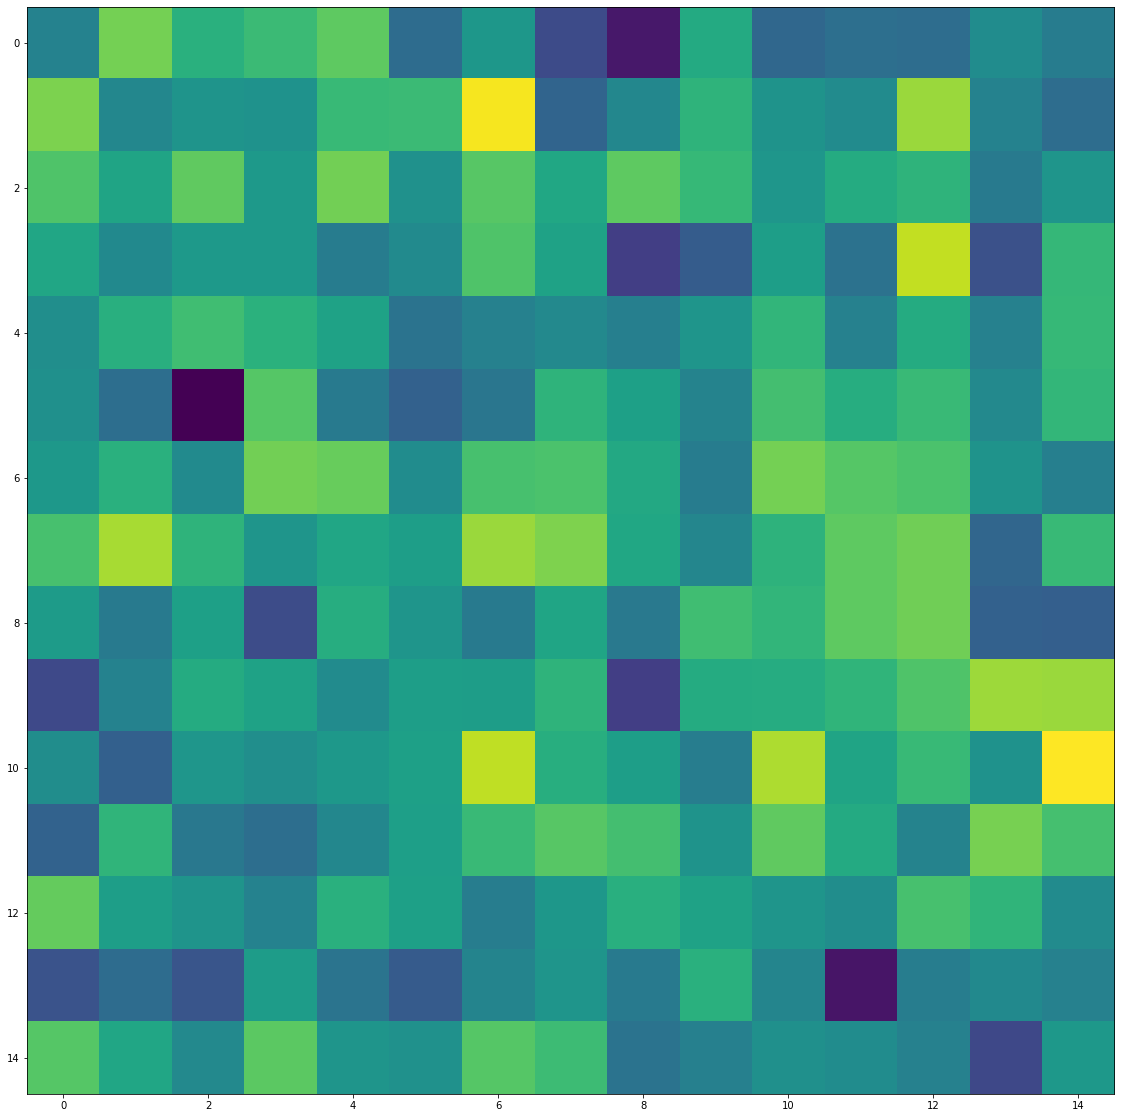

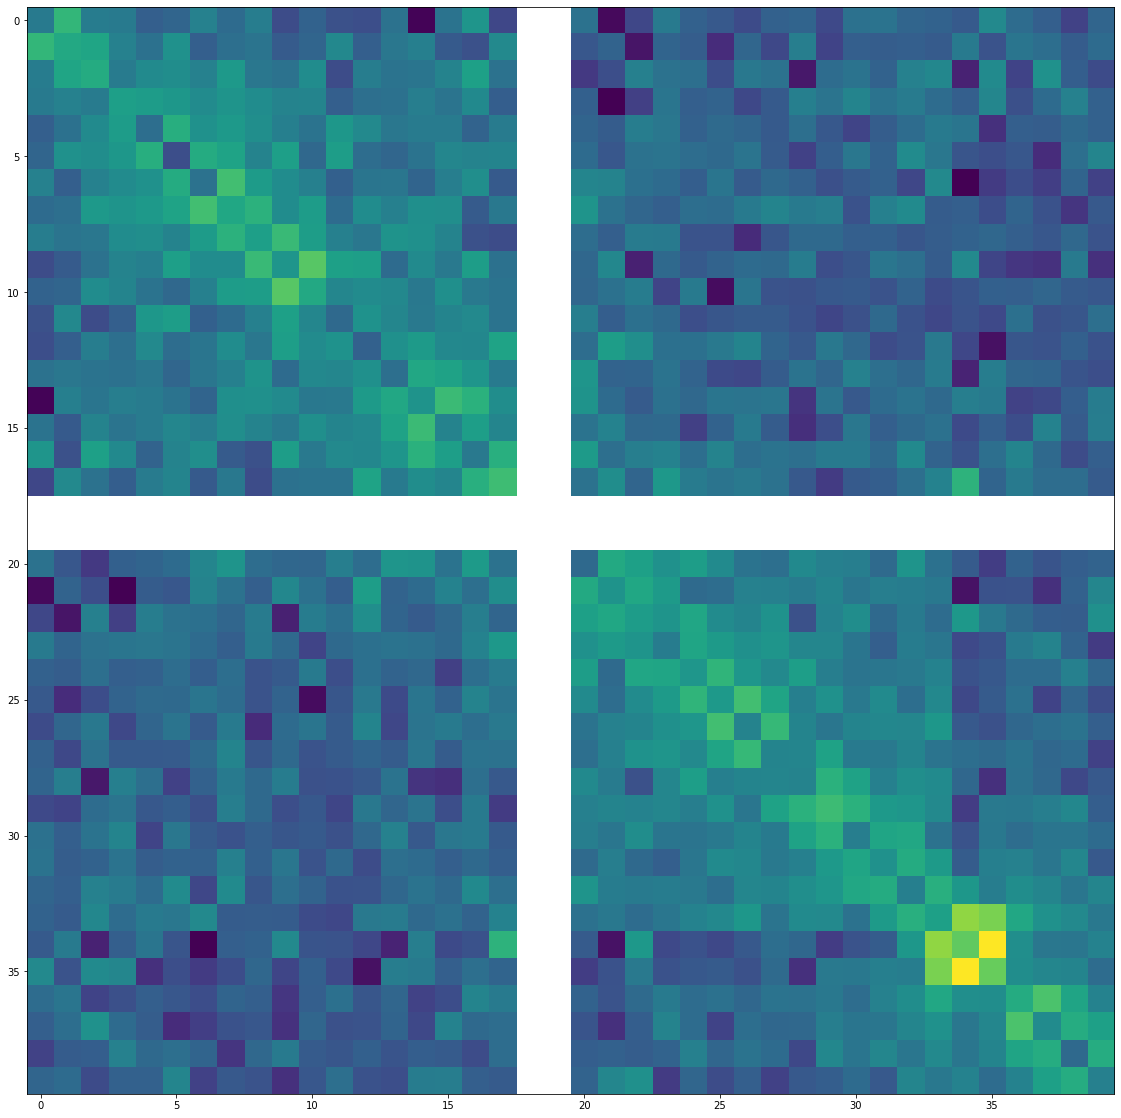

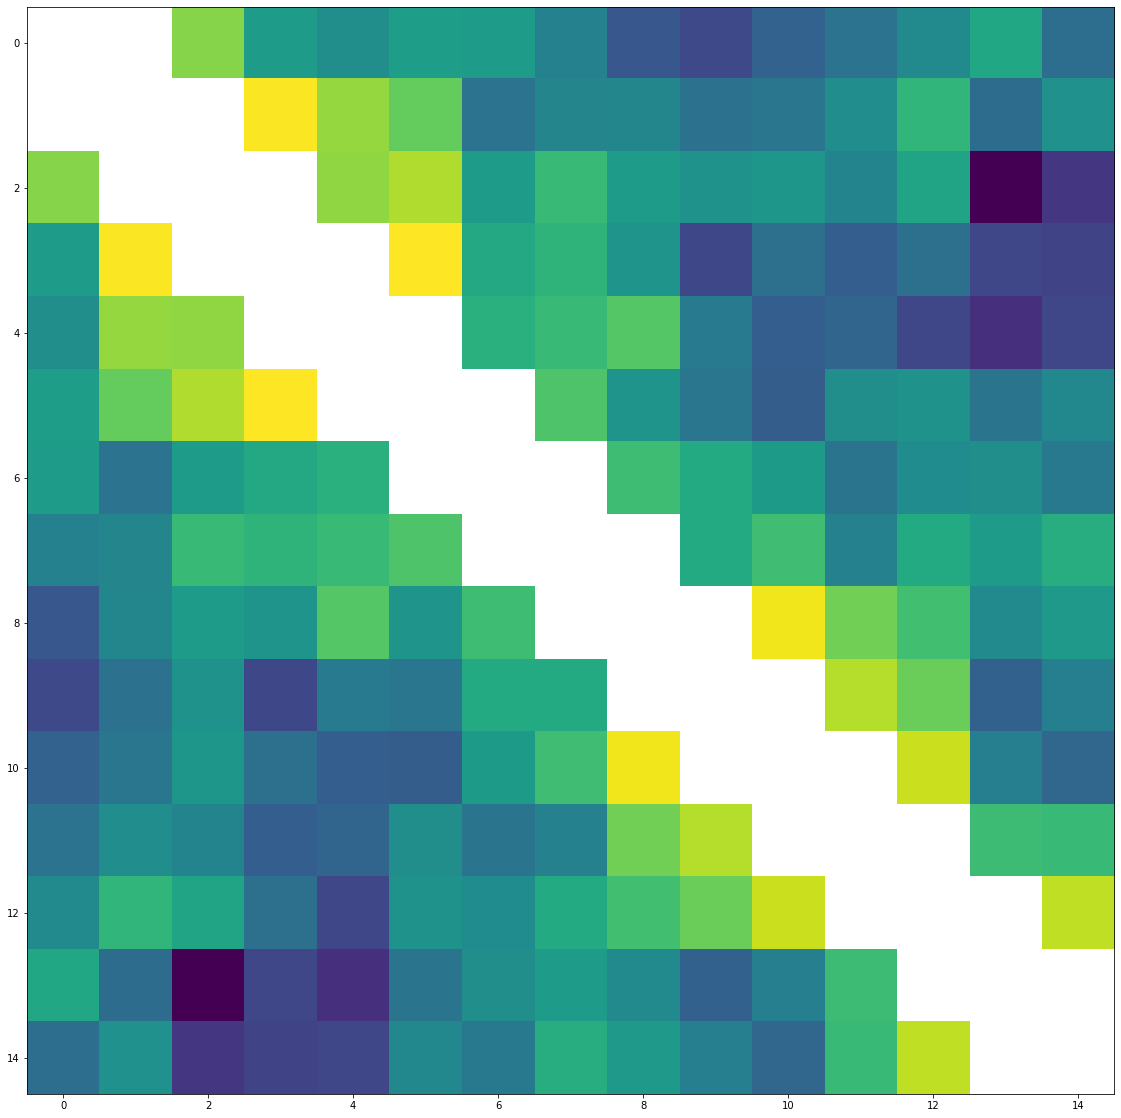

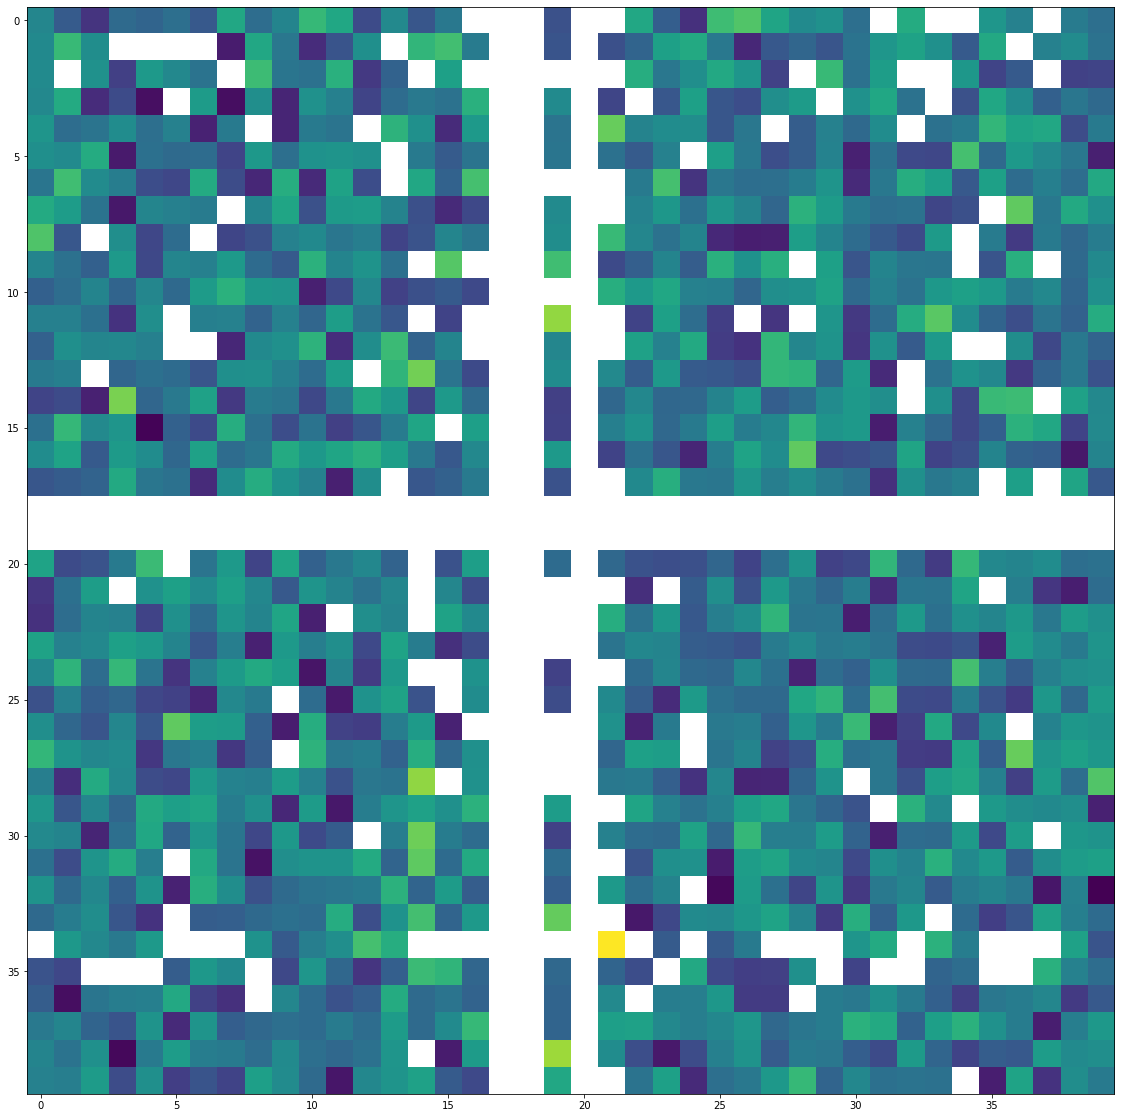

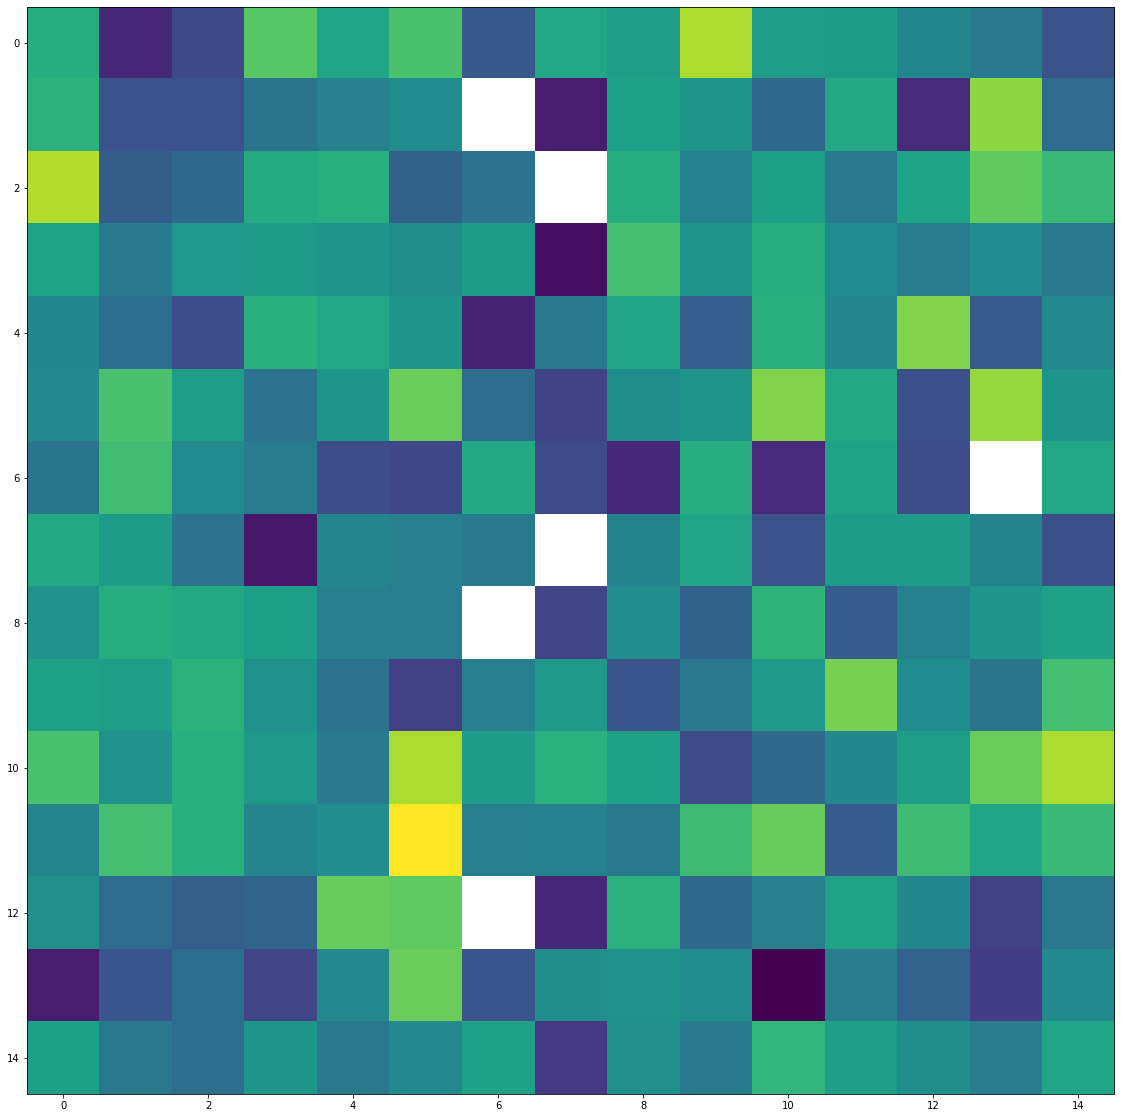

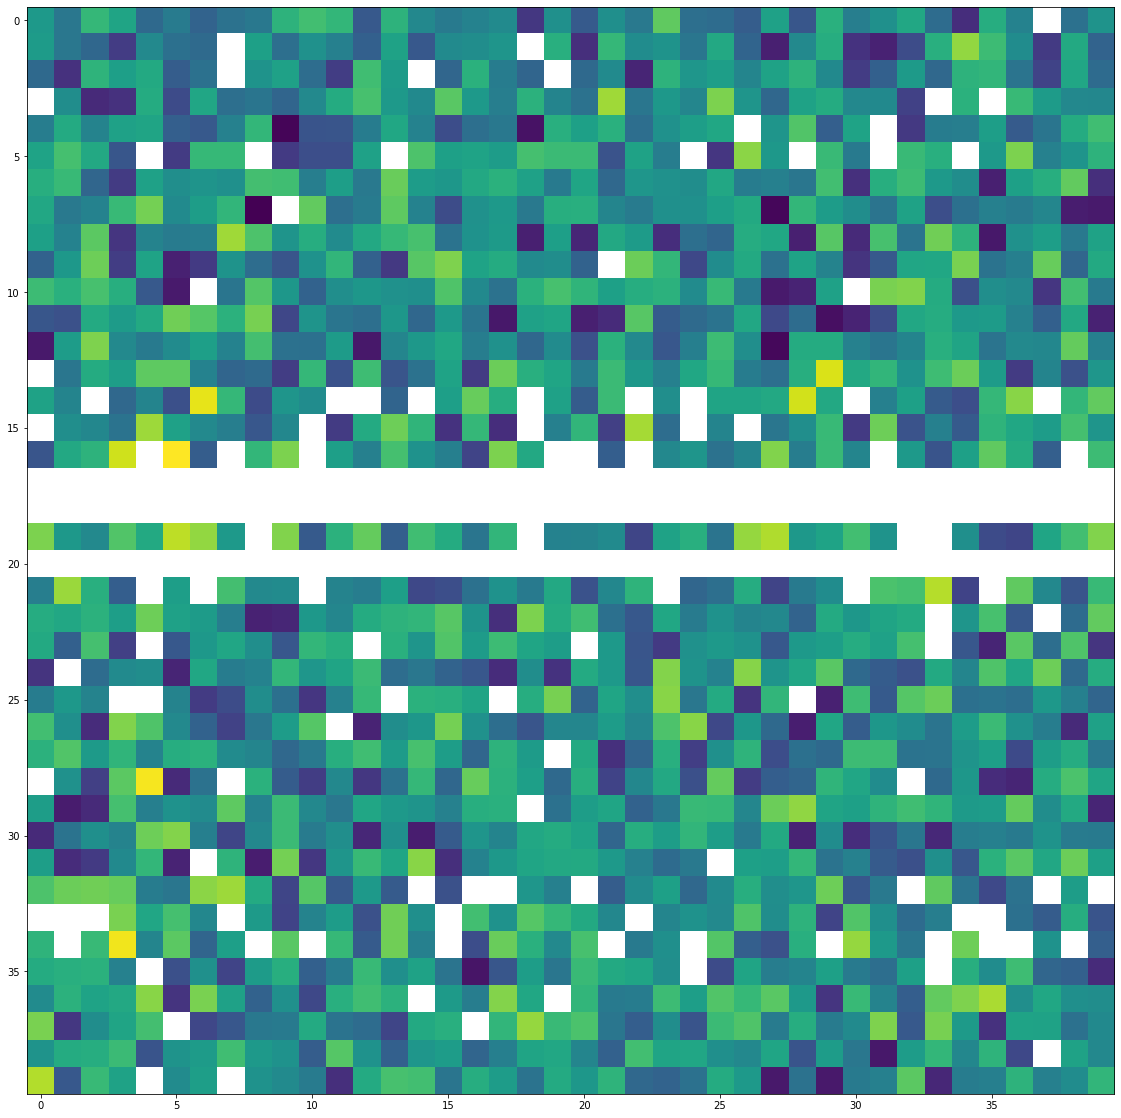

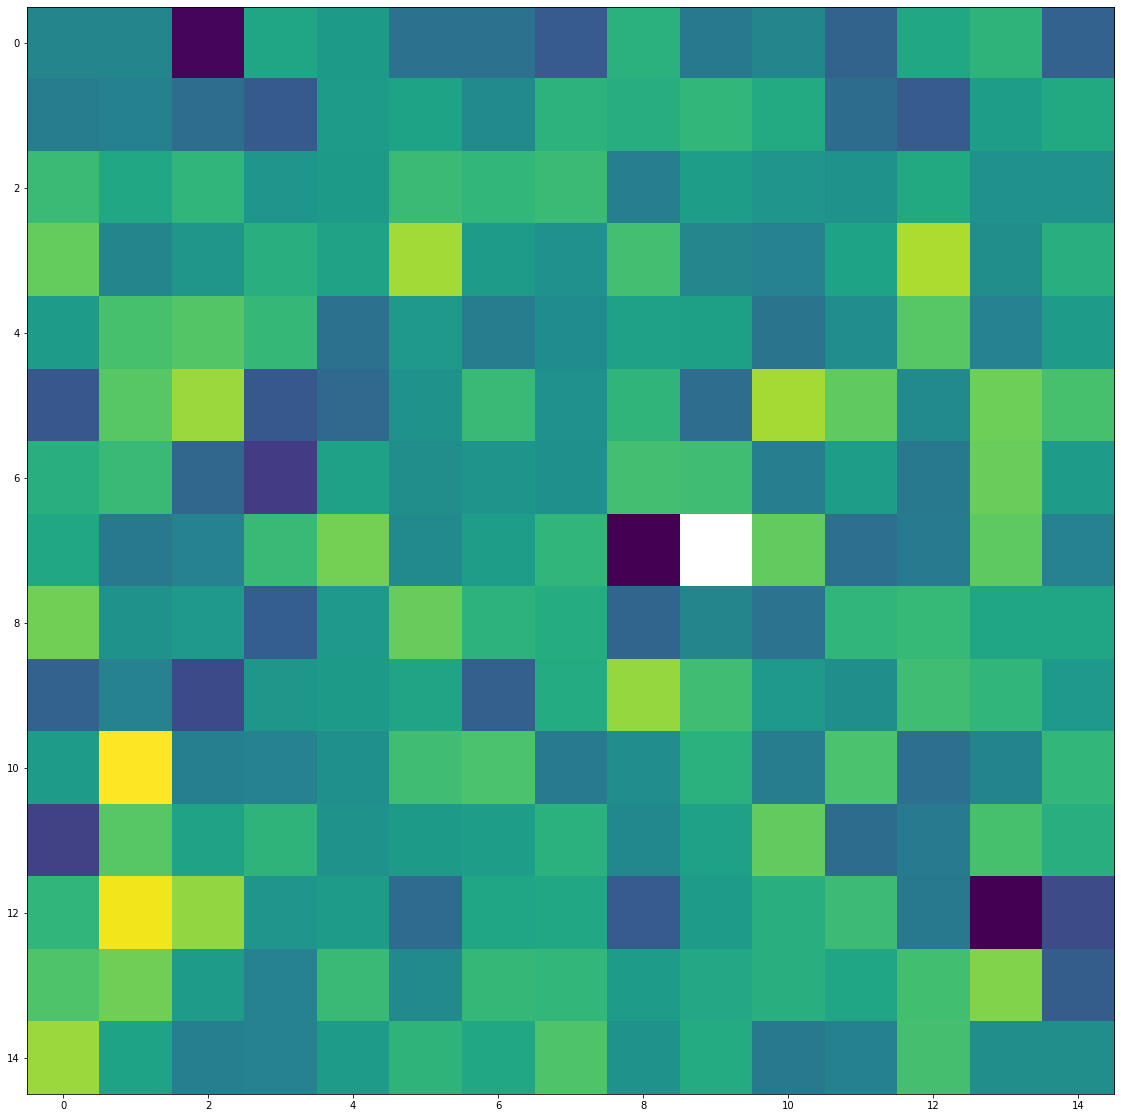

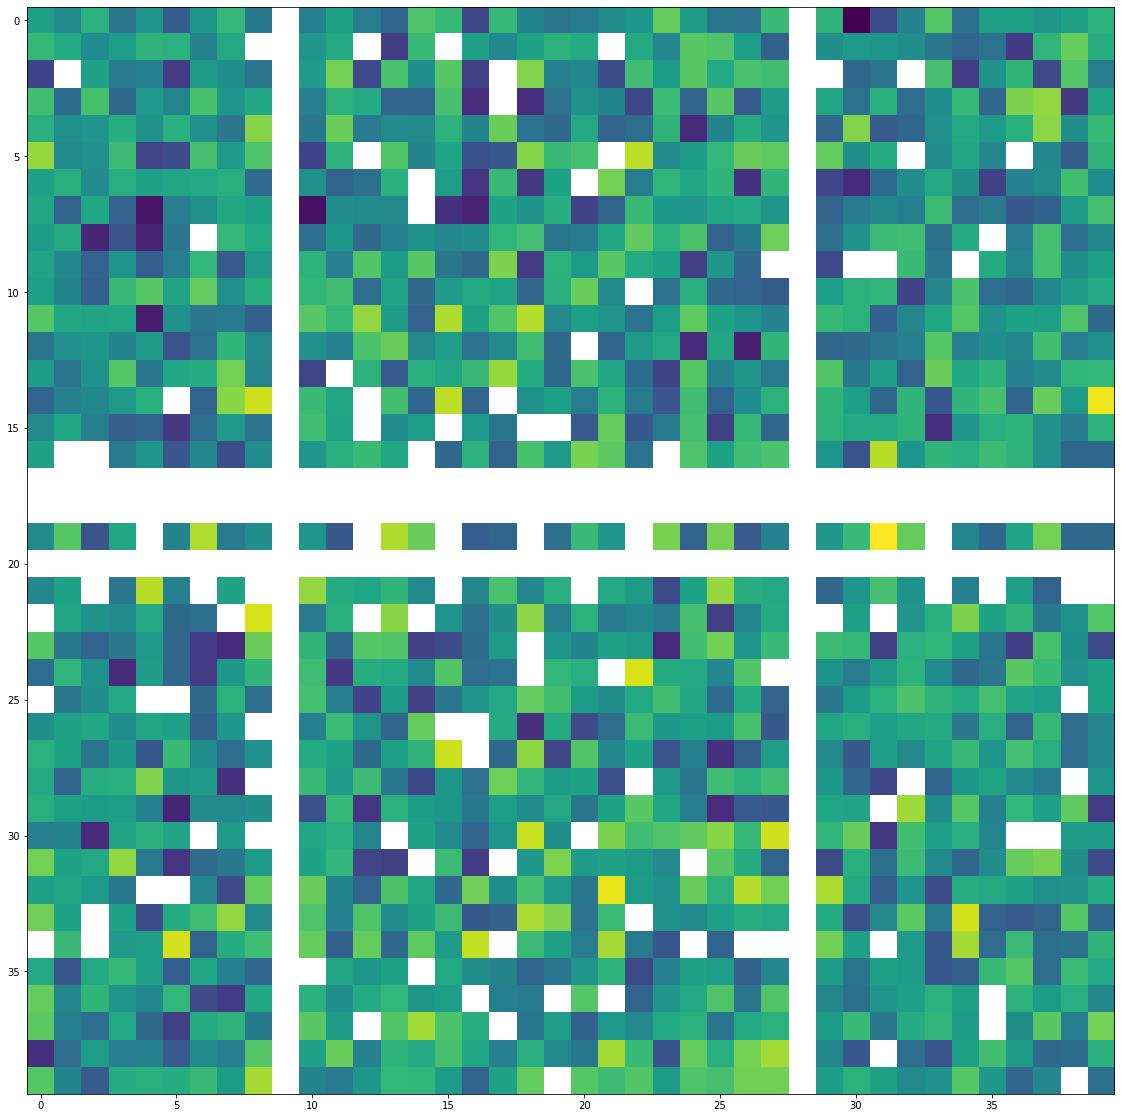

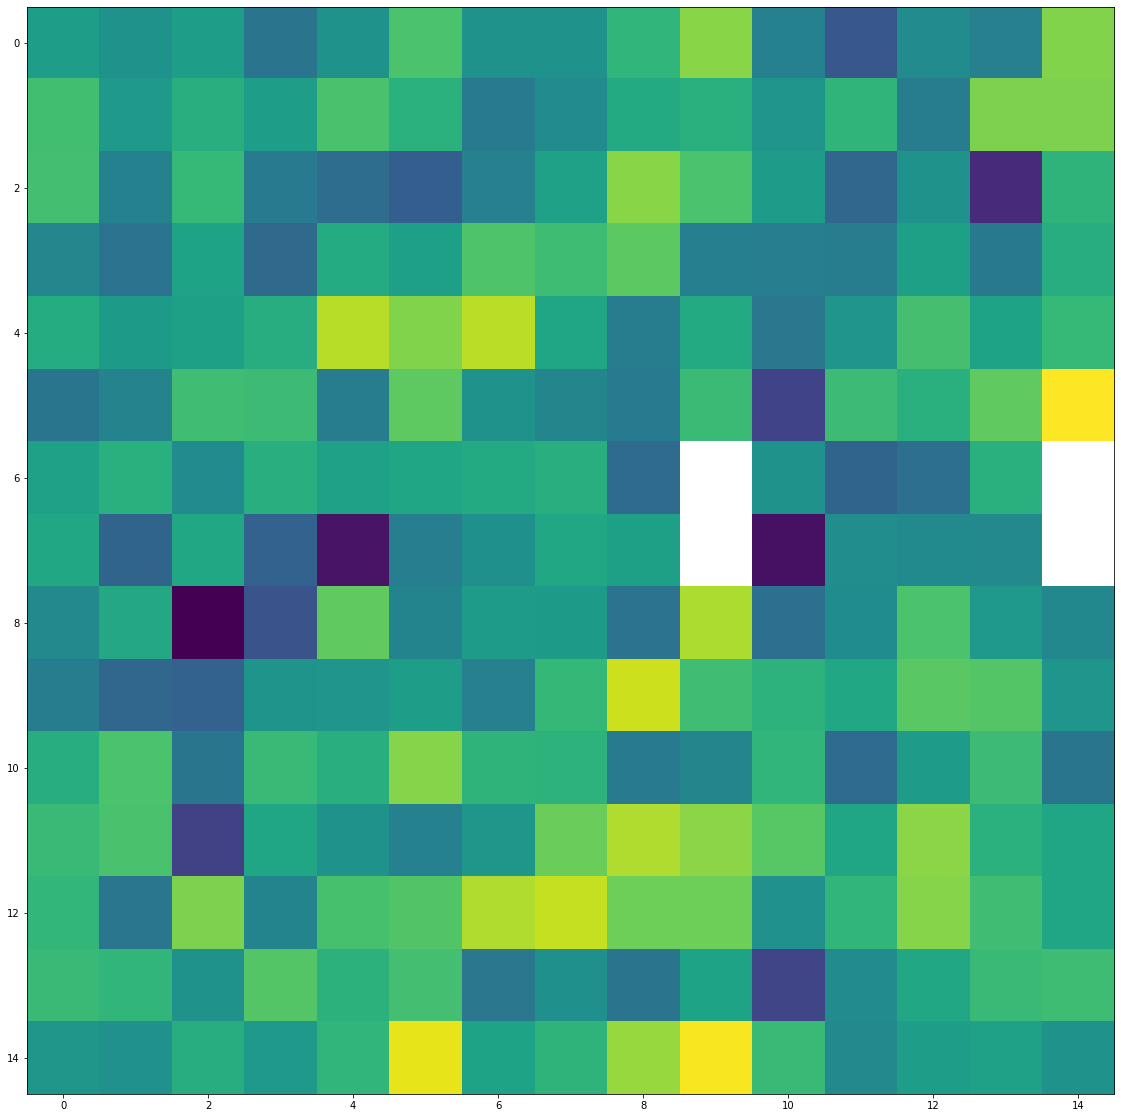

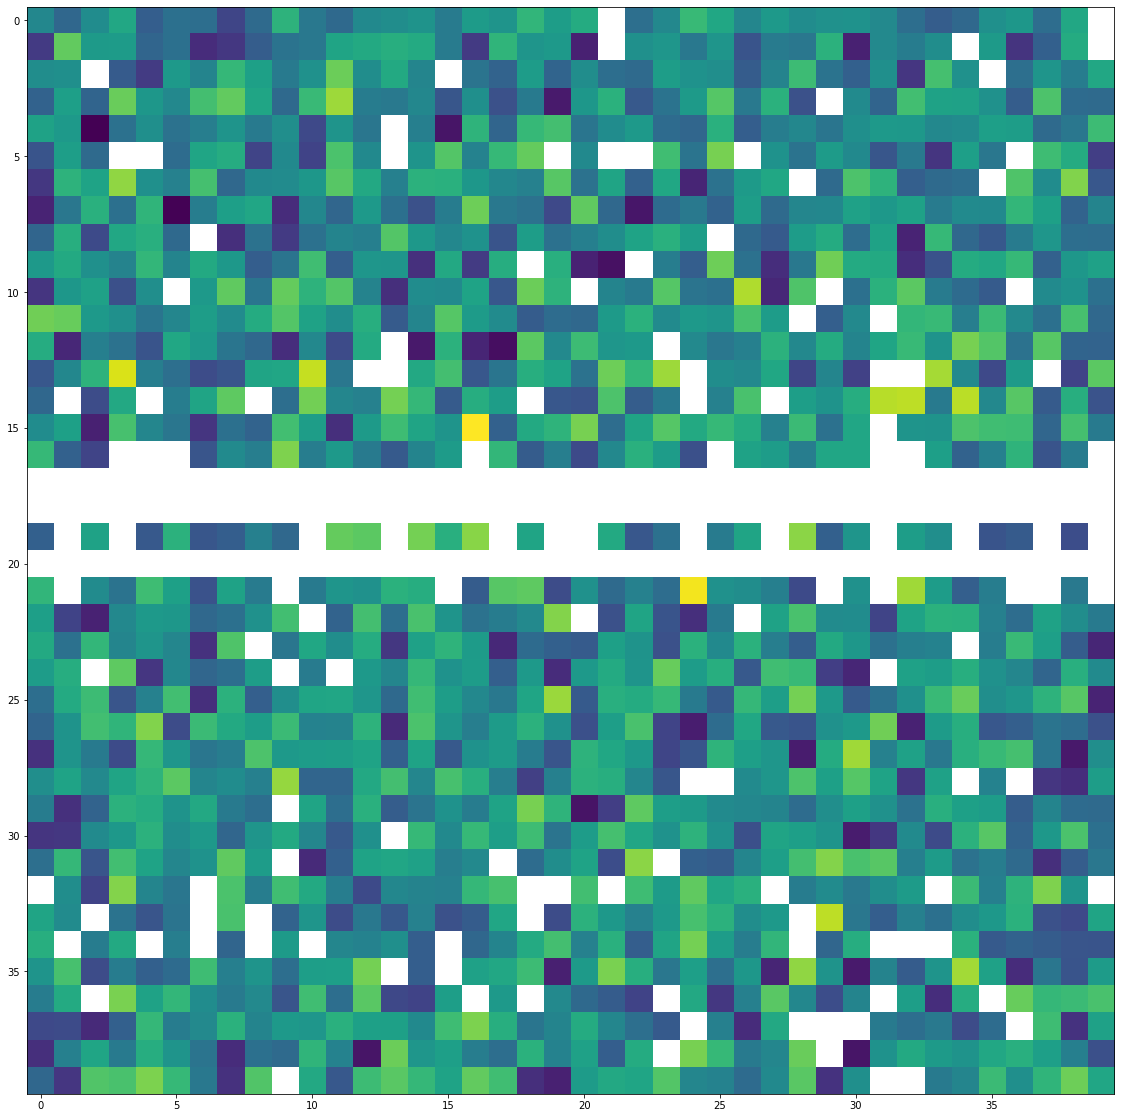

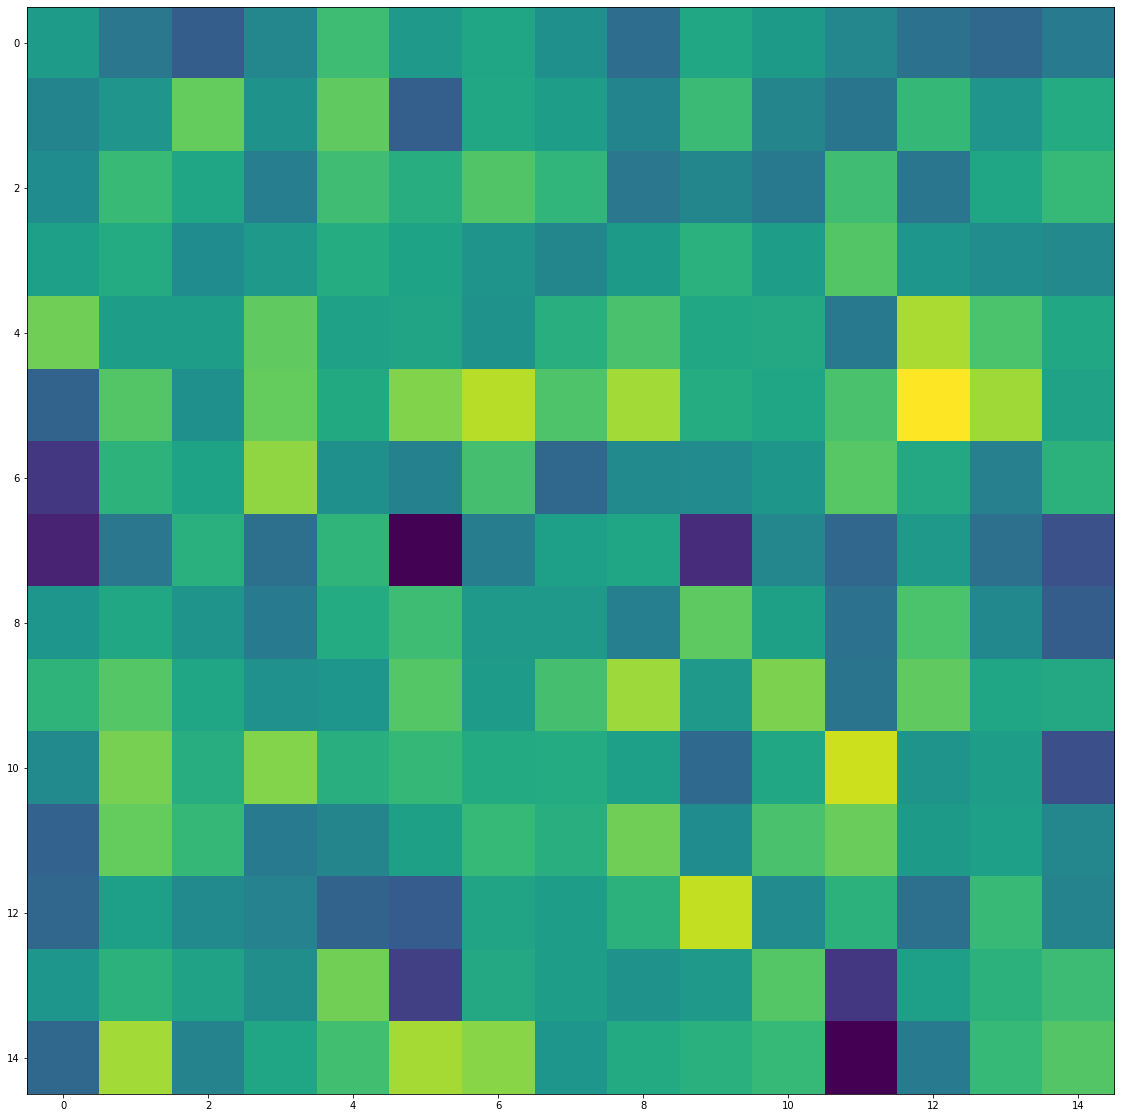

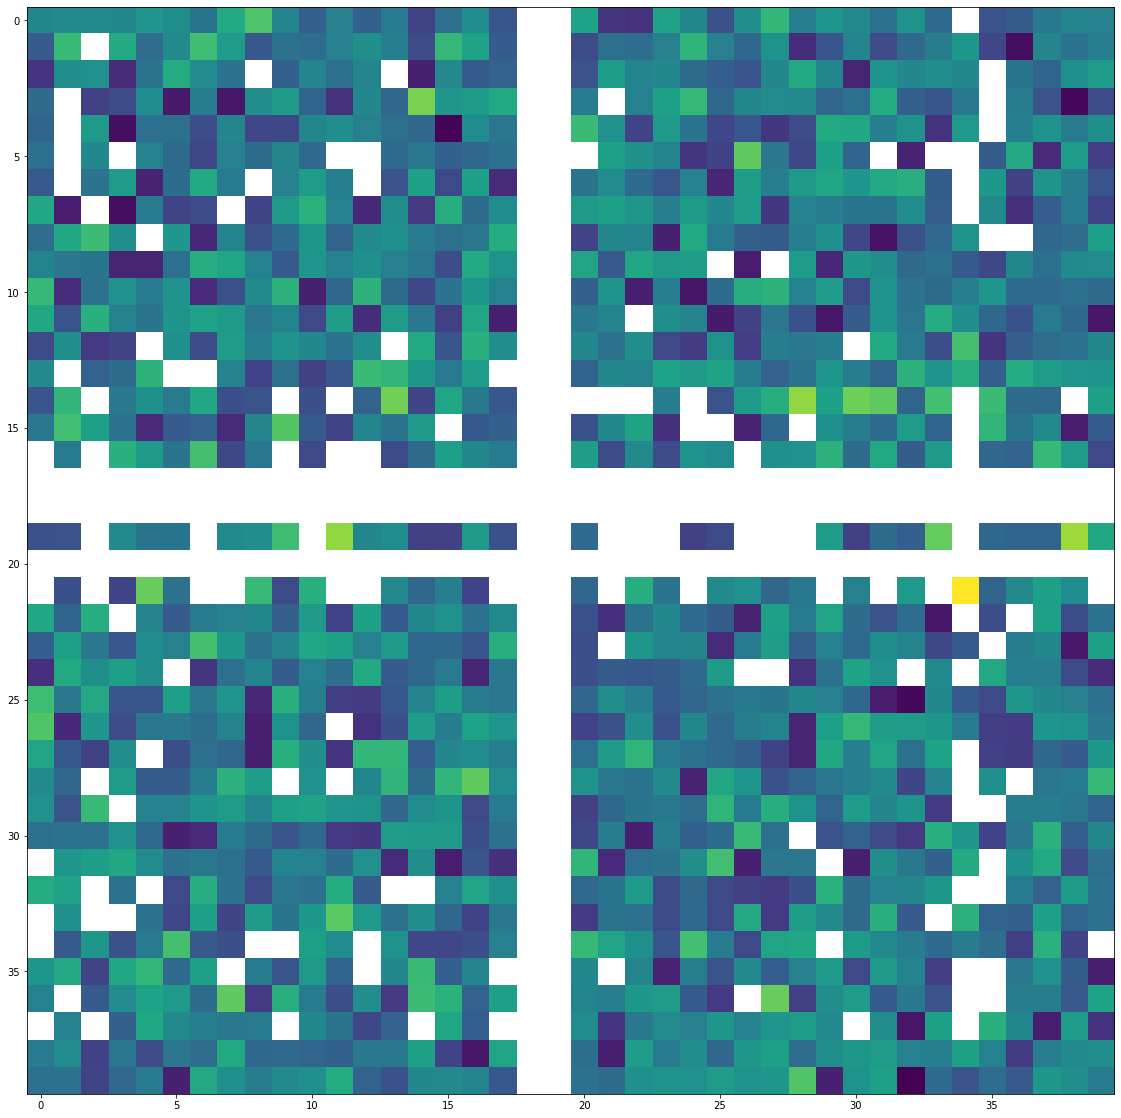

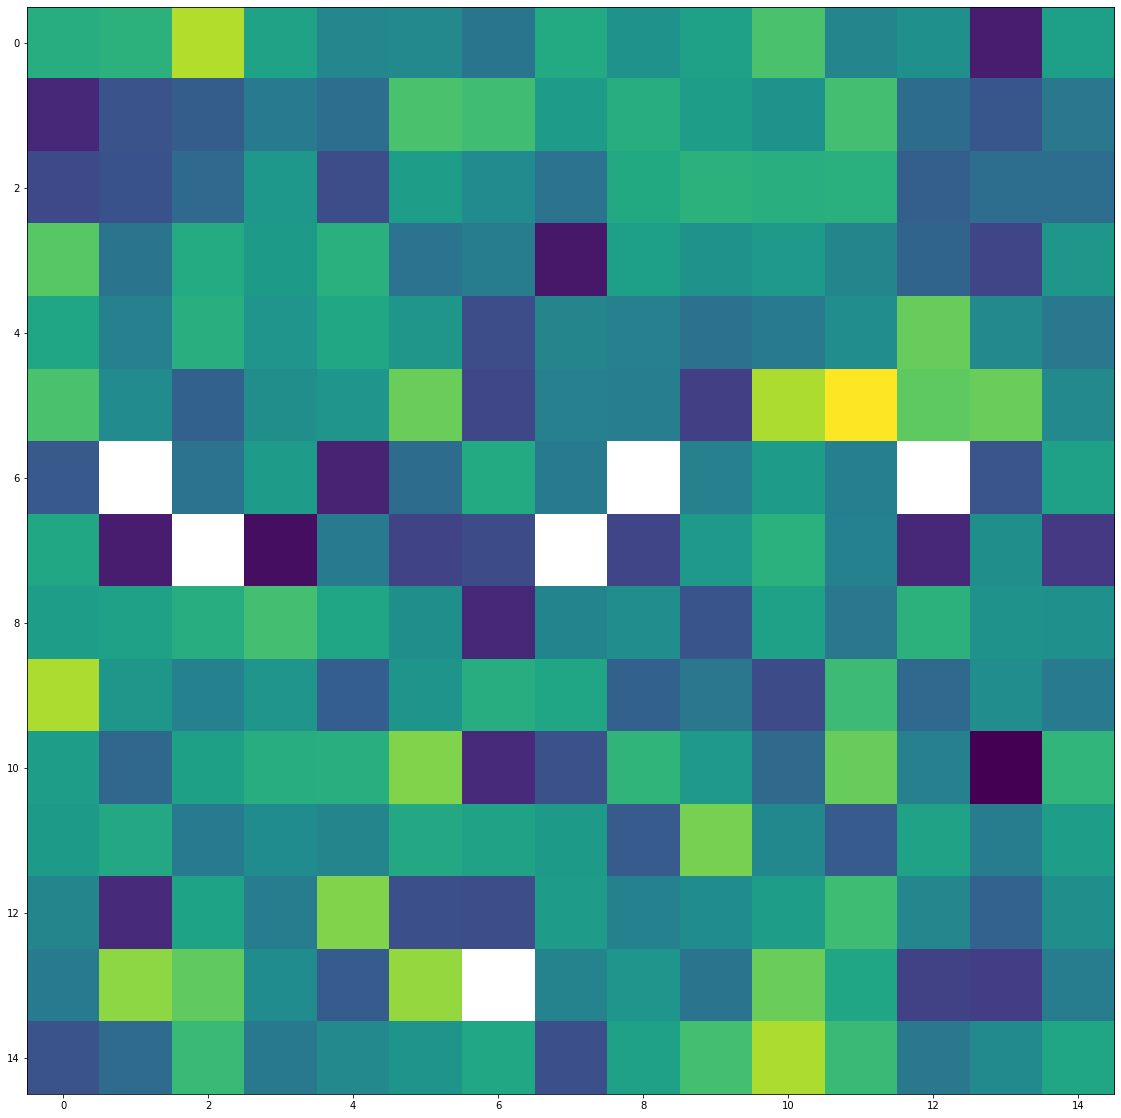

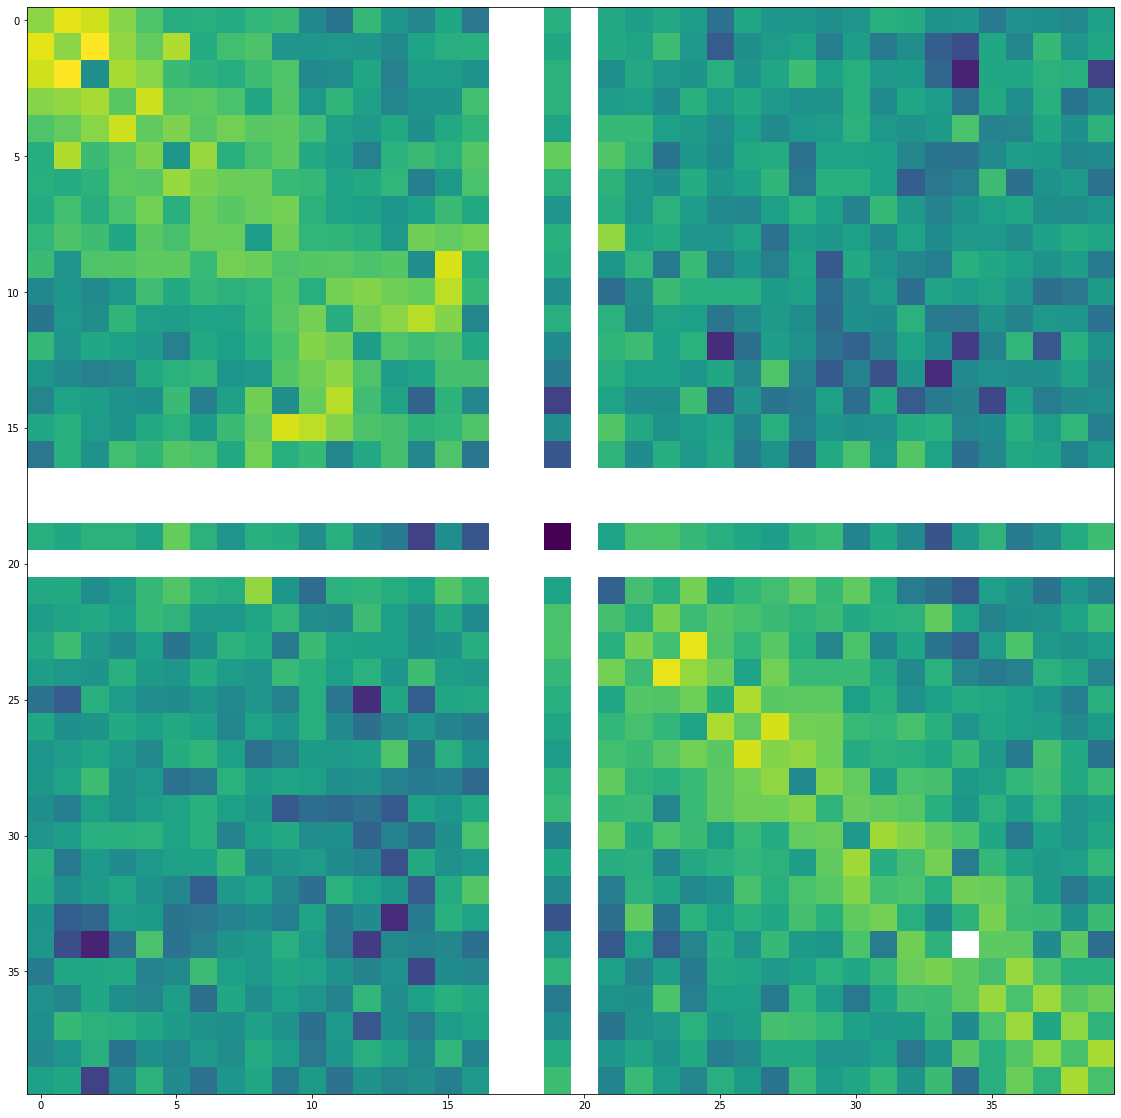

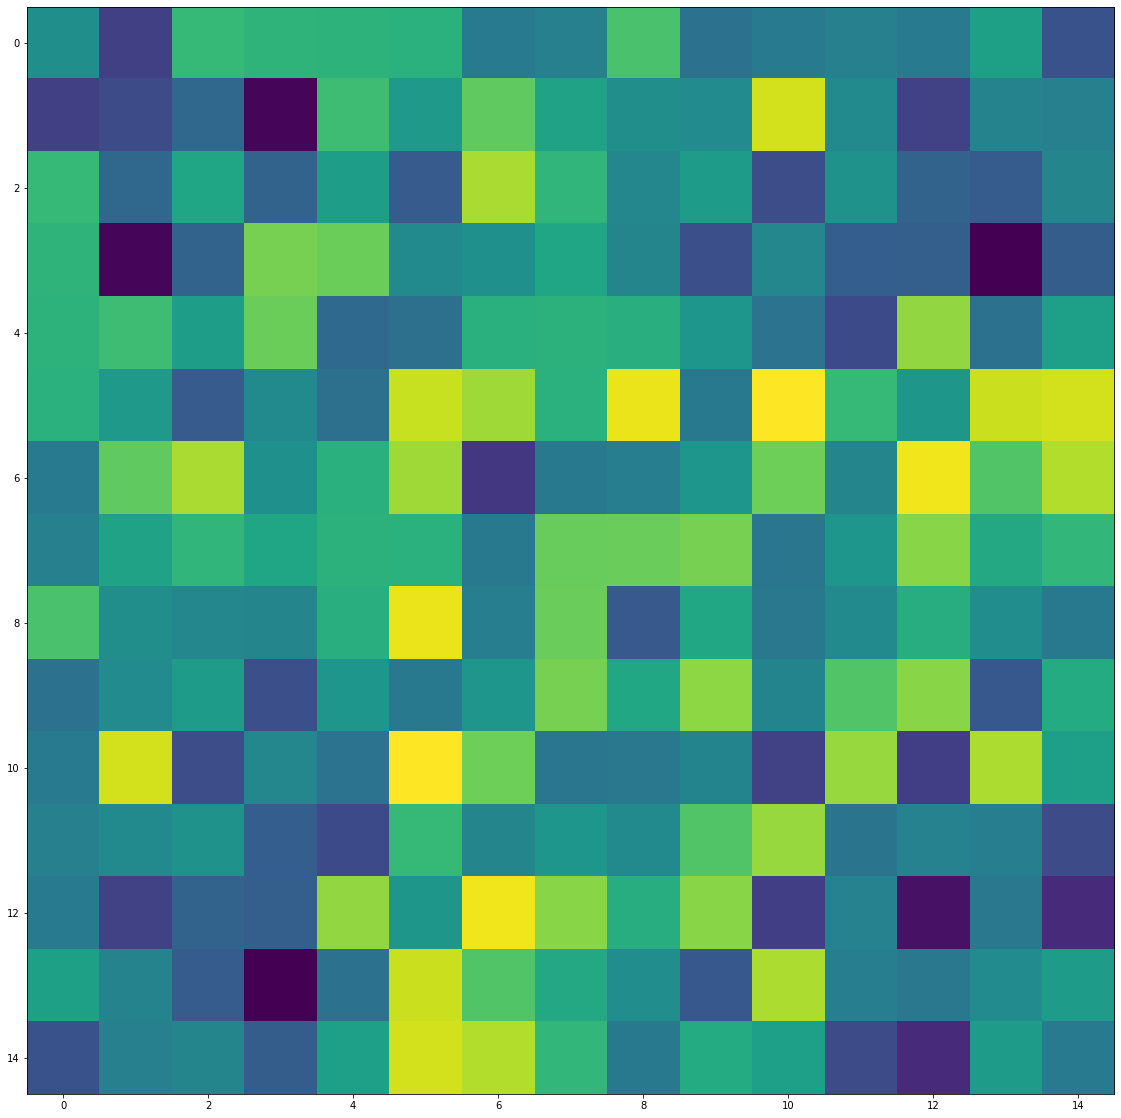

In [135]:
# hicue region parameters
for i in range(1):#range(len(hics)):
    print(hics[i])
    cool = cooler.Cooler(hics[i])
    pileup_diag = []
    pileup_contact = []
    #for k in range(len(dickeya_padded_regions)):
    for _, region1 in dickeya_padded_regions.iterrows():
        #region1 = dickeya_padded_regions.iloc[k]
        #print(cool.chromsizes[region1["Chromosome"]])
        #for l in range(k + 1, len(dickeya_padded_regions)):
        for _, region2 in dickeya_padded_regions.iterrows():
            #region2 = dickeya_padded_regions.iloc[l]
            
            print(region1["Id"], region2["Id"])
            submat = extract_window_region(cool, region1, region2, is_loc_circ1 = True, is_loc_circ2 = True)
            print(submat.shape)
            plt.figure(figsize=(20, 20))
            plt.imshow(np.log10(submat))
            plt.show()
            
            print("Masked:")
            submat = mask_diagonal_region(submat, region1, region2, binning = binning, diagonal_mask= 2000, chromsize = cool.chromsizes[region1["Chromosome"]])
            plt.figure(figsize=(20, 20))
            plt.imshow(np.log10(submat))
            plt.show()

            print("Resized:")
            resized_submat = resize_window(submat, expected_size = 15)
            plt.imshow(np.log10(resized_submat))
            plt.show()

            if region1["Id"] == region2["Id"]:
                pileup_diag.append(resized_submat)
            else:
                pileup_contact.append(resized_submat)

    if len(pileup_diag) > 0:
        print("Diagonal pileup:")
        plt.imshow(np.nanmedian(pileup_diag, axis=0))
        plt.show()

    if len(pileup_contact) > 0:
        print("Contact pileup:")
        plt.imshow(np.log10(np.nanmedian(pileup_contact, axis=0)))
        plt.show()

In [141]:
# plasmodium falciparum test
# hicue region parameters
test_folder = "../test_data/regions"
test_out_folder = "region_results"
hic = "MicroC-Bartfai-Control.mcool"
binning = 5000
cool = cooler.Cooler(f"{test_folder}/{hic}::resolutions/{binning}")
padding = 0.75
min_size = 2 # minimal size of region in bins
bed_file = "3D7_aHP1.sort.bed"
heterochromatin_regions = pd.read_csv(f"{test_folder}/{bed_file}", sep= '\t', header = None)
heterochromatin_regions.columns = ["Chromosome", "Start", "End"]
heterochromatin_regions["Id"] = [i for i in range(len(heterochromatin_regions))]
heterochromatin_regions["Name"] = [f"region_{i}" for i in range(len(heterochromatin_regions))]
heterochromatin_regions["Strand"] = [0 for i in range(len(heterochromatin_regions))]

heterochromatin_padded_regions = []
for i in range(len(heterochromatin_regions)):
    region = heterochromatin_regions.iloc[i]
    chromsize = cool.chromsizes[region["Chromosome"]]
    if abs(region["Start"] - region["End"]) >= (binning * min_size):
        heterochromatin_padded_regions.append(apply_padding(region, chromsize, padding_size = padding))

heterochromatin_padded_regions = pd.DataFrame(heterochromatin_padded_regions)
heterochromatin_padded_regions

,Chromosome,Start,End,Id,Name,Strand,Padded_start,Padded_end,Padded_size,Padding,Size
0,Pf3D7_01_v3,0,37100,0,region_0,0,613026,64925,92750,27825,37100
4,Pf3D7_01_v3,53200,67100,4,region_4,0,42775,77525,34750,10425,13900
12,Pf3D7_01_v3,520500,536100,12,region_12,0,508800,547800,39000,11700,15600
15,Pf3D7_01_v3,549300,578000,15,region_15,0,527775,599525,71750,21525,28700
18,Pf3D7_01_v3,607300,621600,18,region_18,0,596575,632325,35750,10725,14300
...,...,...,...,...,...,...,...,...,...,...,...
193,Pf3D7_13_v3,2888500,2913700,193,region_193,0,2869600,7364,63000,18900,25200
197,Pf3D7_14_v3,13800,32900,197,region_197,0,3291411,47225,47750,14325,19100
200,Pf3D7_14_v3,3087700,3114800,200,region_200,0,3067375,3135125,67750,20325,27100
203,Pf3D7_14_v3,3165500,3186500,203,region_203,0,3149750,3202250,52500,15750,21000


name
Pf3D7_01_v3      640851
Pf3D7_02_v3      947102
Pf3D7_03_v3     1067971
Pf3D7_04_v3     1200490
Pf3D7_05_v3     1343557
Pf3D7_06_v3     1418242
Pf3D7_07_v3     1445207
Pf3D7_08_v3     1472805
Pf3D7_09_v3     1541735
Pf3D7_10_v3     1687656
Pf3D7_11_v3     2038340
Pf3D7_12_v3     2271494
Pf3D7_13_v3     2925236
Pf3D7_14_v3     3291936
Pf3D7_API_v3      34250
Pf3D7_MIT_v3       5967
Name: length, dtype: int32
            chrom  start    end    weight
3422  Pf3D7_13_v3      0   5000  0.020666
3423  Pf3D7_13_v3   5000  10000       NaN
3424  Pf3D7_13_v3  10000  15000       NaN
3425  Pf3D7_13_v3  15000  20000       NaN
3426  Pf3D7_13_v3  20000  25000  0.010532
3427  Pf3D7_13_v3  25000  30000  0.005843
3428  Pf3D7_13_v3  30000  35000  0.008314
3429  Pf3D7_13_v3  35000  40000  0.003008
3430  Pf3D7_13_v3  40000  45000  0.003313
3431  Pf3D7_13_v3  45000  50000  0.016534
3432  Pf3D7_13_v3  50000  55000  0.005199
3433  Pf3D7_13_v3  55000  60000  0.010510


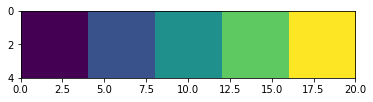

In [142]:
matrix = [
    [1, 2, 3, 4, 5],
    [1, 2, 3, 4, 5],
    [1, 2, 3, 4, 5],
    [1, 2, 3, 4, 5],
    [1, 2, 3, 4, 5],
         ]
plt.imshow(matrix, extent = [0, 20, 4, 0])
print(cool.chromsizes)
print(cool.bins().fetch('Pf3D7_13_v3:0-56950'))

/tmp/ipykernel_4150704/80844004.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_4150704/80844004.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_4150704/80844004.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_4150704/80844004.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_4150704/80844004.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_4150704/80844004.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_4150704/80844004.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_4150704/80844004.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt

/tmp/ipykernel_4150704/80844004.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_4150704/80844004.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_4150704/80844004.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_4150704/80844004.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_4150704/80844004.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_4150704/80844004.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_4150704/80844004.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_4150704/80844004.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt

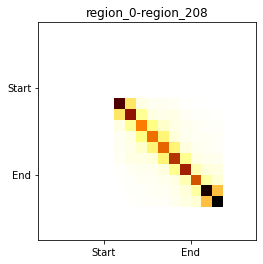

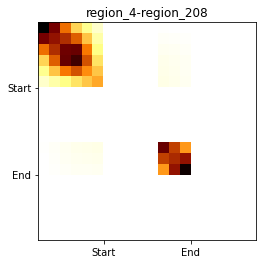

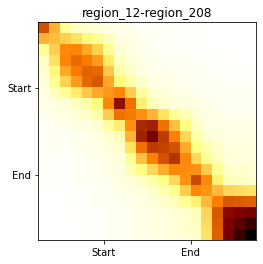

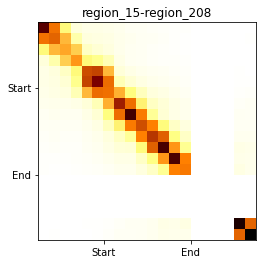

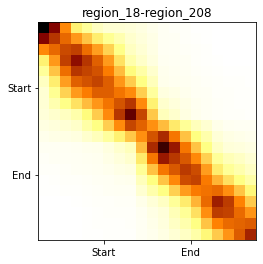

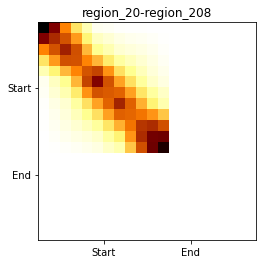

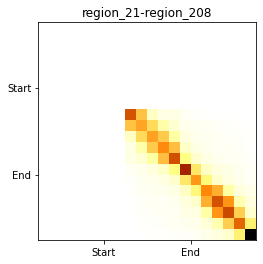

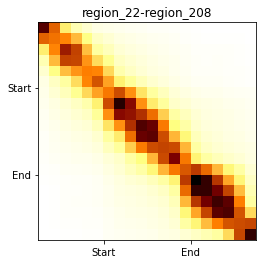

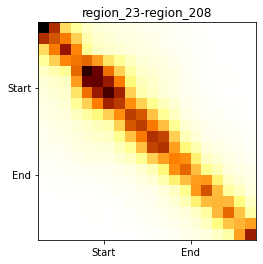

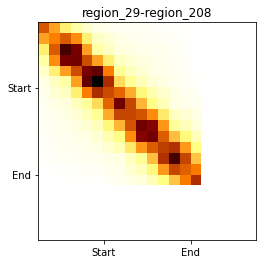

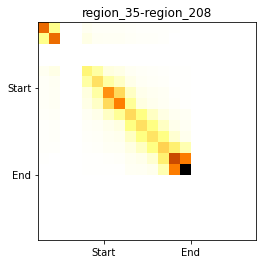

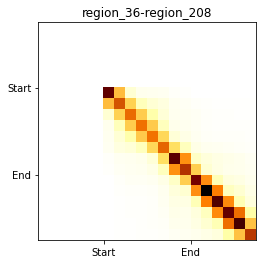

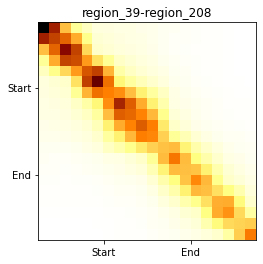

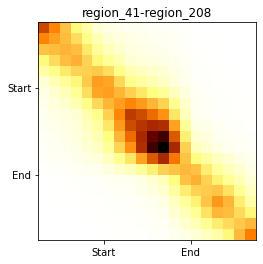

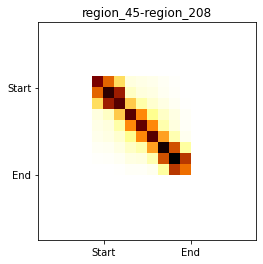

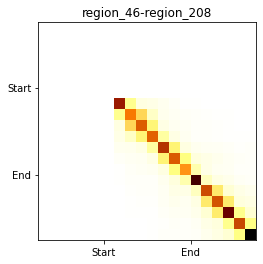

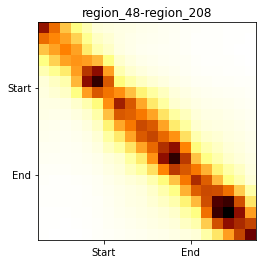

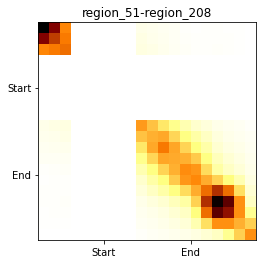

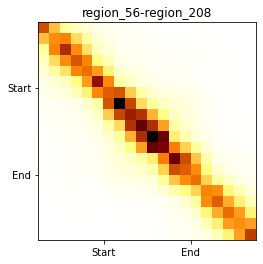

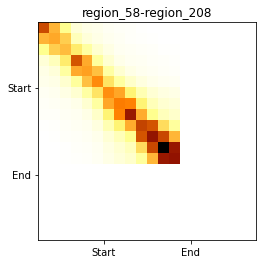

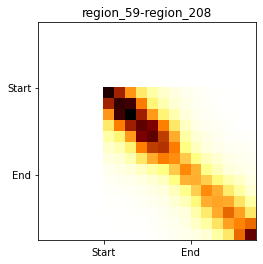

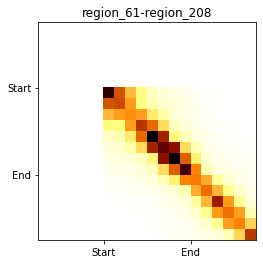

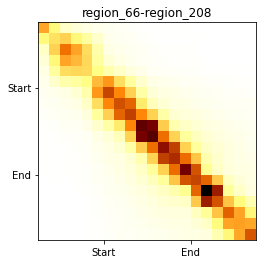

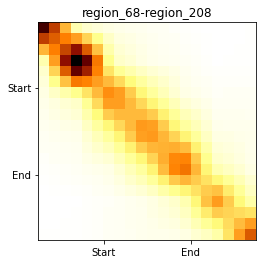

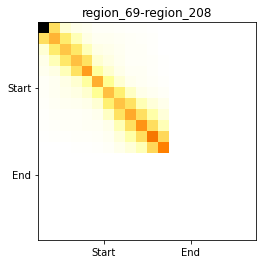

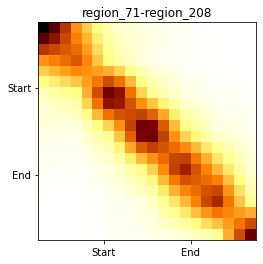

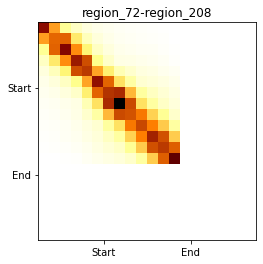

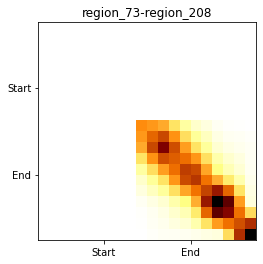

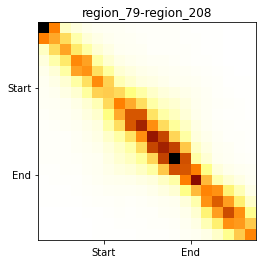

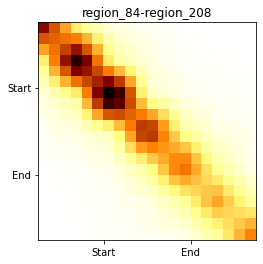

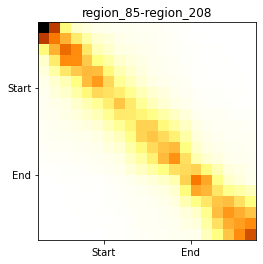

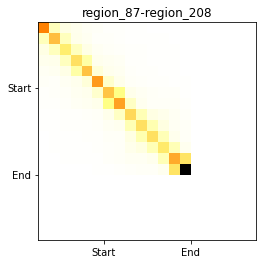

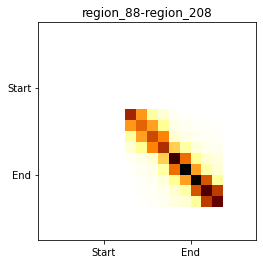

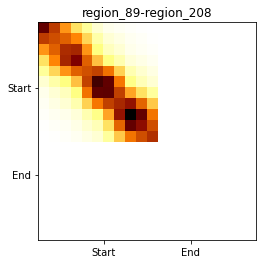

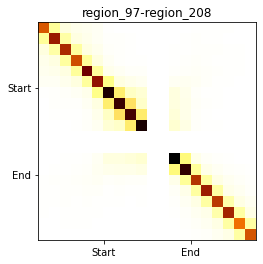

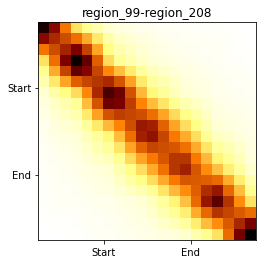

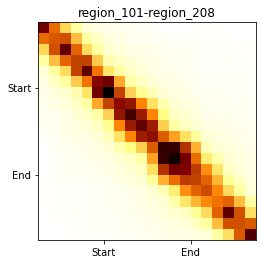

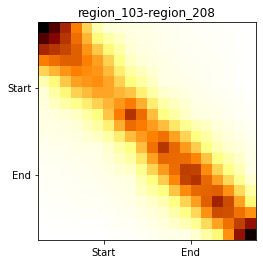

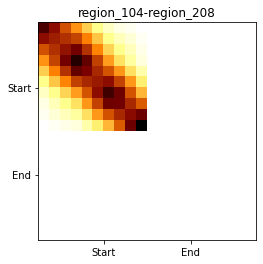

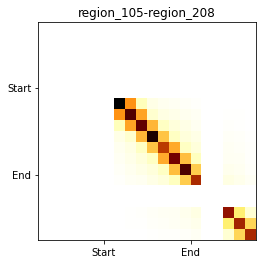

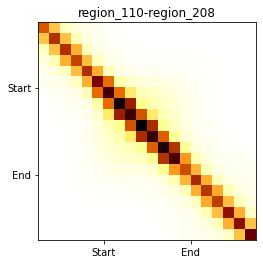

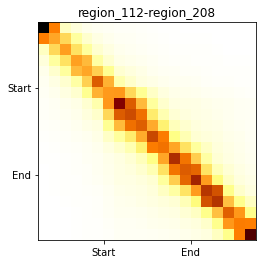

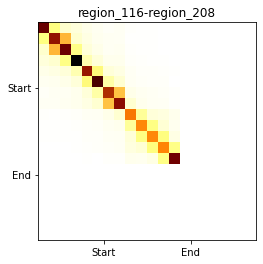

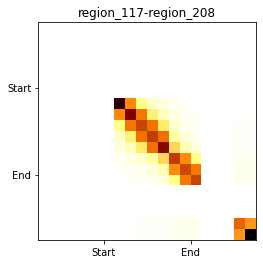

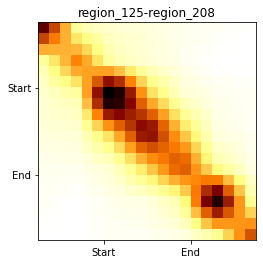

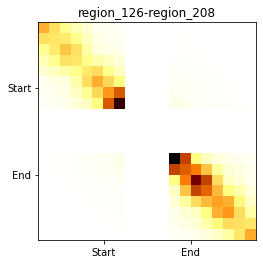

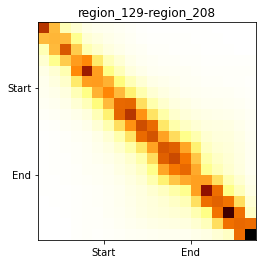

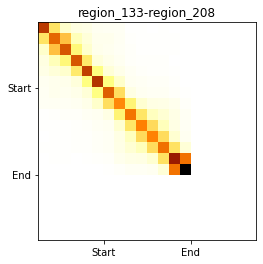

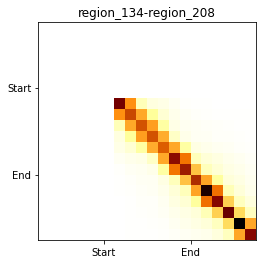

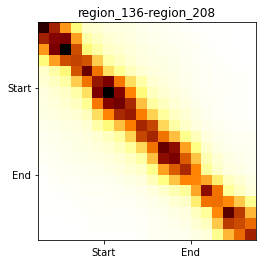

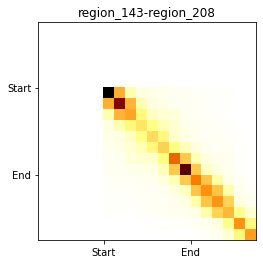

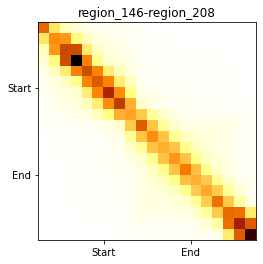

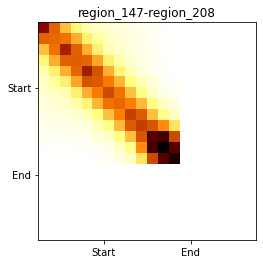

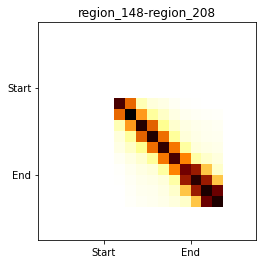

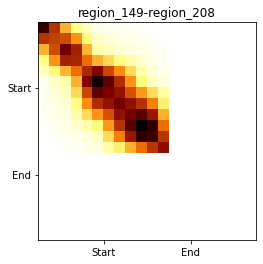

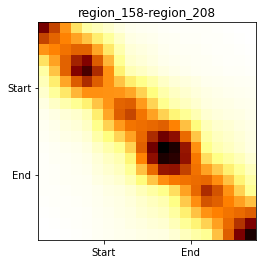

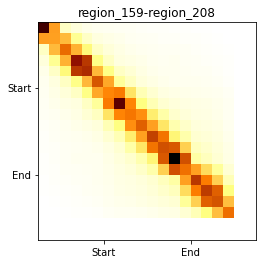

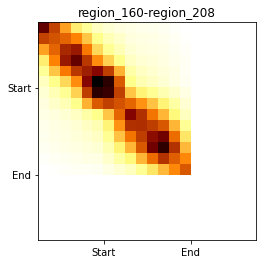

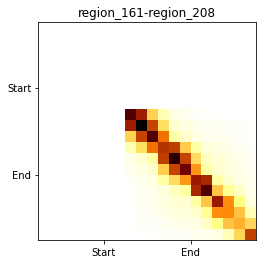

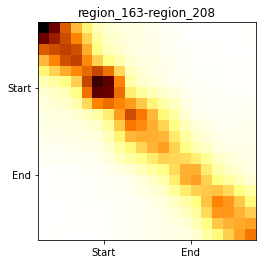

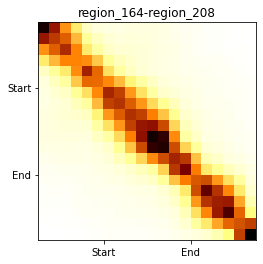

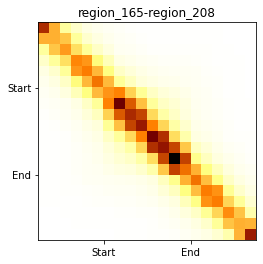

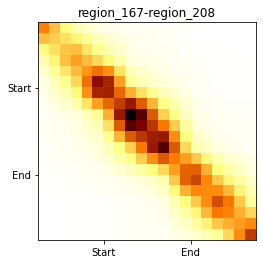

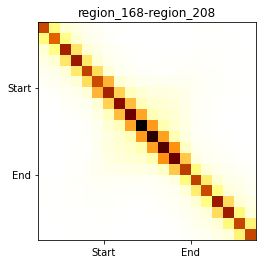

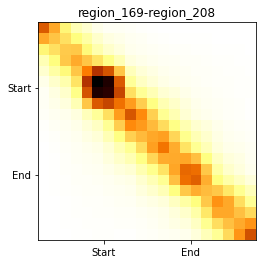

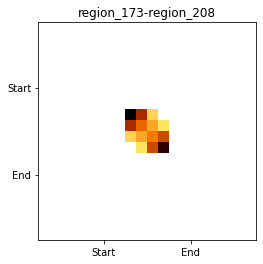

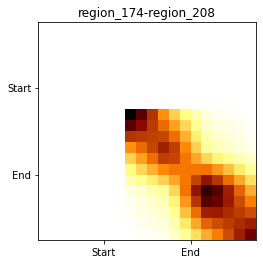

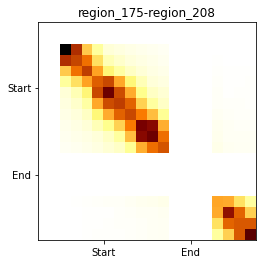

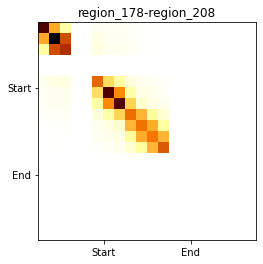

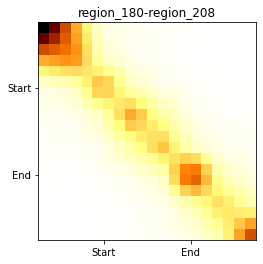

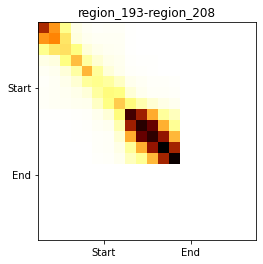

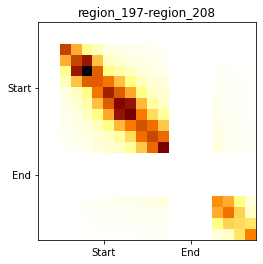

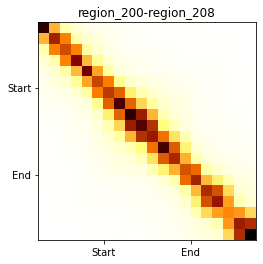

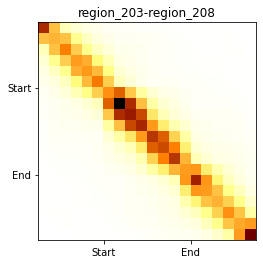

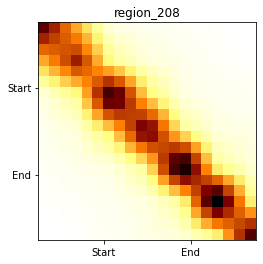

In [157]:
# separating per chromosome for easier analysis
import importlib
def plot_map_region(ax, matrix, region1, region2, padding, is_contact = False,
             title="", display_sense="forward",
             display_strand=False, flipped=False,
             cmap=None, color="afmhot_r",
             show_title=True, log=True,strand_level=1.2, adjustment=0.9):

    name = (f"{region1['Name'].replace('/', '_')}"
            if not is_contact
            else f"{region1['Name'].replace('/', '_')}-{region2['Name'].replace('/', '_')}")
    title = name if len(title) == 0 else title
    if show_title:
        ax.set_title(title)

    # Log-transform (suppressing divide-by-zero warnings on zero contacts).
    with np.errstate(divide='ignore', invalid='ignore'):
        display_matrix = np.log10(matrix) if log else matrix

    vmin = cmap[0] if cmap is not None else None
    vmax = cmap[1] if cmap is not None else None

    forward_labels = ["Start", "End"]
    reverse_labels = ["End", "Start"]
    padding_size = padding * matrix.shape[0] /(2 * padding + 1)
    
    match display_sense:
        case "forward":
            y_labels = reverse_labels if region1["Strand"] != -1 or not flipped else forward_labels
            x_labels = forward_labels if region2["Strand"] != -1 or not flipped else reverse_labels
            mat = ax.imshow(display_matrix, cmap=color, vmin=vmin, vmax=vmax)
            
        case "reverse":
            y_labels = forward_labels if region1["Strand"] != -1 or not flipped else reverse_labels
            x_labels = reverse_labels if region2["Strand"] != -1 or not flipped else forward_labels
            mat = ax.imshow(np.flip(display_matrix), cmap=color, vmin=vmin, vmax=vmax)
            
    ax_start, ax_end = ax.get_xlim()
    labels_indexes = [ax_start + padding_size, ax_end - padding_size]
    
    ax.set_xticks(labels_indexes, x_labels)
    ax.set_yticks(labels_indexes, y_labels)

    return mat

for chrom, chromsize in cool.chromsizes.items():
    pileup_diag = []
    pileup_contact = []
    heterochrom_chrom = heterochromatin_padded_regions[heterochromatin_padded_regions["Chromosome"] == chrom]
    for i, region1 in heterochrom_chrom.iterrows():
        #for j, region2 in heterochrom_chrom.iterrows():

            #print(region1["Id"], region2["Id"])
            submat = extract_window_region(cool, region1, region)
            #print(submat.shape)
            #plt.figure(figsize=(20, 20))
            #plt.imshow(np.log10(submat))
            #plt.show()

            #print("Masked:")
            #submat = mask_diagonal_region(submat, region1, region2, binning = binning, diagonal_mask= binning, chromsize = chromsize)
            #plt.figure(figsize=(20, 20))
            #plt.imshow(np.log10(submat))
            #plt.show()


            #print("Resized:")
            resized_submat = resize_window(submat, expected_size = 20)
            plt.figure()
            plot_map_region(plt.gca(), resized_submat, region1, region2, padding, is_contact = (i != j))
            plt.imshow(np.log10(resized_submat))
            plt.show()

            if region1["Id"] == region2["Id"]:
                pileup_diag.append(resized_submat)
            else:
                pileup_contact.append(resized_submat)

    #if len(pileup_diag) > 0:
    #    print(f"Diagonal pileup {chrom}:")
    #    plt.figure()
    #    plt.imshow(np.nanmedian(pileup_diag, axis=0))
    #    plt.title(len(pileup_diag))
    #    plt.savefig(f"{test_out_folder}/{chrom}_diag_{binning}_pileup.png")
    #    plt.savefig(f"{test_out_folder}/{chrom}_diag_{binning}_pileup.pdf")
    #    plt.show()

    #if len(pileup_contact) > 0:
    #    plt.figure()
    #    print(f"Contact pileup {chrom}:")
    #    plt.imshow(np.log10(np.nanmedian(pileup_contact, axis=0)))
    #    plt.title(len(pileup_contact))
    #    plt.savefig(f"{test_out_folder}/{chrom}_contact_{binning}_pileup.png")
    #    plt.savefig(f"{test_out_folder}/{chrom}_contact_{binning}_pileup.pdf")
    #    plt.show()

In [11]:
# cis/trans contacts
pileup_cis = []
pileup_trans = []
pileup_diag = []
for _, region1 in heterochromatin_padded_regions.iterrows():
    for _, region2 in heterochromatin_padded_regions.iterrows():

        #print(region1["Id"], region2["Id"])
        submat = extract_window_region(cool, region1, region2)
        #print(submat.shape)
        #plt.figure(figsize=(20, 20))
        #plt.imshow(np.log10(submat))
        #plt.show()

        #print("Masked:")
        submat = mask_diagonal_region(submat, region1, region2, binning = binning, diagonal_mask= binning, chromsize = chromsize)
        #plt.figure(figsize=(20, 20))
        #plt.imshow(np.log10(submat))
        #plt.show()

        #print("Resized:")
        resized_submat = resize_window(submat, expected_size = 20)
        #plt.imshow(np.log10(resized_submat))
        #plt.show()

        if region1["Id"] == region2["Id"]:
            pileup_diag.append(resized_submat)
        else:
            if region1["Chromosome"] == region2["Chromosome"]:
                pileup_cis.append(resized_submat)
            else:
                pileup_trans.append(resized_submat)

if len(pileup_diag) > 0:
    print(f"Diagonal pileup {chrom}:")
    plt.imshow(np.nanmedian(pileup_diag, axis=0))
    plt.title(len(pileup_diag))
    plt.savefig(f"{test_out_folder}/all_diag_{binning}_pileup.png")
    plt.savefig(f"{test_out_folder}/all_diag_{binning}_pileup.pdf")
    plt.show()

if len(pileup_cis) > 0:
    print(f"Contact cis pileup {chrom}:")
    plt.imshow(np.log10(np.nanmedian(pileup_cis, axis=0)))
    plt.title(len(pileup_cis))
    plt.savefig(f"{test_out_folder}/cis_contact_{binning}_pileup.png")
    plt.savefig(f"{test_out_folder}/cis_contact_{binning}_pileup.pdf")
    plt.show()
    
if len(pileup_trans) > 0:
    print(f"Contact trans pileup {chrom}:")
    plt.imshow(np.log10(np.nanmedian(pileup_trans, axis=0)))
    plt.title(len(pileup_trans))
    plt.savefig(f"{test_out_folder}/trans_contact_{binning}_pileup.png")
    plt.savefig(f"{test_out_folder}/trans_contact_{binning}_pileup.pdf")
    plt.show()

UnboundLocalError: local variable 'len1' referenced before assignment